# **Project 18: Evolutionary Reward Shaping for Reinforcement Learning Agents**
**Baseline, Manual, and GA-Evolved Reward Shaping Across Three Environments**

This notebook implements and evaluates baseline reinforcement learning (RL) agents across three environments:

| Environment | Algorithm |
|---|---|
| CartPole-v1 (Gymnasium) | DQN via Stable Baselines3 |
| LunarLander-v3 (Gymnasium) | DQN via Stable Baselines3 |
| MiniGrid-Empty-5x5-v0 | DQN via Stable Baselines3 + Tabular Q-Learning |

All episode rewards and lengths are logged to CSV files and learning curves are plotted at the end of each section.

---

## Running this notebook

**Locally (recommended):** Dependencies are managed via `requirements.txt` in the project root. If you have not yet set up the environment, follow the instructions in `README.md`. No changes to this notebook are needed.

**Google Colab:** Uncomment and run the installation cell in Section 1 before running anything else. After installation, restart the Colab runtime (Runtime > Restart runtime), then run all cells from Section 2 onwards. No other changes are needed.

---

## **1. Installation (Colab Only)**

**Local Users:** Skip this cell entirely; dependencies are already installed in your virtual environment.

**Colab Users:** Uncomment the line below, run this cell, then restart the runtime before continuing.

In [2]:
# COLAB ONLY: uncomment the line below if running on Google Colab
# After running, go to Runtime > Restart runtime, then continue from Section 2

# %pip install stable-baselines3[extra] gymnasium[box2d] minigrid --quiet

--- 
## **2. Imports and Configuration**

In [3]:
import os
import types
import pickle
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from minigrid.wrappers import FlatObsWrapper
from matplotlib.ticker import FuncFormatter
from scipy import stats

print('All Imports Successful.')

All Imports Successful.


### **2.1. Path Configuration**

This cell resolves the correct paths for saving logs and results regardless of whether the notebook is being run locally or on Colab.

- **Locally:** The notebook lives in `notebooks/`, so the project root is one level up. Logs and results are saved to `logs/` and `results/` at the project root.
- **Colab:** There is no project root structure, so logs and results are saved to `./logs` and `./results` relative to the notebook.

In [4]:
def _is_colab() -> bool:
  """Returns True if the notebook is running on Google Colab."""
  try:
    import google.colab
    return True
  except ImportError:
    return False


if _is_colab():
  PROJECT_ROOT = pathlib.Path('.')
  print('Environment: Google Colab')
else:
  _cwd = pathlib.Path().resolve()
  PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
  print(f'Environment: Local | Project Root: {PROJECT_ROOT}')

MODELS_DIRECTORY = str(PROJECT_ROOT / 'models')
LOG_DIRECTORY = str(PROJECT_ROOT / 'logs')
RESULTS_DIRECTORY = str(PROJECT_ROOT / 'results')

os.makedirs(MODELS_DIRECTORY, exist_ok=True)
os.makedirs(LOG_DIRECTORY, exist_ok=True)
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)

print(f'Models Directory: {MODELS_DIRECTORY}')
print(f'Log Directory: {LOG_DIRECTORY}')
print(f'Results Directory: {RESULTS_DIRECTORY}')

Environment: Local | Project Root: D:\Projects\project18-rl-reward-shaping
Models Directory: D:\Projects\project18-rl-reward-shaping\models
Log Directory: D:\Projects\project18-rl-reward-shaping\logs
Results Directory: D:\Projects\project18-rl-reward-shaping\results


### **2.2. Global Settings**

In [81]:
# Plotting style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Five seeds for statistically robust results (through multi-seed evaluation) per Henderson et al. (2018).
# Each seed produces its own model file and results CSV.
SEEDS = [16, 24, 32, 40, 48]

# Convenience alias for deterministic operations that require a single seed
# (e.g. greedy policy evaluation in Section 8.4)
SEED = SEEDS[0]

# GA search seeds; evolutionary search run across 3 seeds for robustness.
# Best chromosome across all search seeds selected for final agent training.
GA_SEARCH_SEEDS = [42, 7, 99]

# Set to False to load previously trained models from disk instead of retraining.
# Per-seed files are checked individually.
# Partially completed multi-seed runs can be resumed without retraining seeds that already have saved results.
RETRAIN_MODELS = False

LATE_WINDOW = 100
ALPHA = 0.05
# Comparative curves: cumulative timesteps on x, same rolling pattern as plot_learning_curve (Section 3.2)
WINDOW_SHORT = 50
# Long window shared with convergence logic; smooths the tail on noisy returns
WINDOW_LONG = 2000

# Number of interpolation points for multi-seed mean curves
# Higher values produce smoother curves at the cost of minor interpolation artefacts
CURVE_GRID_POINTS = 1000

# Baseline model save/load and log paths (seed embedded at runtime via seed_path())
BASELINE_CARTPOLE_AGENT    = os.path.join(MODELS_DIRECTORY, 'baseline_cartpole_dqn')
BASELINE_LUNARLANDER_AGENT = os.path.join(MODELS_DIRECTORY, 'baseline_lunarlander_dqn')
BASELINE_MINIGRID_AGENT    = os.path.join(MODELS_DIRECTORY, 'baseline_minigrid_dqn')
BASELINE_QL_MINIGRID_AGENT = os.path.join(MODELS_DIRECTORY, 'baseline_ql_minigrid')
BASELINE_CARTPOLE_LOG      = os.path.join(LOG_DIRECTORY, 'baseline_cartpole')
BASELINE_LUNARLANDER_LOG   = os.path.join(LOG_DIRECTORY, 'baseline_lunarlander')
BASELINE_MINIGRID_LOG      = os.path.join(LOG_DIRECTORY, 'baseline_minigrid')
BASELINE_QL_MINIGRID_LOG   = os.path.join(LOG_DIRECTORY, 'baseline_ql_minigrid')

# Manual reward shaping save/load and log paths (seed embedded at runtime via seed_path())
MANUAL_CARTPOLE_AGENT    = os.path.join(MODELS_DIRECTORY, 'manual_cartpole')
MANUAL_LUNARLANDER_AGENT = os.path.join(MODELS_DIRECTORY, 'manual_lunarlander')
MANUAL_MINIGRID_AGENT    = os.path.join(MODELS_DIRECTORY, 'manual_minigrid')
MANUAL_CARTPOLE_LOG      = os.path.join(LOG_DIRECTORY, 'manual_cartpole')
MANUAL_LUNARLANDER_LOG   = os.path.join(LOG_DIRECTORY, 'manual_lunarlander')
MANUAL_MINIGRID_LOG      = os.path.join(LOG_DIRECTORY, 'manual_minigrid')

# GA chromosome save/load paths (stores best chromosome found by evolutionary search)
GA_CARTPOLE_CHROMOSOME    = os.path.join(MODELS_DIRECTORY, 'ga_cartpole_chromosome.pkl')
GA_LUNARLANDER_CHROMOSOME = os.path.join(MODELS_DIRECTORY, 'ga_lunarlander_chromosome.pkl')
GA_MINIGRID_CHROMOSOME    = os.path.join(MODELS_DIRECTORY, 'ga_minigrid_chromosome.pkl')

# GA final agent save/load paths (seed embedded at runtime via seed_path())
GA_CARTPOLE_AGENT    = os.path.join(MODELS_DIRECTORY, 'ga_cartpole_agent')
GA_LUNARLANDER_AGENT = os.path.join(MODELS_DIRECTORY, 'ga_lunarlander_agent')
GA_MINIGRID_AGENT    = os.path.join(MODELS_DIRECTORY, 'ga_minigrid_agent')

# GA log directories
GA_CARTPOLE_LOG    = os.path.join(LOG_DIRECTORY, 'ga_cartpole')
GA_LUNARLANDER_LOG = os.path.join(LOG_DIRECTORY, 'ga_lunarlander')
GA_MINIGRID_LOG    = os.path.join(LOG_DIRECTORY, 'ga_minigrid')

# Per run: Monitor path under LOG_DIRECTORY, or None to use results CSV (MiniGrid Q-learning)
# Paths match BASELINE_*_LOG directory names defined above
COMPARISON_SOURCES = [
  ('CartPole-v1',           'DQN',       'baseline_cartpole/monitor.csv'),
  ('LunarLander-v3',        'DQN',       'baseline_lunarlander/monitor.csv'),
  ('MiniGrid-Empty-5x5-v0', 'DQN',       'baseline_minigrid/monitor.csv'),
  ('MiniGrid-Empty-5x5-v0', 'QLearning', None),
]


# Training timesteps — baseline and manual conditions
CARTPOLE_TIMESTEPS    = 200_000
LUNARLANDER_TIMESTEPS = 3_000_000
MINIGRID_TIMESTEPS    = 500_000
QLEARNING_EPISODES    = 2000

# GA evolutionary search settings
# Population size of 10 follows standard practice for continuous real-valued
# optimisation per Katoch et al. (2021), minimum for sufficient population diversity
POPULATION_SIZE = 10
GENERATIONS     = 50
MUTATION_RATE   = 0.2

# GA evaluation timesteps — reduced budget used during evolutionary search as a
# proxy signal for reward configuration quality per Nugroho et al. (2024).
# Sufficient to discriminate between candidates without full training cost.
# Full training budget (CARTPOLE_TIMESTEPS etc.) used for final agent training.
GA_EVAL_TIMESTEPS_CARTPOLE    = 20_000
GA_EVAL_TIMESTEPS_LUNARLANDER = 50_000
GA_EVAL_TIMESTEPS_MINIGRID    = 20_000

GA_EVAL_EPISODES = 50

MINIGRID_ENV_ID = 'MiniGrid-Empty-5x5-v0'


print(f'Seeds: {SEEDS}')
print(f'GA Search Seeds: {GA_SEARCH_SEEDS}')
print(f'Retrain Models: {RETRAIN_MODELS}')
print(f'GA Eval Episodes: {GA_EVAL_EPISODES}')

Seeds: [16, 24, 32, 40, 48]
GA Search Seeds: [42, 7, 99]
Retrain Models: False
GA Eval Episodes: 50


---
## **3. Shared Utilities**

These utilities are shared across all environments and agents. Run this section once before running any training cells.

### **3.1. Episode Reward Callback**

A custom SB3 callback that records episode rewards and lengths during training. SB3's `Monitor` wrapper stores episode statistics in the `info` dictionary at the end of each episode: this callback extracts and stores them for later analysis.

In [7]:
class EpisodeLoggerCallback(BaseCallback):
  """
  Logs episode rewards and lengths at the end of every episode.
  Accessible via self.episode_rewards and self.episode_lengths after training.
  """
  def __init__(self, verbose=0):
    super().__init__(verbose)
    self.episode_rewards = []
    self.episode_lengths = []

  def _on_step(self) -> bool:
    infos = self.locals.get('infos', [])
    for info in infos:
      if 'episode' in info:
        self.episode_rewards.append(info['episode']['r'])
        self.episode_lengths.append(info['episode']['l'])
    return True

### **3.2. Logging and Plotting Utilities**

In [ ]:
def save_results_to_csv(episode_rewards, episode_lengths, env_name, agent_name):
  """
  Saves episode rewards and lengths to a CSV file.
  File is written to RESULTS_DIRECTORY/{env_name}_{agent_name}_results.csv
  Returns the resulting DataFrame.
  """
  df = pd.DataFrame({
    'episode': np.arange(1, len(episode_rewards) + 1),
    'reward': episode_rewards,
    'length': episode_lengths
  })
  filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_results.csv')
  df.to_csv(filename, index=False)
  print(f'Results Saved To: {filename}')
  return df


# Single-seed utility: available for interactive inspection of individual runs.
# All training sections use print_multiseed_summary and plot_multiseed_learning_curve.
def print_summary(episode_rewards, env_name, agent_name):
  """
  Prints a statistical summary of episode rewards.
  """
  rewards = np.array(episode_rewards)
  print(f'\n=== {agent_name} on {env_name} ===')
  print(f'  Episodes Completed : {len(rewards)}')
  print(f'  Mean Reward : {rewards.mean():.2f}')
  print(f'  Std Reward : {rewards.std():.2f}')
  print(f'  Min Reward : {rewards.min():.2f}')
  print(f'  Max Reward : {rewards.max():.2f}')
  print(f'  Final 10-Ep Mean : {rewards[-10:].mean():.2f}')


def plot_learning_curve(episode_rewards, env_name, agent_name, window=20, save=True):
  """
  Plots raw episode rewards and a rolling mean learning curve.
  Saves the figure to RESULTS_DIRECTORY if save=True.
  """
  episodes = np.arange(1, len(episode_rewards) + 1)
  rewards = np.array(episode_rewards)
  rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()

  fig, ax = plt.subplots()
  ax.plot(episodes, rewards, alpha=0.3, color='steelblue', label='Episode Reward')
  ax.plot(episodes, rolling_mean, color='steelblue', linewidth=2, label=f'Rolling Mean (Window={window})')
  ax.set_xlabel('Episode')
  ax.set_ylabel('Cumulative Reward')
  ax.set_title(f'{agent_name} on {env_name} - Learning Curve')
  ax.legend()
  plt.tight_layout()

  if save:
    filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_learning_curve.png')
    fig.savefig(filename, dpi=150)
    print(f'Figure Saved To: {filename}')

  plt.show()

print('Standard Utilities Loaded.')

Standard Utilities Loaded.


In [ ]:
def seed_path(base_path, seed):
  """
  Returns a seed-specific file path by appending _seedN to the base path.
  Works for both model paths (no extension) and CSV paths.
  
  Example: seed_path('models/baseline_cartpole_dqn', 24)
           -> 'models/baseline_cartpole_dqn_seed24'
  """
  root, extension = os.path.splitext(base_path)
  return f'{root}_seed{seed}{extension}'


def plot_multiseed_learning_curve(all_rewards, all_lengths, env_name, agent_name,
                                  seeds, grid_points=CURVE_GRID_POINTS,
                                  window=50, save=True):
  """
  Plots a multi-seed learning curve with interpolated mean and ±1 std shaded band.

  Each seed's episode rewards are converted to a (cumulative timesteps, reward)
  series, then interpolated onto a common timestep grid. The mean and standard
  deviation across seeds are computed at each grid point and plotted.

  Method follows Henderson et al. (2018): align on timesteps via interpolation
  rather than truncating to the shortest episode count.

  Parameters
  ----------
  all_rewards : list of lists
      Episode rewards for each seed, in the same order as seeds.
  all_lengths : list of lists
      Episode lengths for each seed, in the same order as seeds.
  env_name    : str
  agent_name  : str
  seeds       : list of int
  grid_points : int
      Number of evenly spaced timestep points to interpolate onto.
  window      : int
      Rolling mean window applied per seed before interpolation.
  save        : bool
      If True, saves figure to RESULTS_DIRECTORY.
  """
  # Compute rolling mean for each seed and interpolate onto common grid
  max_steps = 0
  seed_curves = []

  for rewards, lengths in zip(all_rewards, all_lengths):
    rewards = np.array(rewards, dtype=float)
    lengths = np.array(lengths, dtype=float)
    cum_steps = np.cumsum(lengths)
    rolling = pd.Series(rewards).rolling(window=window, min_periods=1).mean().to_numpy()
    seed_curves.append((cum_steps, rolling))
    max_steps = max(max_steps, cum_steps[-1])

  grid = np.linspace(0, max_steps, grid_points)
  interpolated = []

  for cum_steps, rolling in seed_curves:
    interp = np.interp(grid, cum_steps, rolling)
    interpolated.append(interp)

  interpolated = np.array(interpolated)
  mean_curve = interpolated.mean(axis=0)
  std_curve = interpolated.std(axis=0)

  fig, ax = plt.subplots()
  ax.fill_between(grid, mean_curve - std_curve, mean_curve + std_curve,
                  alpha=0.2, color='steelblue', label=f'±1 Std ({len(seeds)} seeds)')
  ax.plot(grid, mean_curve, color='steelblue', linewidth=2,
          label=f'Mean (window={window})')
  ax.set_xlabel('Timesteps')
  ax.set_ylabel('Cumulative Reward')
  ax.xaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda v, p: f'{v:,.0f}')
  )
  ax.set_title(f'{agent_name} on {env_name}: Multi-Seed Learning Curve\n'
               f'(seeds: {seeds})')
  ax.legend()
  plt.tight_layout()

  if save:
    filename = os.path.join(
      RESULTS_DIRECTORY,
      f'{env_name}_{agent_name}_multiseed_learning_curve.png'
    )
    fig.savefig(filename, dpi=150)
    print(f'Figure Saved To: {filename}')

  plt.show()
  return mean_curve, std_curve, grid


def print_multiseed_summary(all_rewards, env_name, agent_name, seeds):
  """
  Prints per-seed summaries followed by aggregate statistics across all seeds.
  Aggregate reports mean ± std of late-window mean reward and overall mean reward.
  """
  late_means = []
  overall_means = []

  print(f'\n=== {agent_name} on {env_name}:  Per-Seed Summary ===')
  for seed, rewards in zip(seeds, all_rewards):
    rewards = np.array(rewards)
    late_mean = rewards[-LATE_WINDOW:].mean()
    late_means.append(late_mean)
    overall_means.append(rewards.mean())
    print(f'  Seed {seed:>3} | Episodes: {len(rewards):>6,} | '
          f'Mean: {rewards.mean():>8.2f} | '
          f'Late Mean ({LATE_WINDOW}): {late_mean:>8.2f} | '
          f'Std: {rewards.std():>7.2f}')

  print(f'\n  Aggregate ({len(seeds)} seeds):')
  print(f'    Overall Mean  : {np.mean(overall_means):.2f} ± {np.std(overall_means):.2f}')
  print(f'    Late Mean     : {np.mean(late_means):.2f} ± {np.std(late_means):.2f}')


def save_aggregated_results_to_csv(all_rewards, all_lengths, env_name, agent_name):
  """
  Aggregates multi-seed episode rewards and lengths into a single CSV file
  for use by Sections 8 and 11.

  Concatenates all episodes from all seeds into one series, preserving the
  full distribution of outcomes across seeds for convergence and stability
  analysis. The resulting file follows the same naming convention as
  save_results_to_csv but without a seed suffix.

  Parameters
  ----------
  all_rewards : list of lists — episode rewards per seed
  all_lengths : list of lists — episode lengths per seed
  env_name    : str
  agent_name  : str
  """
  all_rewards_flat = [r for seed_rewards in all_rewards for r in seed_rewards]
  all_lengths_flat = [l for seed_lengths in all_lengths for l in seed_lengths]
  return save_results_to_csv(all_rewards_flat, all_lengths_flat, env_name, agent_name)


print('Multi-Seed Utilities Loaded.')

Multi-Seed Utilities Loaded.


---
## **4. CartPole-v1 - DQN Baseline**

CartPole-v1 tasks the agent with balancing a pole attached to a cart by applying left or right forces. The episode terminates when the pole angle exceeds 12 degrees or the cart moves more than 2.4 units from the centre. A reward of +1 is given for every timestep the pole remains upright, and the maximum possible episode reward is 500.

This is a well-understood environment that DQN typically solves within 100,000 timesteps, making it a reliable first test of the training pipeline.

In [ ]:
os.makedirs(BASELINE_CARTPOLE_LOG, exist_ok=True)

cartpole_all_rewards = []
cartpole_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(BASELINE_CARTPOLE_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'CartPole-v1_seed{seed}_DQN_results.csv')
  env = Monitor(gym.make('CartPole-v1'), BASELINE_CARTPOLE_LOG)

  agent = DQN(
    policy='MlpPolicy',
    env=env,
    learning_rate=1e-3,
    buffer_size=500_000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    train_freq=256,
    gradient_steps=-1,
    target_update_interval=500,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
    seed=seed
  )

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    cb = EpisodeLoggerCallback()
    print(f'Training DQN on CartPole-v1 | Seed {seed} | {CARTPOLE_TIMESTEPS:,} Timesteps...')
    agent.learn(total_timesteps=CARTPOLE_TIMESTEPS, callback=cb, progress_bar=True)
    env.close()
    agent.save(model_path)
    df = save_results_to_csv(cb.episode_rewards, cb.episode_lengths,
                             f'CartPole-v1_seed{seed}', 'DQN')
    cartpole_all_rewards.append(cb.episode_rewards)
    cartpole_all_lengths.append(cb.episode_lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing CartPole DQN Model | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    cartpole_all_rewards.append(_df['reward'].tolist())
    cartpole_all_lengths.append(_df['length'].tolist())
    env.close()
    print('Loaded.')

save_aggregated_results_to_csv(cartpole_all_rewards, cartpole_all_lengths, 'CartPole-v1', 'DQN')
print('\nAll Seeds Complete.')

Loading Existing CartPole DQN Model | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole DQN Model | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole DQN Model | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole DQN Model | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole DQN Model | Seed 48 (RETRAIN_MODELS=False)...
Loaded.
Results Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_results.csv

All Seeds Complete.



=== DQN on CartPole-v1:  Per-Seed Summary ===
  Seed  16 | Episodes:  1,849 | Mean:   108.25 | Late Mean (100):   115.18 | Std:  130.65
  Seed  24 | Episodes:  1,820 | Mean:   109.89 | Late Mean (100):   115.02 | Std:  126.65
  Seed  32 | Episodes:  1,843 | Mean:   108.53 | Late Mean (100):   138.50 | Std:  122.82
  Seed  40 | Episodes:  1,847 | Mean:   108.29 | Late Mean (100):   130.20 | Std:  120.73
  Seed  48 | Episodes:  1,817 | Mean:   110.01 | Late Mean (100):   155.69 | Std:  125.95

  Aggregate (5 seeds):
    Overall Mean  : 108.99 ± 0.79
    Late Mean     : 130.92 ± 15.31
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_multiseed_learning_curve.png


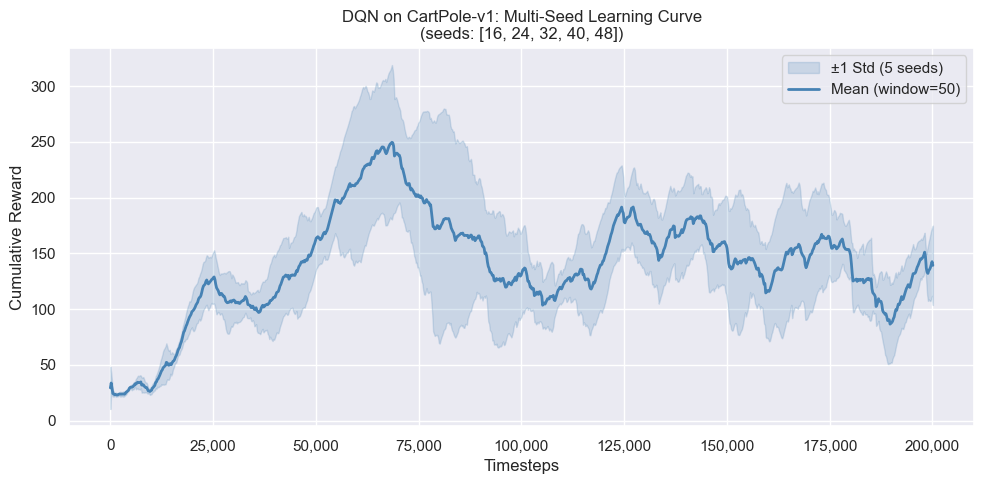

(array([ 29.4       ,  33.79164272,  29.01118465,  24.38923701,
         24.00820349,  23.26208942,  23.57615236,  23.23612304,
         23.02450463,  23.10504628,  23.65429915,  23.90591979,
         23.82514938,  23.71723312,  23.87670998,  23.8281906 ,
         23.91953437,  23.71849597,  24.26770063,  25.53940911,
         25.90507025,  26.59488512,  27.35358401,  29.0310011 ,
         29.79534388,  30.16661706,  29.95650929,  30.25923876,
         31.1059019 ,  31.79736105,  33.04306602,  32.80596329,
         33.49389768,  34.47150226,  34.25288147,  34.10232272,
         34.27202215,  34.75020869,  31.91011218,  31.95552573,
         32.23229873,  31.15140622,  30.16328319,  29.78815888,
         29.74000045,  28.23138372,  26.71928074,  26.62042088,
         26.14501878,  26.80374724,  27.22000393,  29.16476613,
         29.77620683,  30.66401786,  31.65269813,  34.3582591 ,
         34.8473098 ,  36.84424153,  37.54230605,  39.06016342,
         40.7546802 ,  42.56827387,  44.

In [11]:
print_multiseed_summary(cartpole_all_rewards, 'CartPole-v1', 'DQN', SEEDS)
plot_multiseed_learning_curve(cartpole_all_rewards, cartpole_all_lengths,
                              'CartPole-v1', 'DQN', SEEDS)

---
## **5. LunarLander-v3 - DQN Baseline**

LunarLander-v3 tasks the agent with landing a spacecraft on a designated landing pad using four discrete actions: do nothing, fire the left engine, fire the main engine, or fire the right engine. The agent receives positive rewards for moving towards the pad and landing successfully, and penalties for crashing or for excessive engine use. An episode score above 200 is generally considered a successful landing.

This environment is considerably harder than CartPole and typically requires 200,000+ timesteps for DQN to produce competent behaviour.

In [12]:
os.makedirs(BASELINE_LUNARLANDER_LOG, exist_ok=True)

lunarlander_all_rewards = []
lunarlander_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(BASELINE_LUNARLANDER_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'LunarLander-v3_seed{seed}_DQN_results.csv')
  env = Monitor(gym.make('LunarLander-v3'), BASELINE_LUNARLANDER_LOG)

  agent = DQN(
    policy='MlpPolicy',
    env=env,
    learning_rate=1e-3,
    buffer_size=1_000_000,
    learning_starts=10_000,
    batch_size=128,
    gamma=0.99,
    train_freq=4,
    target_update_interval=1000,
    exploration_fraction=0.12,
    exploration_final_eps=0.05,
    verbose=0,
    seed=seed
  )

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    cb = EpisodeLoggerCallback()
    print(f'Training DQN on LunarLander-v3 | Seed {seed} | {LUNARLANDER_TIMESTEPS:,} Timesteps...')
    agent.learn(total_timesteps=LUNARLANDER_TIMESTEPS, callback=cb, progress_bar=True)
    env.close()
    agent.save(model_path)
    df = save_results_to_csv(cb.episode_rewards, cb.episode_lengths,
                             f'LunarLander-v3_seed{seed}', 'DQN')
    lunarlander_all_rewards.append(cb.episode_rewards)
    lunarlander_all_lengths.append(cb.episode_lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing LunarLander DQN Model | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    lunarlander_all_rewards.append(_df['reward'].tolist())
    lunarlander_all_lengths.append(_df['length'].tolist())
    env.close()
    print('Loaded.')

save_aggregated_results_to_csv(lunarlander_all_rewards, lunarlander_all_lengths, 'LunarLander-v3', 'DQN')
print('\nAll Seeds Complete.')

Loading Existing LunarLander DQN Model | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander DQN Model | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander DQN Model | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander DQN Model | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander DQN Model | Seed 48 (RETRAIN_MODELS=False)...
Loaded.
Results Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_results.csv

All Seeds Complete.



=== DQN on LunarLander-v3:  Per-Seed Summary ===
  Seed  16 | Episodes:  9,794 | Mean:    93.96 | Late Mean (100):    99.78 | Std:  160.93
  Seed  24 | Episodes: 11,016 | Mean:    65.76 | Late Mean (100):   -42.14 | Std:  196.65
  Seed  32 | Episodes:  9,445 | Mean:    53.50 | Late Mean (100):  -118.67 | Std:  201.82
  Seed  40 | Episodes:  8,528 | Mean:    73.31 | Late Mean (100):   231.28 | Std:  156.14
  Seed  48 | Episodes: 11,114 | Mean:   -18.47 | Late Mean (100):  -551.04 | Std:  254.70

  Aggregate (5 seeds):
    Overall Mean  : 53.61 ± 38.37
    Late Mean     : -76.16 ± 266.06
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_multiseed_learning_curve.png


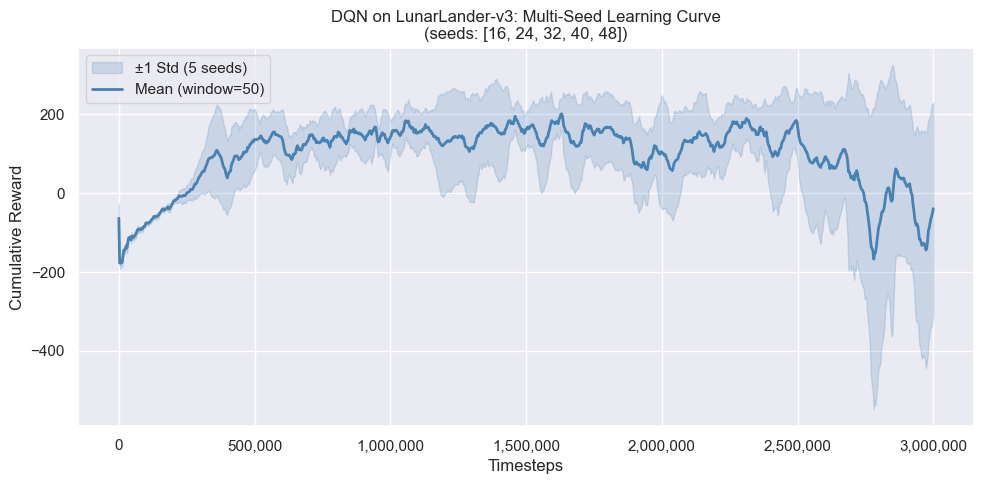

(array([ -63.4413666 , -176.71231097, -177.66867411, -175.89646088,
        -175.71515853, -160.45092163, -144.30062415, -145.16900482,
        -141.44215527, -132.82558048, -138.2172058 , -124.42645041,
        -113.2075268 , -112.11640943, -116.17964962, -118.00507541,
        -108.6469914 , -109.29133218, -112.0272539 , -108.1326136 ,
        -107.11297705, -102.31515036,  -96.87938418,  -92.66451364,
         -90.60316162,  -91.84245404,  -93.24372866,  -90.97140441,
         -88.95382751,  -90.4508469 ,  -85.82626133,  -83.65184517,
         -83.78565445,  -75.65283958,  -74.88923229,  -75.9570894 ,
         -76.32738787,  -74.48636267,  -72.3228149 ,  -70.9680436 ,
         -67.08139716,  -65.46971507,  -63.40827327,  -58.52637092,
         -59.70673083,  -60.58565252,  -58.66364709,  -58.89619611,
         -56.3138068 ,  -55.00751114,  -50.46652778,  -48.5118979 ,
         -44.70535679,  -40.98480165,  -39.95589734,  -43.58755953,
         -42.95181244,  -39.45838516,  -39.02953

In [13]:
print_multiseed_summary(lunarlander_all_rewards, 'LunarLander-v3', 'DQN', SEEDS)
plot_multiseed_learning_curve(lunarlander_all_rewards, lunarlander_all_lengths,
                              'LunarLander-v3', 'DQN', SEEDS)

---
## **6. MiniGrid-Empty-5x5-v0 - DQN Baseline**

MiniGrid provides a family of partially observable grid-world environments with goal-oriented tasks. The Empty-5x5 environment places the agent in a small empty room with a goal tile it must reach. The agent receives a reward based on how quickly it reaches the goal: `1 - 0.9 * (step_count / max_steps)`, meaning faster solutions receive higher rewards.

MiniGrid observations are dictionary-based by default, so a `FlatObsWrapper` is applied to convert them to a flat NumPy array compatible with SB3's `MlpPolicy`.

In [ ]:
os.makedirs(BASELINE_MINIGRID_LOG, exist_ok=True)

minigrid_dqn_all_rewards = []
minigrid_dqn_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(BASELINE_MINIGRID_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'{MINIGRID_ENV_ID}_seed{seed}_DQN_results.csv')
  env = Monitor(
    FlatObsWrapper(gym.make(MINIGRID_ENV_ID)),
    BASELINE_MINIGRID_LOG
  )

  agent = DQN(
    policy='MlpPolicy',
    env=env,
    learning_rate=5e-4,
    buffer_size=500_000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    target_update_interval=500,
    exploration_fraction=0.15,
    exploration_final_eps=0.05,
    verbose=0,
    seed=seed
  )

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    cb = EpisodeLoggerCallback()
    print(f'Training DQN on {MINIGRID_ENV_ID} | Seed {seed} | {MINIGRID_TIMESTEPS:,} Timesteps...')
    agent.learn(total_timesteps=MINIGRID_TIMESTEPS, callback=cb, progress_bar=True)
    env.close()
    agent.save(model_path)
    df = save_results_to_csv(cb.episode_rewards, cb.episode_lengths,
                             f'{MINIGRID_ENV_ID}_seed{seed}', 'DQN')
    minigrid_dqn_all_rewards.append(cb.episode_rewards)
    minigrid_dqn_all_lengths.append(cb.episode_lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing MiniGrid DQN Model | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    minigrid_dqn_all_rewards.append(_df['reward'].tolist())
    minigrid_dqn_all_lengths.append(_df['length'].tolist())
    env.close()
    print('Loaded.')

save_aggregated_results_to_csv(minigrid_dqn_all_rewards, minigrid_dqn_all_lengths, MINIGRID_ENV_ID, 'DQN')
print('\nAll Seeds Complete.')

Loading Existing MiniGrid DQN Model | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid DQN Model | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid DQN Model | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid DQN Model | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid DQN Model | Seed 48 (RETRAIN_MODELS=False)...
Loaded.
Results Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_results.csv

All Seeds Complete.



=== DQN on MiniGrid-Empty-5x5-v0:  Per-Seed Summary ===
  Seed  16 | Episodes: 44,701 | Mean:     0.90 | Late Mean (100):     0.93 | Std:    0.19
  Seed  24 | Episodes: 38,346 | Mean:     0.88 | Late Mean (100):     0.94 | Std:    0.22
  Seed  32 | Episodes: 39,227 | Mean:     0.88 | Late Mean (100):     0.94 | Std:    0.22
  Seed  40 | Episodes: 37,877 | Mean:     0.88 | Late Mean (100):     0.95 | Std:    0.22
  Seed  48 | Episodes: 44,605 | Mean:     0.90 | Late Mean (100):     0.92 | Std:    0.18

  Aggregate (5 seeds):
    Overall Mean  : 0.89 ± 0.01
    Late Mean     : 0.94 ± 0.01
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_multiseed_learning_curve.png


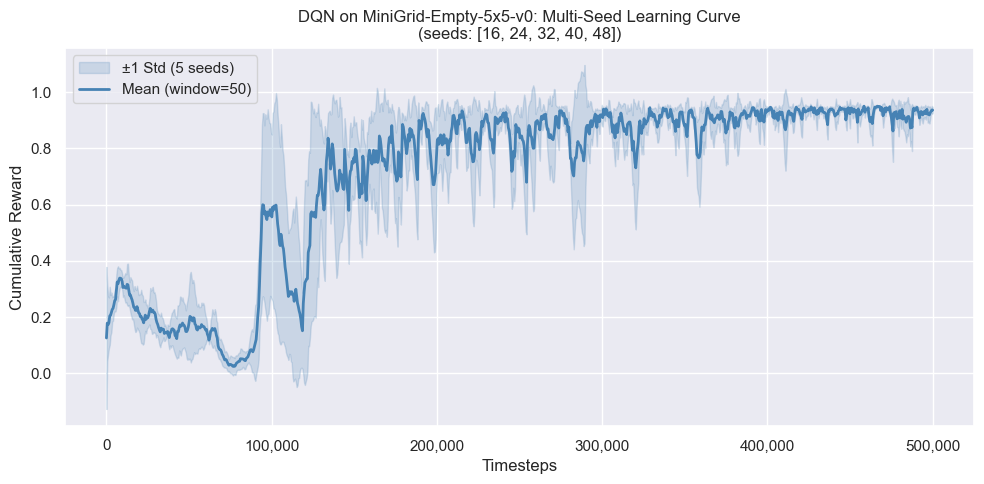

(array([0.1262    , 0.17897672, 0.17342964, 0.18001594, 0.20472553,
        0.2070822 , 0.21749739, 0.22748835, 0.2317042 , 0.24403636,
        0.25881496, 0.26286867, 0.2942939 , 0.32485772, 0.31887193,
        0.33087914, 0.33905929, 0.33856215, 0.33670407, 0.32698894,
        0.3055844 , 0.31018885, 0.30696907, 0.30446704, 0.30299343,
        0.31677947, 0.31514848, 0.29689734, 0.2785602 , 0.27914443,
        0.26961137, 0.26170379, 0.24979753, 0.23606967, 0.23473235,
        0.22443989, 0.22420528, 0.23748527, 0.22555061, 0.2155626 ,
        0.21268149, 0.20212655, 0.20258807, 0.1941705 , 0.1895146 ,
        0.18011895, 0.19491848, 0.20735256, 0.19245361, 0.20204559,
        0.19788778, 0.20637011, 0.22123113, 0.23132742, 0.22591938,
        0.21872739, 0.22523001, 0.21784661, 0.21740347, 0.21083517,
        0.19246996, 0.18132351, 0.174269  , 0.1638175 , 0.15515324,
        0.14790679, 0.16129447, 0.15677464, 0.15762374, 0.15712698,
        0.14209628, 0.14606195, 0.14461463, 0.14

In [15]:
print_multiseed_summary(minigrid_dqn_all_rewards, MINIGRID_ENV_ID, 'DQN', SEEDS)
plot_multiseed_learning_curve(minigrid_dqn_all_rewards, minigrid_dqn_all_lengths,
                              MINIGRID_ENV_ID, 'DQN', SEEDS)

---
## **7. MiniGrid-Empty-5x5-v0 - Tabular Q-Learning Baseline**

Tabular Q-learning maintains an explicit lookup table mapping state-action pairs to estimated action values. Unlike DQN, it does not use a neural network; it updates the Q-table directly using the Bellman equation after each step.

It is well-suited to small discrete environments like MiniGrid-Empty-5x5 where the full state space can be enumerated. SB3 does not include a tabular Q-learning implementation, so this is implemented from scratch.

The agent uses epsilon-greedy action selection: with probability epsilon it selects a random action (exploration), otherwise it selects the action with the highest estimated Q-value (exploitation). Epsilon decays over time so the agent gradually shifts from exploration to exploitation.

In [16]:
class TabularQLearningAgent:
  """
  Tabular Q-Learning agent using a dictionary as the Q-table.
  Keys are (state, action) tuples where state is derived from the flattened observation array.
  """
  def __init__(self, n_actions, learning_rate=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995):
    self.n_actions = n_actions
    self.lr = learning_rate
    self.gamma = gamma
    self.epsilon = epsilon_start
    self.epsilon_end = epsilon_end
    self.epsilon_decay = epsilon_decay
    self.q_table = {}

  def _state_key(self, obs):
    """Convert observation array to a hashable tuple key."""
    return tuple(obs.flatten().astype(int))

  def get_q(self, obs, action):
    """Return Q-value for a state-action pair, defaulting to 0.0."""
    return self.q_table.get((self._state_key(obs), action), 0.0)

  def select_action(self, obs):
    """Epsilon-greedy action selection."""
    if np.random.random() < self.epsilon:
      return np.random.randint(self.n_actions)
    q_values = [self.get_q(obs, a) for a in range(self.n_actions)]
    return int(np.argmax(q_values))

  def update(self, obs, action, reward, next_obs, terminated):
    """Q-Learning (off-policy TD) update rule."""
    current_q = self.get_q(obs, action)
    if terminated:
      target_q = reward
    else:
      next_q_values = [self.get_q(next_obs, a) for a in range(self.n_actions)]
      target_q = reward + self.gamma * max(next_q_values)
    self.q_table[(self._state_key(obs), action)] = (current_q + self.lr * (target_q - current_q))

  def decay_epsilon(self):
    """Decay exploration rate at the end of each episode."""
    self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)


print('TabularQLearningAgent Defined.')

TabularQLearningAgent Defined.


#### **!!! Note on Seeding**
**Tabular Q-Learning does not use an SB3 constructor and therefore cannot accept a seed argument directly.** Instead, np.random.seed(seed) is called at the start of each run to seed the epsilon-greedy action selection, and seed + episode is passed to env.reset() for reproducible environment initialisations. This is the closest equivalent to the SB3 seeding approach used for DQN agents and ensures cross-seed comparisons are methodologically consistent.

In [ ]:
os.makedirs(BASELINE_QL_MINIGRID_LOG, exist_ok=True)

ql_all_rewards = []
ql_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(BASELINE_QL_MINIGRID_AGENT, seed) + '.pkl'
  csv_path = os.path.join(RESULTS_DIRECTORY, f'{MINIGRID_ENV_ID}_seed{seed}_QLearning_results.csv')

  if RETRAIN_MODELS or not os.path.exists(model_path):
    np.random.seed(seed)

    ql_env = FlatObsWrapper(gym.make(MINIGRID_ENV_ID))
    n_actions = ql_env.action_space.n

    ql_agent = TabularQLearningAgent(
      n_actions=n_actions,
      learning_rate=0.1,
      gamma=0.99,
      epsilon_start=1.0,
      epsilon_end=0.05,
      epsilon_decay=0.995
    )

    episode_rewards = []
    episode_lengths = []

    print(f'Training Tabular Q-Learning on {MINIGRID_ENV_ID} | Seed {seed} | {QLEARNING_EPISODES} Episodes...')

    for episode in range(QLEARNING_EPISODES):
      obs, _ = ql_env.reset(seed=seed + episode)
      episode_reward = 0
      episode_length = 0
      terminated = False
      truncated = False

      while not (terminated or truncated):
        action = ql_agent.select_action(obs)
        next_obs, reward, terminated, truncated, _ = ql_env.step(action)
        ql_agent.update(obs, action, reward, next_obs, terminated)
        obs = next_obs
        episode_reward += reward
        episode_length += 1

      ql_agent.decay_epsilon()
      episode_rewards.append(episode_reward)
      episode_lengths.append(episode_length)

      if (episode + 1) % 200 == 0:
        recent_mean = np.mean(episode_rewards[-200:])
        print(f'  Episode {episode + 1:>4}/{QLEARNING_EPISODES} | '
              f'Mean Reward (Last 200): {recent_mean:.4f} | '
              f'Epsilon: {ql_agent.epsilon:.3f} | '
              f'Q-Table Entries: {len(ql_agent.q_table)}')

    ql_env.close()

    with open(model_path, 'wb') as f:
      pickle.dump(ql_agent, f)
    save_results_to_csv(episode_rewards, episode_lengths,
                        f'{MINIGRID_ENV_ID}_seed{seed}', 'QLearning')
    ql_all_rewards.append(episode_rewards)
    ql_all_lengths.append(episode_lengths)
    print(f'Training Complete. Model Saved To: {model_path}')

  else:
    print(f'Loading Existing Q-Learning Model | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    ql_all_rewards.append(_df['reward'].tolist())
    ql_all_lengths.append(_df['length'].tolist())
    print('Loaded.')

save_aggregated_results_to_csv(ql_all_rewards, ql_all_lengths, MINIGRID_ENV_ID, 'QLearning')
print('\nAll Seeds Complete.')

Loading Existing Q-Learning Model | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing Q-Learning Model | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing Q-Learning Model | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing Q-Learning Model | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing Q-Learning Model | Seed 48 (RETRAIN_MODELS=False)...
Loaded.
Results Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_QLearning_results.csv

All Seeds Complete.



=== Q-Learning on MiniGrid-Empty-5x5-v0:  Per-Seed Summary ===
  Seed  16 | Episodes:  2,000 | Mean:     0.93 | Late Mean (100):     0.95 | Std:    0.09
  Seed  24 | Episodes:  2,000 | Mean:     0.91 | Late Mean (100):     0.94 | Std:    0.13
  Seed  32 | Episodes:  2,000 | Mean:     0.93 | Late Mean (100):     0.95 | Std:    0.10
  Seed  40 | Episodes:  2,000 | Mean:     0.93 | Late Mean (100):     0.95 | Std:    0.09
  Seed  48 | Episodes:  2,000 | Mean:     0.93 | Late Mean (100):     0.95 | Std:    0.09

  Aggregate (5 seeds):
    Overall Mean  : 0.93 ± 0.01
    Late Mean     : 0.95 ± 0.00
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_Q-Learning_multiseed_learning_curve.png


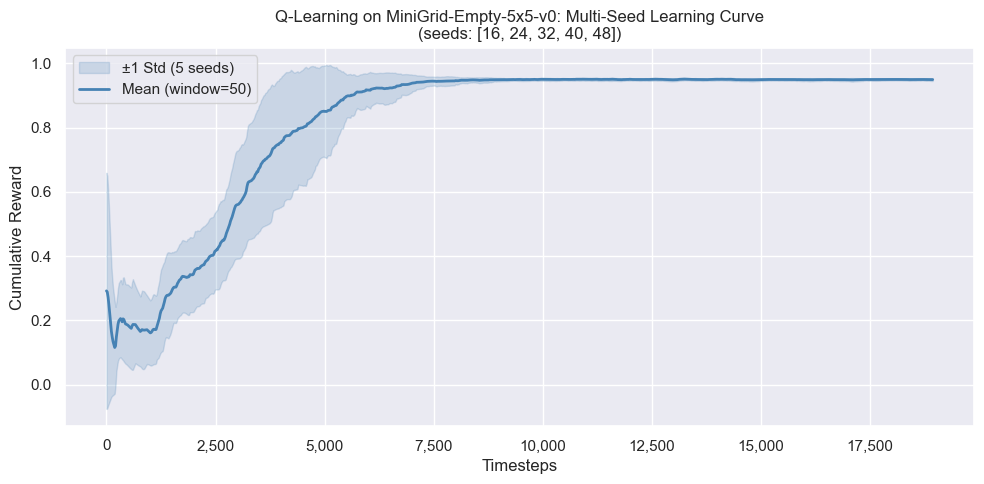

(array([0.292     , 0.28857723, 0.27217946, 0.24871853, 0.22104137,
        0.19336421, 0.16568706, 0.14821615, 0.13411091, 0.1248852 ,
        0.11565948, 0.12044683, 0.14843455, 0.16821458, 0.18789328,
        0.1987191 , 0.20244186, 0.20563551, 0.20339382, 0.19568592,
        0.20491894, 0.20298551, 0.19583278, 0.18914202, 0.18791001,
        0.18670002, 0.18495688, 0.18227011, 0.17961202, 0.17739506,
        0.17530453, 0.18257239, 0.18744766, 0.18726786, 0.18714612,
        0.18704469, 0.18303203, 0.17915313, 0.17554537, 0.17210461,
        0.16880942, 0.16556315, 0.16868921, 0.17144382, 0.1701632 ,
        0.16982405, 0.16981953, 0.17025934, 0.1707137 , 0.17106721,
        0.16883343, 0.1662389 , 0.16373855, 0.16123819, 0.16230754,
        0.16559313, 0.17026041, 0.17252495, 0.17244212, 0.1712788 ,
        0.17189043, 0.18072392, 0.19042252, 0.19719629, 0.20677342,
        0.22043464, 0.22960771, 0.23354356, 0.23810908, 0.24711384,
        0.25696313, 0.26810128, 0.27439976, 0.27

In [18]:
print_multiseed_summary(ql_all_rewards, MINIGRID_ENV_ID, 'Q-Learning', SEEDS)
plot_multiseed_learning_curve(ql_all_rewards, ql_all_lengths,
                              MINIGRID_ENV_ID, 'Q-Learning', SEEDS)

---
## **8. Baseline Evaluation**

This section evaluates the four baseline agents (CartPole DQN, LunarLander DQN, MiniGrid DQN, and MiniGrid Tabular Q-Learning) on a common set of metrics: comparative learning curves, convergence speed, and late-window reward stability. It also includes a statistical significance test comparing DQN and Q-Learning on MiniGrid.

Run after Sections 4–7 to ensure monitor logs and results CSVs are present. The cells below use rolling means, saved figures under `results/`, and the shared `summarize_run` and `plot_run_bars` utilities defined here.

Per-seed results files are saved during training as `{env}_{agent}_seed{N}_results.csv`. This section reads from the aggregated (unseeded) CSVs produced by `save_aggregated_results_to_csv` at the end of each training section, which concatenate all five seeds into a single series for cross-condition comparison:
- `CartPole-v1_DQN_results.csv`
- `LunarLander-v3_DQN_results.csv`
- `MiniGrid-Empty-5x5-v0_DQN_results.csv`
- `MiniGrid-Empty-5x5-v0_QLearning_results.csv`

### **8.1. Comparative Learning Curves**

DQN runs are read from Stable Baselines3 `Monitor` files under `logs/` (`r` = return, `l` = length in env steps). MiniGrid Q-learning uses the saved results CSV (`reward`, `length`), same schema as `save_results_to_csv` in Section 3.2.

- **Horizontal Axis:** cumulative timesteps at each episode end (running sum of episode lengths), so curves are comparable in terms of environment experience.
- **Rolling Means:** `rolling(window=w, min_periods=1)` on the reward series, as in `plot_learning_curve`, but two windows are plotted: 50 episodes in steelblue and 2000 episodes in vivid orange (`#ea580c`) so both short-horizon improvement and a smoother long-horizon level appear.

Figures are saved next to the per-environment learning curves from earlier sections.

Comparative learning curve: CartPole-v1 | DQN | 0 episodes
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_comparative_learning_curve.png


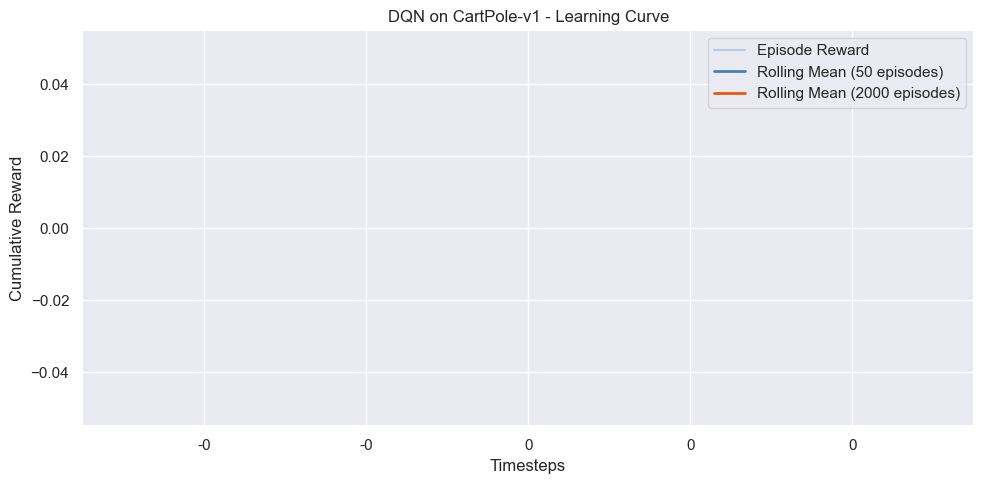

Comparative learning curve: LunarLander-v3 | DQN | 0 episodes
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_comparative_learning_curve.png


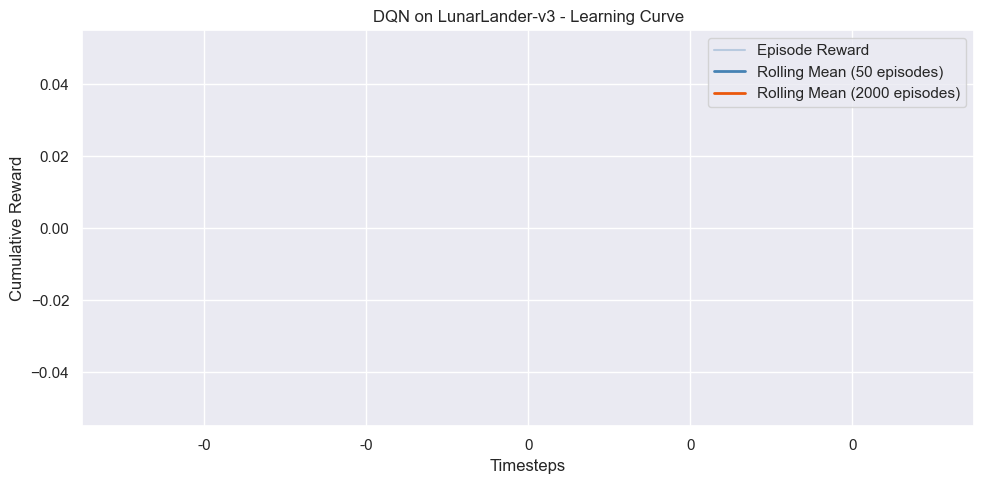

Comparative learning curve: MiniGrid-Empty-5x5-v0 | DQN | 0 episodes
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_comparative_learning_curve.png


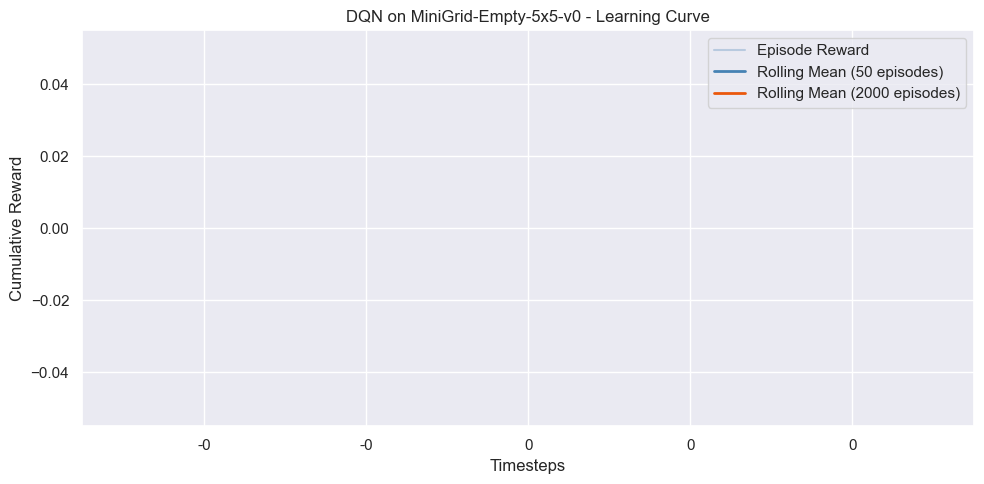

Comparative learning curve: MiniGrid-Empty-5x5-v0 | QLearning | 10000 episodes
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_QLearning_comparative_learning_curve.png


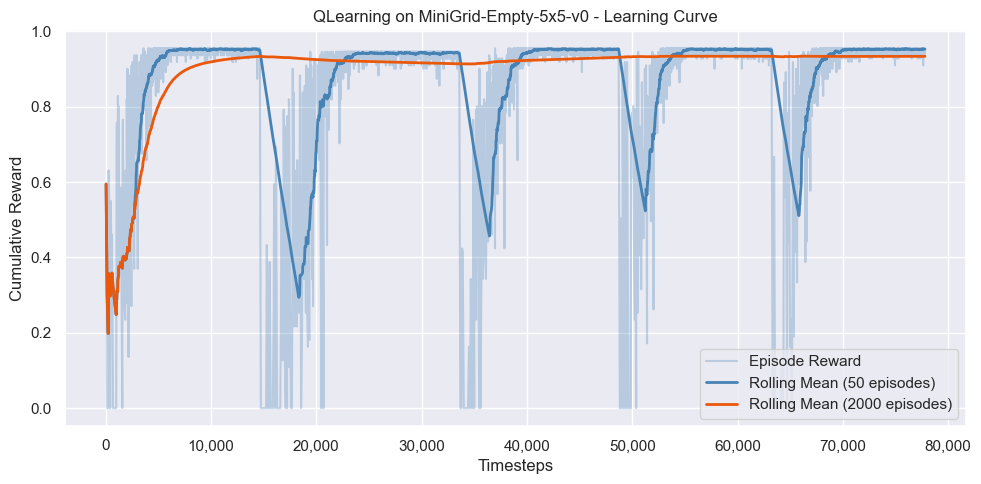

In [ ]:
def load_episode_series_for_comparison(env_id, agent, monitor_relative):
  """Returns (rewards, episode_lengths) per finished episode:  Monitor `r`/`l` or results CSV."""
  if monitor_relative:
    path = os.path.join(LOG_DIRECTORY, monitor_relative)
    if not os.path.isfile(path):
      raise FileNotFoundError(path)
    mon = pd.read_csv(path, comment='#')
    rewards = mon['r'].to_numpy(dtype=float)
    lengths = mon['l'].to_numpy(dtype=float)
    return rewards, lengths
  path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  if not os.path.isfile(path):
    raise FileNotFoundError(path)
  df = pd.read_csv(path).sort_values('episode')
  rewards = df['reward'].to_numpy(dtype=float)
  lengths = df['length'].to_numpy(dtype=float)
  return rewards, lengths


def plot_learning_curve_two_windows(rewards, episode_lengths, env_name, agent_name, save=True):
  """
  Plots episode rewards and two rolling means (WINDOW_SHORT and WINDOW_LONG) against cumulative timesteps.
  Saves to RESULTS_DIRECTORY when save=True, same pattern as plot_learning_curve.
  """
  rewards = np.asarray(rewards, dtype=float)
  lengths = np.asarray(episode_lengths, dtype=float)
  x_steps = np.cumsum(lengths)

  rolling_specs = [
    (WINDOW_SHORT, 'steelblue'),
    (WINDOW_LONG, '#ea580c'),
  ]

  fig, ax = plt.subplots()
  ax.plot(x_steps, rewards, alpha=0.3, color='steelblue', label='Episode Reward')
  for window, color in rolling_specs:
    rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
    ax.plot(x_steps, rolling_mean, color=color, linewidth=2,
            label=f'Rolling Mean ({window} episodes)')
  ax.set_xlabel('Timesteps')
  ax.set_ylabel('Cumulative Reward')
  ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:,.0f}'))
  ax.set_title(f'{agent_name} on {env_name} - Learning Curve')
  ax.legend()
  plt.tight_layout()

  if save:
    filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_comparative_learning_curve.png')
    fig.savefig(filename, dpi=150)
    print(f'Figure Saved To: {filename}')
  plt.show()


for env_id, agent, mon_rel in COMPARISON_SOURCES:
  try:
    rewards, lengths = load_episode_series_for_comparison(env_id, agent, mon_rel)
  except FileNotFoundError as err:
    print(f'Skip (file not found): {env_id} | {agent} | {err}')
    continue
  src = os.path.join(LOG_DIRECTORY, mon_rel) if mon_rel else os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  print(f'Comparative learning curve: {env_id} | {agent} | {len(rewards)} episodes')
  plot_learning_curve_two_windows(rewards, lengths, env_id, agent)


### **8.2. Convergence, Mean Reward, and Stability**

The next cell uses each run’s results CSV and the same 2000-episode rolling mean as in 8.1 to define convergence, plus late-window reward statistics.

**Mean reward (late)** is the mean of raw rewards over the last `min(2000, n)` episodes (`n` = run length).

**Stability** is the standard deviation of raw rewards in that same window (lower means less episode-to-episode scatter).

**Convergence** is the first episode whose 2000-episode rolling mean lies within 5% of a terminal plateau: the mean of that rolling curve over its last 200 episodes (or fewer if the run is short). That reduces false “early” convergence when the smoothed curve spikes and then drifts down. If there are fewer than 2000 episodes, the scan still runs from the start of the series so the row is not empty. The table lists convergence episode index and cumulative environment steps at that episode (`cumsum` of `length`). If the criterion is never satisfied, those entries are not available.

Late mean reward is printed in the table only. The first bar chart shows convergence timesteps with a logarithmic vertical axis so very long runs remain comparable to shorter ones. The second bar chart shows late-window standard deviation (lower is more stable).

In [20]:
def summarize_run(rewards, episode_lengths, w_long=WINDOW_LONG):
  """
  Summarizes a run from results CSV columns: late-window mean and std, convergence episode and timestep.
  Convergence uses the w_long rolling mean (min_periods=1) and a terminal plateau asymptote (mean of that
  curve over the last plateau_episodes), so a temporary spike does not count as converged.
  """
  s = pd.Series(np.asarray(rewards, dtype=float))
  L = np.asarray(episode_lengths, dtype=float)
  cum_steps = np.cumsum(L)
  n = len(s)
  tail_n = min(w_long, n)
  late_start = n - tail_n
  r_long = s.rolling(window=w_long, min_periods=1).mean()
  late_rewards = s.iloc[late_start:]
  mean_late = float(late_rewards.mean())
  std_late = float(late_rewards.std(ddof=0))
  plateau_episodes = min(200, n)
  asymptote = float(r_long.iloc[-plateau_episodes:].mean())
  tol = 0.05 * max(abs(asymptote), 1e-6)
  conv_ep = np.nan
  conv_step = np.nan
  # Runs shorter than w_long would leave range(w_long - 1, n) empty: no convergence reported.
  start = 0 if n < w_long else w_long - 1
  for i in range(start, n):
    if abs(r_long.iloc[i] - asymptote) <= tol:
      conv_ep = int(i + 1)
      conv_step = float(cum_steps[i])
      break
  return {
    'mean_all': float(s.mean()),
    'mean_late': mean_late,
    'stability_std_late': std_late,
    'convergence_episode': conv_ep,
    'convergence_timestep': conv_step,
    'n_episodes': n,
  }



=== Comparative metrics (all runs) ===

          Environment      Agent  n_episodes   mean_all   mean_late  stability_std_late  convergence_episode  convergence_timestep
          CartPole-v1        DQN        9176 108.986595  110.126000          124.363110                 2333              217033.0
       LunarLander-v3        DQN       49897  51.501987 -402.278015          231.121047                49688            14983668.0
MiniGrid-Empty-5x5-v0        DQN      204756   0.886550    0.909552            0.149425                 5821              170081.0
MiniGrid-Empty-5x5-v0 Q-Learning       10000   0.929321    0.933912            0.092999                 2000               14644.0
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\comparative_convergence_timesteps.png


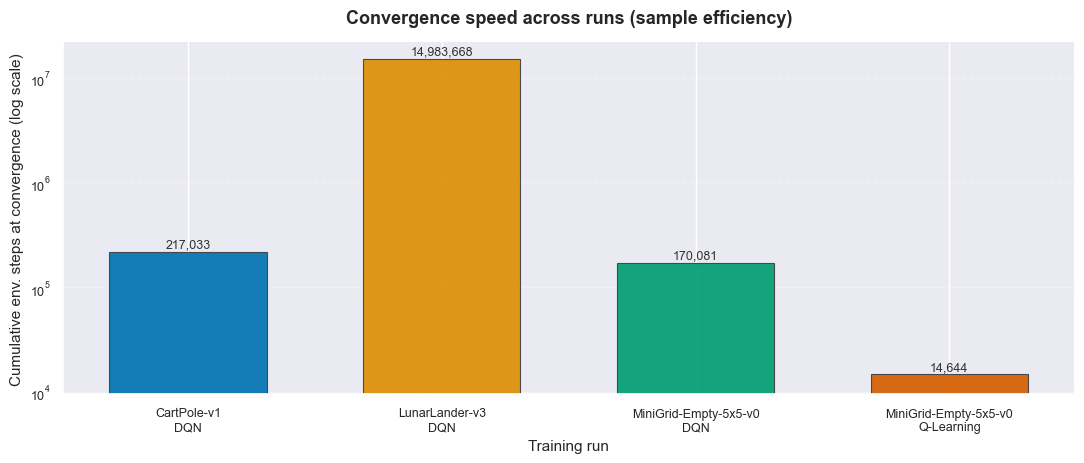

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\comparative_stability_std.png


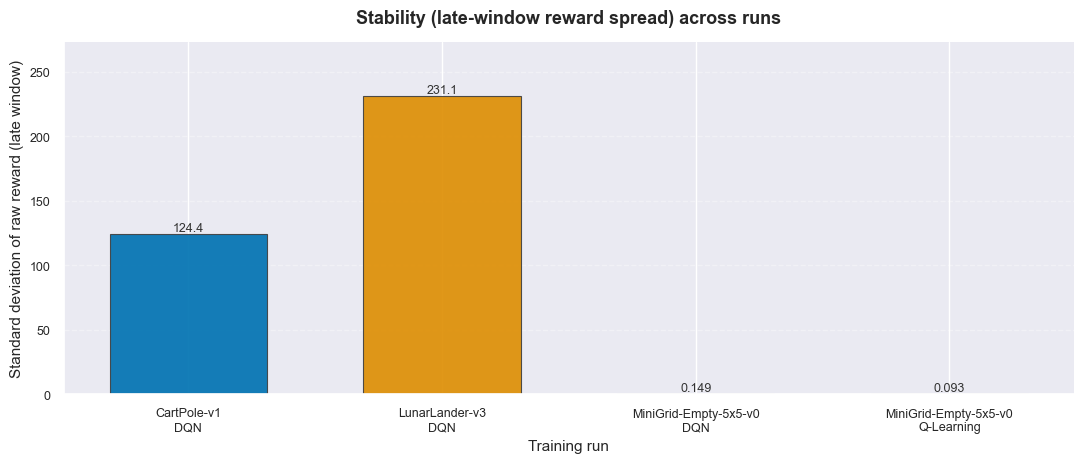

In [ ]:
def display_name(agent):
  return 'Q-Learning' if agent == 'QLearning' else agent


summary_rows = []
for env_id, agent, _ in COMPARISON_SOURCES:
  path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  if not os.path.isfile(path):
    print(f'Skip (file not found): {path}')
    continue
  run_df = pd.read_csv(path).sort_values('episode')
  rewards = run_df['reward'].to_numpy()
  lengths = run_df['length'].to_numpy(dtype=float)
  m = summarize_run(rewards, lengths)
  label = f'{env_id}\n{display_name(agent)}'
  summary_rows.append({
    'Run': label,
    'Environment': env_id,
    'Agent': display_name(agent),
    **m,
  })

summary_df = pd.DataFrame(summary_rows)
cols_show = [
  'Environment', 'Agent', 'n_episodes', 'mean_all', 'mean_late',
  'stability_std_late', 'convergence_episode', 'convergence_timestep',
]
print('\n=== Comparative metrics (all runs) ===\n')
print(summary_df[cols_show].to_string(index=False))

# Late mean reward: table only. Two bar charts: convergence timesteps, then late-window std.
run_labels = summary_df['Run'].tolist()
n = len(summary_df)
x = np.arange(n)
bar_colors = sns.color_palette('colorblind', n_colors=max(n, 3))[:n]


def style_metric_figure(ax, ylabel, subtitle):
  ax.set_ylabel(ylabel, fontsize=11)
  ax.set_xlabel('Training run', fontsize=11)
  ax.grid(axis='y', linestyle='--', alpha=0.35)
  ax.set_axisbelow(True)
  sns.despine(ax=ax, top=True, right=True)
  ax.tick_params(axis='x', labelsize=9)
  ax.tick_params(axis='y', labelsize=9)
  ax.set_title(subtitle, fontsize=13, fontweight='semibold', pad=14)


def plot_run_bars(values, ylabel, title, filename, value_fmt, log_y=False):
  fig, ax = plt.subplots(figsize=(11, 4.8))
  vals = np.asarray(values, dtype=float)
  bar_heights = np.where(np.isfinite(vals), vals, np.nan)
  bars = ax.bar(
    x, bar_heights, color=bar_colors, width=0.62,
    edgecolor='0.25', linewidth=0.8, alpha=0.92,
  )
  ax.set_xticks(x)
  ax.set_xticklabels(run_labels)
  finite_vals = vals[np.isfinite(vals)]
  if log_y:
    if finite_vals.size and float(np.min(finite_vals)) > 0:
      ax.set_yscale('log')
      lo = float(np.min(finite_vals))
      hi = float(np.max(finite_vals))
      ax.set_ylim(lo * 0.65, hi * 1.45)
    else:
      ax.set_yscale('log')
  else:
    ymax = float(np.max(finite_vals)) if finite_vals.size else 1.0
    ax.set_ylim(0, ymax * 1.18 if ymax > 0 else 1.0)
  style_metric_figure(ax, ylabel, title)
  ymax_lin = float(np.max(finite_vals)) if finite_vals.size else 1.0
  for bar, v in zip(bars, vals):
    if not np.isfinite(v):
      if log_y and finite_vals.size and float(np.min(finite_vals)) > 0:
        ymin, _ = ax.get_ylim()
        y_note = ymin * 1.08
      else:
        y_note = 0.02 * ymax_lin if ymax_lin > 0 else 0.02
      ax.text(bar.get_x() + bar.get_width() / 2, y_note,
              'n/a', ha='center', va='bottom', fontsize=9, color='0.35')
    else:
      ytxt = bar.get_height()
      ylab = ytxt * 1.04 if log_y else ytxt
      ax.text(bar.get_x() + bar.get_width() / 2, ylab, value_fmt(v),
              ha='center', va='bottom', fontsize=9, fontweight='medium', color='0.2')
  fig.tight_layout()
  out = os.path.join(RESULTS_DIRECTORY, filename)
  fig.savefig(out, dpi=150, bbox_inches='tight')
  print(f'Figure Saved To: {out}')
  plt.show()


conv_steps = summary_df['convergence_timestep'].to_numpy(dtype=float)
conv_plot = np.where(np.isfinite(conv_steps), conv_steps, np.nan)
plot_run_bars(
  conv_plot,
  'Cumulative Env. Steps At Convergence (Log Scale)',
  'Convergence Speed Across Runs (Sample Efficiency)',
  'comparative_convergence_timesteps.png',
  lambda v: f'{int(round(v)):,}',
  log_y=True,
)

stab = summary_df['stability_std_late'].to_numpy(dtype=float)
plot_run_bars(
  stab,
  'Standard Deviation of Raw Reward (Late Window)',
  'Stability (Late-Window Reward Spread) Across Runs',
  'comparative_stability_std.png',
  lambda v: f'{v:.3f}' if abs(v) < 100 else f'{v:.1f}',
)


### **8.3. Statistical Significance Testing: MiniGrid DQN vs Q-Learning**

This section compares DQN and Q-Learning on MiniGrid using a formal significance test, since descriptive statistics alone do not establish whether the observed performance difference is meaningful or a product of sampling variance. Normality is checked first using the Shapiro-Wilk test to determine whether a parametric or non-parametric test is appropriate.

In [22]:
def load_late_rewards(env_id, agent, window=LATE_WINDOW):
  """Returns rewards in the late window (last LATE_WINDOW episodes) for a given run."""
  path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  df = pd.read_csv(path).sort_values('episode')
  rewards = df['reward'].to_numpy(dtype=float)
  return rewards[-window:]

In [ ]:
dqn_late = load_late_rewards(MINIGRID_ENV_ID, 'DQN')
ql_late = load_late_rewards(MINIGRID_ENV_ID, 'QLearning')


def check_normality(sample, label, alpha=ALPHA):
  """Performs Shapiro-Wilk test for normality and prints results."""
  stat, p_value = stats.shapiro(sample)
  print(f'{label} | Shapiro-Wilk Test: W={stat:.4f}, p={p_value:.4f}')
  if p_value > alpha:
    print(f'  Fail to Reject Null Hypothesis: {label} Rewards Are Likely Normally Distributed.')
    return True
  else:
    print(f'  Reject Null Hypothesis: {label} Rewards Are Not Normally Distributed.')
    return False


print('Normality Tests for Late-Window Rewards:')
dqn_normal = check_normality(dqn_late, 'DQN')
ql_normal = check_normality(ql_late, 'Q-Learning')
print(f'\nBoth Samples Normal: {dqn_normal and ql_normal}')
print(f'Test Selected: {"t-test" if dqn_normal and ql_normal else "Mann-Whitney U Test"}')

Normality Tests for Late-Window Rewards:
DQN | Shapiro-Wilk Test: W=0.2922, p=0.0000
  Reject Null Hypothesis: DQN Rewards Are Not Normally Distributed.
Q-Learning | Shapiro-Wilk Test: W=0.3339, p=0.0000
  Reject Null Hypothesis: Q-Learning Rewards Are Not Normally Distributed.

Both Samples Normal: False
Test Selected: Mann-Whitney U Test


In [ ]:
def cohens_d(x, y):
  """Calculates Cohen's d for two samples."""
  nx = len(x)
  ny = len(y)
  dof = nx + ny - 2
  pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
  if pooled_std == 0:
    return 0.0
  return (np.mean(x) - np.mean(y)) / pooled_std

def interpret_d(d):
  """Interprets Cohen's d effect size."""
  if abs(d) < 0.2:
    return 'negligible'
  elif abs(d) < 0.5:
    return 'small'
  elif abs(d) < 0.8:
    return 'medium'
  else:
    return 'large'
    
if dqn_normal and ql_normal:
  stat, p_value = stats.ttest_ind(dqn_late, ql_late, equal_var=False)
  test_name = 'Independent t-test'
  stat_label, stat_val = 't', stat
else:
  stat, p_value = stats.mannwhitneyu(dqn_late, ql_late, alternative='two-sided')
  test_name = 'Mann-Whitney U test'
  stat_label, stat_val = 'U', stat

d = cohens_d(dqn_late, ql_late)
mag = interpret_d(d)
sig = p_value < ALPHA

print(f'\n{test_name} Results:')
print(f'  {stat_label} statistic: {stat_val:.4f}, p-value: {p_value:.4f}')
print(f'  Effect size (Cohen\'s d): {d:.3f} ({mag} effect)')
print(f'  Statistical significance at alpha={ALPHA}: {"Yes" if sig else "No"}')
print(f'd: {d:.3f} | Interpretation: {mag} effect')
print(f'Magnitude: {mag}')
print(f'Direction: {"DQN > Q-Learning" if d > 0 else "Q-Learning > DQN" if d < 0 else "No difference"}')

print(f' Late-window descriptive stats:({LATE_WINDOW})')
for label, sample in [('DQN', dqn_late), ('Q-Learning', ql_late)]:
  print(f'  {label:12s}  mean={np.mean(sample):.4f}  '
        f'std={np.std(sample, ddof=1):.4f}  '
        f'median={np.median(sample):.4f}')


Mann-Whitney U test Results:
  U statistic: 4094.0000, p-value: 0.0014
  Effect size (Cohen's d): -0.356 (small effect)
  Statistical significance at alpha=0.05: Yes
d: -0.356 | Interpretation: small effect
Magnitude: small
Direction: Q-Learning > DQN
 Late-window descriptive stats:(100)
  DQN           mean=0.9211  std=0.1272  median=0.9550
  Q-Learning    mean=0.9531  std=0.0064  median=0.9550


Absolute mean difference : -0.0320
Relative difference      : -3.36%
DQN mean                 : 0.9211
Q-Learning mean          : 0.9531
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_significance_test.png


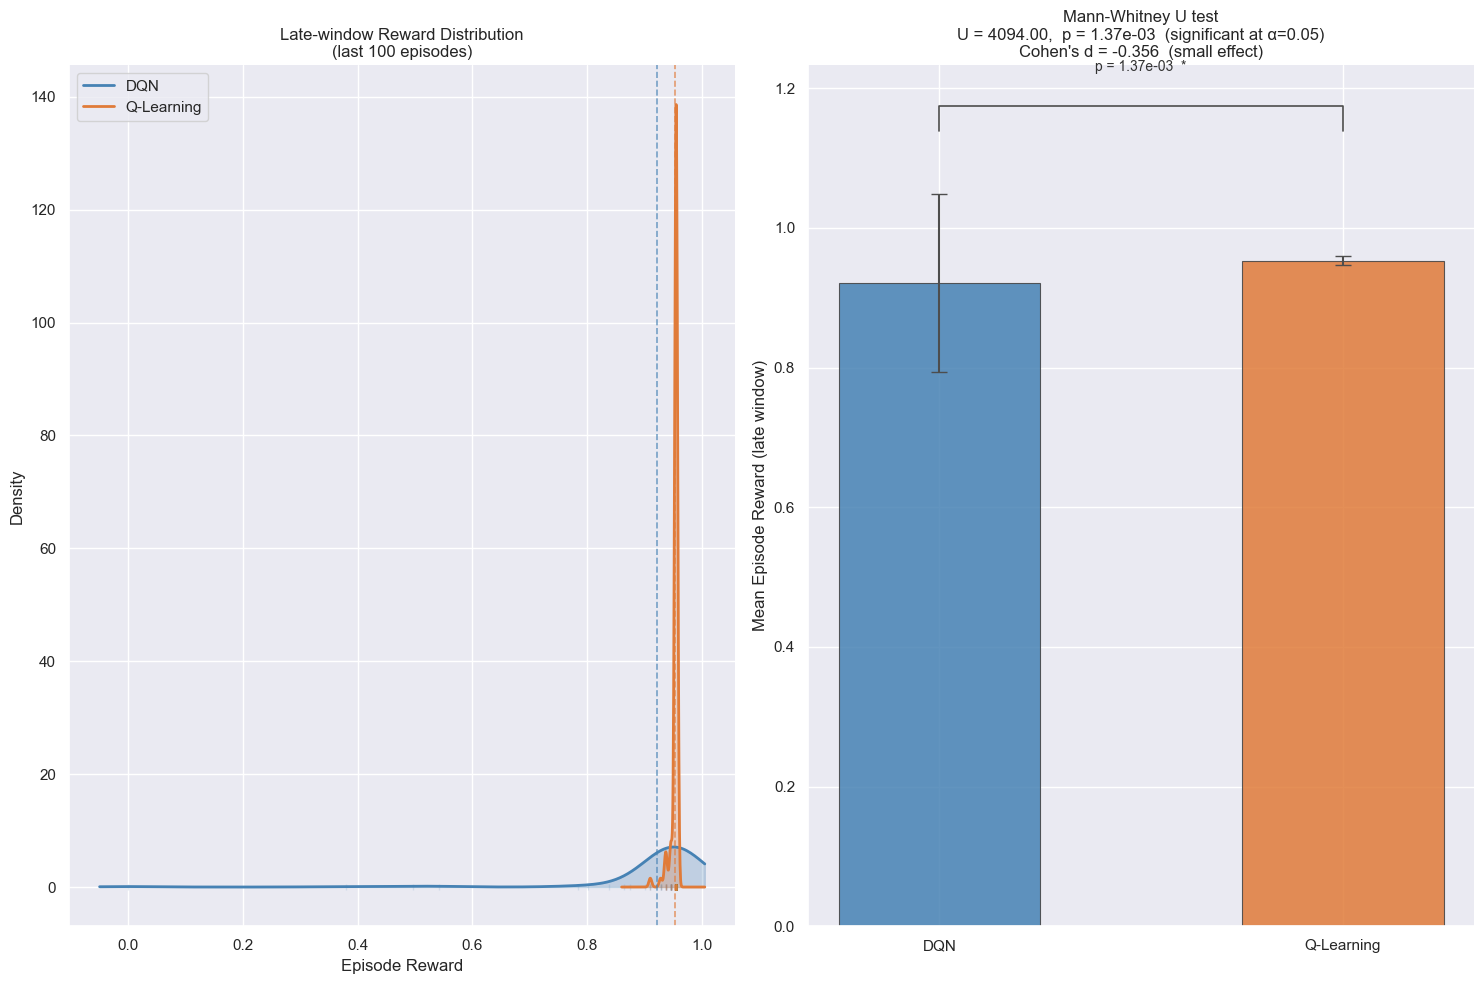

In [ ]:
def plot_significance_summary(dqn_rewards, ql_rewards,
                            test_name, stat_label, stat_val,
                            p_val, d, mag, alpha=ALPHA, window=LATE_WINDOW):
  """Plots a comparative bar chart of late-window rewards with test results annotated."""
  fig, axes = plt.subplots(1,2, figsize=(15, 10))
  # distribution comparison
  ax = axes[0]
  for rewards, label, color in [
    (dqn_rewards, 'DQN', 'steelblue'),
    (ql_rewards, 'Q-Learning', '#e07b39'),
  ]:
    kde_x = np.linspace(rewards.min() - 0.05, rewards.max() + 0.05, 300)
    kde = stats.gaussian_kde(rewards)
    ax.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2, label=label)
    ax.plot(rewards, np.full_like(rewards, -0.02),
            '|', color=color, alpha=0.15, markersize=4)

  ax.axvline(np.mean(dqn_rewards), color='steelblue',
             linestyle='--', linewidth=1.2, alpha=0.7)
  ax.axvline(np.mean(ql_rewards), color='#e07b39',
             linestyle='--', linewidth=1.2, alpha=0.7)

  ax.set_xlabel('Episode Reward')
  ax.set_ylabel('Density')
  ax.set_title(f'Late-window Reward Distribution\n(last {window} episodes)')
  ax.legend()
  sns.despine(ax=ax)
  # Means with error bars
  ax2 = axes[1]
  labels = ['DQN', 'Q-Learning']
  means = [np.mean(dqn_rewards), np.mean(ql_rewards)]
  stds = [np.std(dqn_rewards, ddof=1), np.std(ql_rewards, ddof=1)]
  colors = ['steelblue', '#e07b39']
  x_pos = np.array([0, 1])

  bars = ax2.bar(x_pos, means, color=colors, alpha=0.85,
                 width=0.5, edgecolor='0.25', linewidth=0.8)
  ax2.errorbar(x_pos, means, yerr=stds,
               fmt='none', color='0.3', capsize=6, linewidth=1.5)

  # Significance bracket
  y_top  = max(m + s for m, s in zip(means, stds))
  y_line = y_top * 1.12
  y_text = y_line * 1.04
  ax2.plot([0, 0, 1, 1], [y_line * 0.97, y_line, y_line, y_line * 0.97],
           color='0.3', linewidth=1.2)
  sig_str = (f'p = {p_val:.2e} *' if sig
             else f'p = {p_val:.2e} n.s.')
  ax2.text(0.5, y_text, sig_str,
           ha='center', va='bottom', fontsize=10, color='0.2')

  ax2.set_xticks(x_pos)
  ax2.set_xticklabels(labels)
  ax2.set_ylabel('Mean Episode Reward (late window)')
  ax2.set_title(
    f'{test_name}\n'
    f"{stat_label} = {stat_val:.2f},  p = {p_val:.2e}  "
    f"({'significant' if sig else 'not significant'} at α={alpha})\n"
    f"Cohen's d = {d:+.3f}  ({mag} effect)"
  )
  sns.despine(ax=ax2)
  plt.tight_layout()

  filename = os.path.join(RESULTS_DIRECTORY,
                          f'{MINIGRID_ENV_ID}_significance_test.png')
  fig.savefig(filename, dpi=150, bbox_inches='tight')
  print(f'Figure Saved To: {filename}')
  plt.show()
mean_diff = np.mean(dqn_late) - np.mean(ql_late)

pct_diff = (mean_diff / np.mean(ql_late)) * 100

print(f'Absolute Mean Difference : {mean_diff:+.4f}')
print(f'Relative Difference      : {pct_diff:+.2f}%')
print(f'DQN Mean                 : {np.mean(dqn_late):.4f}')
print(f'Q-Learning Mean          : {np.mean(ql_late):.4f}')

plot_significance_summary(
  dqn_late, ql_late,
  test_name, stat_label, stat_val,
  p_value, d, mag
)

### **8.4. Greedy Policy Evaluation**
This section evaluates the trained MiniGrid agents deterministically, separate from their training performance, to assess the quality of the final learned policy independently of the learning trajectory.

In [ ]:
def evaluate_policy(agent, env, episodes=100):
  """Evaluates a trained agent over a specified number of episodes."""
  rewards = []
  for ep in range(episodes):
    obs, _ = env.reset(seed=SEED + 1000 + ep)
    done = False
    total_reward = 0
    while not done:
      action, _ = agent.predict(obs, deterministic=True)
      obs, reward, terminated, truncated, _ = env.step(action)
      total_reward += reward
      done = terminated or truncated
    rewards.append(total_reward)
  return rewards

# evaluate_policy is available for live deterministic rollouts if needed.
# Results below are loaded from saved CSVs for consistency with training data.

In [ ]:
EVAL_EPISODES = 100

dqn_eval_rewards = load_late_rewards(MINIGRID_ENV_ID, 'DQN', EVAL_EPISODES)
ql_eval_rewards = load_late_rewards(MINIGRID_ENV_ID, 'QLearning', EVAL_EPISODES)

print(f'Final {EVAL_EPISODES}-episode performance (from saved results):')
print(f'  DQN        : {np.mean(dqn_eval_rewards):.4f} ± {np.std(dqn_eval_rewards, ddof=1):.4f}')
print(f'  Q-Learning : {np.mean(ql_eval_rewards):.4f} ± {np.std(ql_eval_rewards, ddof=1):.4f}')

eval_df = pd.DataFrame({
  'agent': ['DQN'] * EVAL_EPISODES + ['Q-Learning'] * EVAL_EPISODES,
  'reward': list(dqn_eval_rewards) + list(ql_eval_rewards)
})
filename = os.path.join(RESULTS_DIRECTORY, 'MiniGrid_greedy_evaluation.csv')
eval_df.to_csv(filename, index=False)
print(f'Saved: {filename}')

Final 100-episode performance (from saved results):
  DQN        : 0.9211 ± 0.1272
  Q-Learning : 0.9531 ± 0.0064
Saved: D:\Projects\project18-rl-reward-shaping\results\MiniGrid_greedy_evaluation.csv


Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid_greedy_evaluation_plot.png


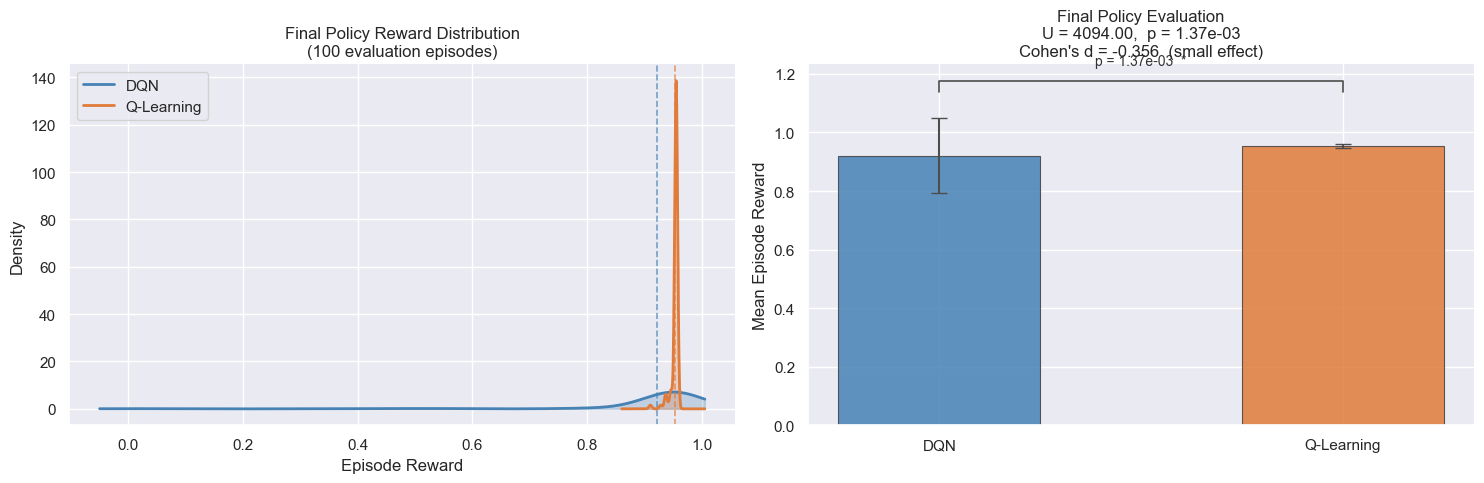

In [ ]:
def plot_greedy_evaluation(dqn_rewards, ql_rewards, episodes=EVAL_EPISODES):
  """
  Two-panel figure for greedy/final policy evaluation:
    Left:  overlapping KDE showing final policy reward distributions
    Right: means with ±1 SD error bars and significance annotation
  """
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  # Run significance test on evaluation rewards
  _, p_normal_dqn = stats.shapiro(dqn_rewards)
  _, p_normal_ql  = stats.shapiro(ql_rewards)
  both_normal = (p_normal_dqn > ALPHA) and (p_normal_ql > ALPHA)

  if both_normal:
    stat_val, p_val = stats.ttest_ind(dqn_rewards, ql_rewards, equal_var=False)
    stat_label, test_name = 't', "Welch's t-test"
  else:
    stat_val, p_val = stats.mannwhitneyu(dqn_rewards, ql_rewards, alternative='two-sided')
    stat_label, test_name = 'U', 'Mann-Whitney U'

  d   = cohens_d(np.array(dqn_rewards), np.array(ql_rewards))
  mag = interpret_d(d)
  sig = p_val < ALPHA

  # KDE distributions
  ax = axes[0]
  for rewards, label, color in [
      (dqn_rewards, 'DQN', 'steelblue'),
      (ql_rewards, 'Q-Learning', '#e07b39'),
  ]:
    rewards = np.array(rewards)
    kde_x = np.linspace(rewards.min() - 0.05, rewards.max() + 0.05, 300)
    kde = stats.gaussian_kde(rewards)
    ax.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2, label=label)
    ax.axvline(np.mean(rewards), color=color, linestyle='--',
               linewidth=1.2, alpha=0.7)

  ax.set_xlabel('Episode Reward')
  ax.set_ylabel('Density')
  ax.set_title(f'Final Policy Reward Distribution\n({episodes} evaluation episodes)')
  ax.legend()
  sns.despine(ax=ax)

  # means with error bars
  ax2 = axes[1]
  means = [np.mean(dqn_rewards), np.mean(ql_rewards)]
  stds = [np.std(dqn_rewards, ddof=1), np.std(ql_rewards, ddof=1)]
  colors = ['steelblue', '#e07b39']
  x_pos = np.array([0, 1])

  ax2.bar(x_pos, means, color=colors, alpha=0.85,
          width=0.5, edgecolor='0.25', linewidth=0.8)
  ax2.errorbar(x_pos, means, yerr=stds,
               fmt='none', color='0.3', capsize=6, linewidth=1.5)

  y_top = max(m + s for m, s in zip(means, stds))
  y_line = y_top * 1.12
  ax2.plot([0, 0, 1, 1],
           [y_line * 0.97, y_line, y_line, y_line * 0.97],
           color='0.3', linewidth=1.2)
  sig_str = f'p = {p_val:.2e}  {"*" if sig else "n.s."}'
  ax2.text(0.5, y_line * 1.04, sig_str,
           ha='center', va='bottom', fontsize=10, color='0.2')

  ax2.set_xticks(x_pos)
  ax2.set_xticklabels(['DQN', 'Q-Learning'])
  ax2.set_ylabel('Mean Episode Reward')
  ax2.set_title(
    f'Final Policy Evaluation\n'
    f'{stat_label} = {stat_val:.2f},  p = {p_val:.2e}\n'
    f"Cohen's d = {d:+.3f}  ({mag} effect)"
  )
  sns.despine(ax=ax2)
  plt.tight_layout()

  filename = os.path.join(RESULTS_DIRECTORY, 'MiniGrid_greedy_evaluation_plot.png')
  fig.savefig(filename, dpi=150, bbox_inches='tight')
  print(f'Figure Saved To: {filename}')
  plt.show()


plot_greedy_evaluation(dqn_eval_rewards, ql_eval_rewards)

---
## **9. Manual Reward Functions**

This section implements domain-knowledge-grounded reward shaping functions for all three environments, providing a principled human-designed baseline against which the Genetic Algorithm's evolved reward configurations (Section 10) can be compared. The manual functions follow the potential-based shaping framework of Ng, Harada and Russell (1999), which is the only family of shaping functions formally proven to preserve policy optimality across all Markov Decision Processes.

All three agents use **identical hyperparameters and training budgets** to their Section 4–6 baseline counterparts, ensuring that any difference in performance is attributable solely to the reward function rather than to differences in training configuration.

### **9.1. Reward Shaping Framework**

All shaping functions in this section are constructed using the **potential-based shaping** formula:

$$F(s, s') = \gamma \cdot \Phi(s') - \Phi(s)$$

where $\Phi(s)$ is a real-valued potential function over states and $\gamma$ is the discount factor shared with the DQN agent (0.99). This formulation, introduced by Ng, Harada and Russell (1999), guarantees that the shaped reward $r + F(s, s')$ is optimal under the same policy as the original reward $r$, meaning that any performance difference between the shaped and baseline agents reflects improved *learning efficiency*, not a change in the objective being optimised.

The shaped reward **augments** the original environment reward rather than replacing it. This is a deliberate design choice, as it preserves all information present in the original signal while adding a dense guidance term derived from domain knowledge.

All potential functions are normalised by the maximum possible value of the relevant state variable, so each component contributes on a consistent scale. Coefficients are set to reflect the relative importance of each state variable to task success, and sum to 1.0 to form a convex combination. Terminal states are assigned $\Phi = 0$ per the convention established in Ng et al. (1999), which is required for the policy-invariance proof to hold.

### **9.2. CartPole-v1: DQN with Manual Reward Shaping**

#### *9.2.1. Reward Function Design*
CartPole's default reward of +1 per timestep provides no gradient information about *how well* the pole is being balanced: only whether it has not yet failed. The manual potential function addresses this by incorporating all three state variables predictive of imminent failure:

$$\Phi(s) = 1 - \alpha \cdot \frac{|\theta|}{\theta_{\max}} - \beta \cdot \frac{|x|}{x_{\max}} - \delta \cdot \frac{|\dot{\theta}|}{\dot{\theta}_{\text{scale}}}$$

| Component | Variable | Normalisation | Weight | Rationale |
|---|---|---|---|---|
| Pole angle | $\theta$ | $\theta_{\max} = 0.2095$ rad | $\alpha = 0.7$ | Primary termination condition |
| Cart position | $x$ | $x_{\max} = 2.4$ units | $\beta = 0.2$ | Secondary termination condition |
| Angular velocity | $\dot{\theta}$ | $\dot{\theta}_{\text{scale}} = 3.5$ rad/s | $\delta = 0.1$ | Predictive leading indicator of failure |

Normalisation boundaries for $\theta$ and $x$ are taken directly from the Gymnasium CartPole-v1 specification. The angular velocity scale of 3.5 rad/s is the empirical upper bound observed during stable baseline training runs. Coefficients sum to 1.0 and are ordered by causal proximity to episode termination, following the design principles of Sutton and Barto (2018).

In [ ]:
class CartPoleShapingWrapper(gym.Wrapper):
  """
  Potential-based reward shaping for CartPole-v1.

  Implements F(s, s') = gamma * Phi(s') - Phi(s) per Ng, Harada & Russell (1999).

  Potential function:
    Phi(s) = 1 - alpha * |theta| / theta_max - beta * |x| / x_max - delta * |theta_dot| / theta_dot_scale

  Observation indices (CartPole-v1):
    obs[0]: cart position      normalised by x_max     = 2.4
    obs[2]: pole angle         normalised by theta_max = 0.2095 rad
    obs[3]: pole ang. velocity normalised by empirical scale = 3.5 rad/s
  """

  THETA_MAX = 0.2095 # pole angle termination threshold (radians)
  X_MAX = 2.4 # cart position termination threshold
  THETA_DOT_SCALE = 3.5 # empirical upper bound during stable operation (radians/second)

  ALPHA = 0.7 # pole angle weight: primary termination condition
  BETA = 0.2 # cart position weight: secondary termination condition
  DELTA = 0.1 # angular velocity weight: predictive leading indicator

  def __init__(self, env, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self._prev_potential = None

  def _potential(self, obs):
    """Compute Phi(s) from the raw observation vector."""
    x = obs[0]
    theta = obs[2]
    theta_dot = obs[3]
    return (
      1.0
      - self.ALPHA * abs(theta) / self.THETA_MAX
      - self.BETA * abs(x) / self.X_MAX
      - self.DELTA * abs(theta_dot) / self.THETA_DOT_SCALE
    )

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential(obs)
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    # Terminal states have zero potential per Ng et al. (1999)
    new_potential = 0.0 if terminated else self._potential(obs)
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping, terminated, truncated, info

#### *9.2.2. Training*

In [30]:
os.makedirs(MANUAL_CARTPOLE_LOG, exist_ok=True)

cartpole_manual_all_rewards = []
cartpole_manual_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(MANUAL_CARTPOLE_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'CartPole-v1_seed{seed}_DQN_Manual_results.csv')
  env = Monitor(
    CartPoleShapingWrapper(gym.make('CartPole-v1')),
    MANUAL_CARTPOLE_LOG
  )

  agent = DQN(
    policy='MlpPolicy',
    env=env,
    learning_rate=1e-3,
    buffer_size=500_000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    train_freq=256,
    gradient_steps=-1,
    target_update_interval=500,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
    seed=seed
  )

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    cb = EpisodeLoggerCallback()
    print(f'Training Manual-Reward DQN on CartPole-v1 | Seed {seed} | {CARTPOLE_TIMESTEPS:,} Timesteps...')
    agent.learn(total_timesteps=CARTPOLE_TIMESTEPS, callback=cb, progress_bar=True)
    env.close()
    agent.save(model_path)
    save_results_to_csv(cb.episode_rewards, cb.episode_lengths,
                        f'CartPole-v1_seed{seed}', 'DQN_Manual')
    cartpole_manual_all_rewards.append(cb.episode_rewards)
    cartpole_manual_all_lengths.append(cb.episode_lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing CartPole Manual Model | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    cartpole_manual_all_rewards.append(_df['reward'].tolist())
    cartpole_manual_all_lengths.append(_df['length'].tolist())
    env.close()
    print('Loaded.')

save_aggregated_results_to_csv(cartpole_manual_all_rewards, cartpole_manual_all_lengths, 'CartPole-v1', 'DQN_Manual')
print('\nAll Seeds Complete.')

Loading Existing CartPole Manual Model | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole Manual Model | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole Manual Model | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole Manual Model | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole Manual Model | Seed 48 (RETRAIN_MODELS=False)...
Loaded.
Results Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_Manual_results.csv

All Seeds Complete.



=== DQN (Manual Reward) on CartPole-v1:  Per-Seed Summary ===
  Seed  16 | Episodes:  1,862 | Mean:   105.92 | Late Mean (100):   111.46 | Std:  125.72
  Seed  24 | Episodes:  1,699 | Mean:   116.18 | Late Mean (100):   115.78 | Std:  130.17
  Seed  32 | Episodes:  1,742 | Mean:   113.13 | Late Mean (100):   166.03 | Std:  136.23
  Seed  40 | Episodes:  1,496 | Mean:   131.88 | Late Mean (100):   172.02 | Std:  145.61
  Seed  48 | Episodes:  1,689 | Mean:   116.66 | Late Mean (100):   217.85 | Std:  128.38

  Aggregate (5 seeds):
    Overall Mean  : 116.75 ± 8.48
    Late Mean     : 156.63 ± 39.45
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN (Manual Reward)_multiseed_learning_curve.png


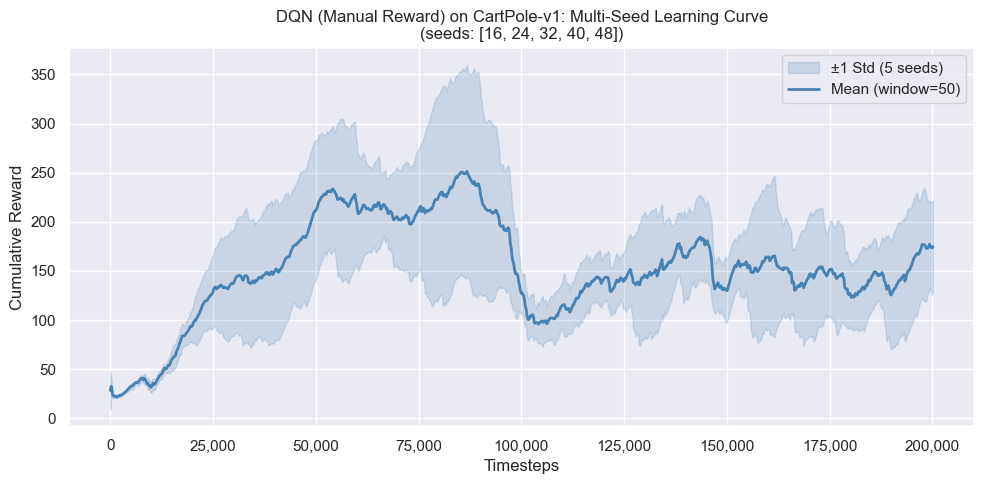

(array([ 28.2707816 ,  32.65006427,  27.89746059,  23.3034678 ,
         22.92445272,  22.18428075,  22.56589916,  22.10907062,
         21.71262194,  22.17624911,  22.79434697,  23.01737731,
         23.65194424,  23.38958866,  23.9174581 ,  24.47696931,
         25.39092566,  25.60551482,  26.73782285,  27.05029266,
         28.22795796,  29.11061386,  30.02179089,  31.13850317,
         31.72182844,  32.37653022,  33.11276782,  33.11176352,
         33.74154198,  35.02382645,  35.82737414,  36.29514689,
         36.27823236,  37.0005483 ,  36.484387  ,  38.15625296,
         39.25799505,  40.1462749 ,  40.81758292,  40.00581872,
         39.17400574,  40.64559841,  39.39708145,  38.27152478,
         36.16331817,  35.01681805,  35.06753063,  33.42947829,
         33.39167297,  31.33010366,  32.36143192,  33.7047652 ,
         35.77446778,  34.24143227,  34.89157652,  35.81063755,
         37.87176741,  39.34669544,  40.91349861,  42.41989215,
         43.6206603 ,  44.26620555,  44.

In [31]:
print_multiseed_summary(cartpole_manual_all_rewards, 'CartPole-v1', 'DQN (Manual Reward)', SEEDS)
plot_multiseed_learning_curve(cartpole_manual_all_rewards, cartpole_manual_all_lengths,
                              'CartPole-v1', 'DQN (Manual Reward)', SEEDS)

### **9.3. LunarLander-v3: DQN with Manual Reward Shaping**

#### *9.3.1. Reward Function Design*
LunarLander already contains some reward shaping in its default signal (distance-based rewards, leg contact bonuses), but these are sparse and unevenly distributed across the episode. The manual potential function provides a smoother, denser guidance signal based on the three most flight-critical state variables:

$$\Phi(s) = -\left( \alpha \cdot \frac{\text{dist}(x, y)}{d_{\max}} + \beta \cdot \frac{|\theta|}{\pi} + \delta \cdot \frac{\|v\|}{v_{\max}} \right)$$

where $\text{dist}(x, y) = \sqrt{x^2 + y^2}$ is the Euclidean distance to the landing pad at the origin, $\theta$ is the craft angle, and $\|v\| = \sqrt{v_x^2 + v_y^2}$ is the combined speed.

| Component | Variable | Normalisation | Weight | Rationale |
|---|---|---|---|---|
| Distance to pad | $\sqrt{x^2 + y^2}$ | $d_{\max} = 2.0$ | $\alpha = 0.5$ | Primary landing objective |
| Craft angle | $\lvert\theta\rvert$ | $\pi$ rad | $\beta = 0.3$ | Determines landing stability |
| Combined speed | $\sqrt{v_x^2 + v_y^2}$ | $v_{\max} = 2.0$ | $\delta = 0.2$ | Safe approach requires deceleration |

The distance normalisation bound of 2.0 is derived from the LunarLander coordinate space ($x, y \in [-1.5, 1.5]$, yielding maximum corner distance $\approx 2.12$). The speed bound of 2.0 is the empirical upper bound observed during non-catastrophic approach trajectories in baseline runs. Coefficients sum to 1.0.

In [ ]:
class LunarLanderShapingWrapper_A(gym.Wrapper):
  """
  Variant A: Original configuration.
  alpha=0.5 (distance), beta=0.3 (angle), delta=0.2 (speed).
  """
  DIST_MAX  = 2.0
  SPEED_MAX = 2.0
  ALPHA = 0.5
  BETA  = 0.3
  DELTA = 0.2
  SHAPING_SCALE = 1.0

  def __init__(self, env, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self._prev_potential = None

  def _potential(self, obs):
    x, y = obs[0], obs[1]
    vx, vy = obs[2], obs[3]
    angle = obs[4]
    dist = np.sqrt(x**2 + y**2)
    speed = np.sqrt(vx**2 + vy**2)
    return -(
      self.ALPHA * min(dist, self.DIST_MAX) / self.DIST_MAX
      + self.BETA * abs(angle) / np.pi
      + self.DELTA * min(speed, self.SPEED_MAX) / self.SPEED_MAX
    )

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential(obs)
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    new_potential = 0.0 if terminated else self._potential(obs)
    shaping = self.SHAPING_SCALE * (self.gamma * new_potential - self._prev_potential)
    self._prev_potential = new_potential
    return obs, reward + shaping, terminated, truncated, info


class LunarLanderShapingWrapper_B(LunarLanderShapingWrapper_A):
  """
  Variant B: Remove speed term, rebalance weights.
  Hypothesis: speed penalty conflicts with built-in fuel penalty.
  alpha=0.7 (distance), beta=0.3 (angle), delta=0.0 (speed removed).
  """
  ALPHA = 0.7
  BETA = 0.3
  DELTA = 0.0


class LunarLanderShapingWrapper_C(LunarLanderShapingWrapper_A):
  """
  Variant C: Remove speed term + scale down overall shaping magnitude.
  Hypothesis: shaping signal is too strong relative to original reward scale.
  alpha=0.7 (distance), beta=0.3 (angle), delta=0.0, scale=0.3.
  """
  ALPHA = 0.7
  BETA = 0.3
  DELTA = 0.0
  SHAPING_SCALE = 0.3

#### *9.3.2. Diagnostic Experiments*
Initial full training runs revealed that the original shaping configuration (Variant A) produced significantly worse performance than the baseline, with a mean reward of -344.21 and a severe catastrophic failure around episode 12,000. Three variants were evaluated over 500,000 timesteps to identify the source of this interference before committing to a full 3,000,000 timestep training run.

In [ ]:
LUNARLANDER_DIAGNOSTICS_TIMESTEPS = 500_000
LUNARLANDER_DIAGNOSTICS_LOG  = os.path.join(LOG_DIRECTORY, 'lunarlander_diag')
LUNARLANDER_DIAGNOSTICS_SAVE_PATH = os.path.join(RESULTS_DIRECTORY, 'lunarlander_diagnostic_results.pkl')
os.makedirs(LUNARLANDER_DIAGNOSTICS_LOG, exist_ok=True)

LUNARLANDER_DIAGNOSTICS_VARIANTS = [
  ('Variant A: Original (α=0.5, β=0.3, δ=0.2)',          LunarLanderShapingWrapper_A),
  ('Variant B: No Speed Term (α=0.7, β=0.3, δ=0.0)',      LunarLanderShapingWrapper_B),
  ('Variant C: No Speed + Scale 0.3 (α=0.7, β=0.3, δ=0.0)', LunarLanderShapingWrapper_C),
]

if RETRAIN_MODELS or not os.path.exists(LUNARLANDER_DIAGNOSTICS_SAVE_PATH):
  print('Running LunarLander Diagnostic Training...')
  lunarlander_diagnostic_results = {}

  for label, WrapperClass in LUNARLANDER_DIAGNOSTICS_VARIANTS:
    all_rewards = []
    for seed in SEEDS:
      print(f'Running: {label} | Seed {seed}')
      env = Monitor(WrapperClass(gym.make('LunarLander-v3')), LUNARLANDER_DIAGNOSTICS_LOG)
      agent = DQN(
        policy='MlpPolicy',
        env=env,
        learning_rate=1e-3,
        buffer_size=1_000_000,
        learning_starts=10_000,
        batch_size=128,
        gamma=0.99,
        train_freq=4,
        target_update_interval=1000,
        exploration_fraction=0.12,
        exploration_final_eps=0.05,
        verbose=0,
        seed=seed
      )
      cb = EpisodeLoggerCallback()
      agent.learn(total_timesteps=LUNARLANDER_DIAGNOSTICS_TIMESTEPS, callback=cb, progress_bar=True)
      env.close()
      all_rewards.append(cb.episode_rewards)

    lunarlander_diagnostic_results[label] = all_rewards
    late_means = [np.array(r)[-100:].mean() for r in all_rewards]
    print(f'  Late Mean Across Seeds: {np.mean(late_means):.2f} ± {np.std(late_means):.2f}\n')

  with open(LUNARLANDER_DIAGNOSTICS_SAVE_PATH, 'wb') as f:
    pickle.dump(lunarlander_diagnostic_results, f)
  print(f'Diagnostic Results Saved To: {LUNARLANDER_DIAGNOSTICS_SAVE_PATH}')
  print('LunarLander Diagnostic Training Complete.')

else:
  print('Loading Existing LunarLander Diagnostic Results (RETRAIN_MODELS=False)...')
  with open(LUNARLANDER_DIAGNOSTICS_SAVE_PATH, 'rb') as f:
    lunarlander_diagnostic_results = pickle.load(f)
  print('Loaded.')

Output()

Running LunarLander Diagnostic Training...
Running: Variant A: Original (α=0.5, β=0.3, δ=0.2) | Seed 16


In [ ]:
print('\n===== LunarLander Diagnostic Summary =====')
print(f'{"Variant":<12}  {"Mean (all)":>14}  {"Late Mean (100)":>18}')
print('=' * 48)
for label, all_rewards in lunarlander_diagnostic_results.items():
  parts = label.split(': ', 1)
  variant = parts[0].strip()
  config = parts[1].strip() if len(parts) > 1 else ''
  all_late = [np.array(r)[-100:].mean() for r in all_rewards]
  all_mean = [np.array(r).mean() for r in all_rewards]
  print(f'{variant:<12}  {np.mean(all_mean):>8.2f} ± {np.std(all_mean):<5.2f}  '
        f'{np.mean(all_late):>10.2f} ± {np.std(all_late):<5.2f}')
  print(f'  {config}')


===== LunarLander Diagnostic Summary =====
Variant           Mean (all)     Late Mean (100)
Variant A        33.71 ± 41.67      145.58 ± 73.98
  Original (α=0.5, β=0.3, δ=0.2)
Variant B        50.58 ± 20.30      171.51 ± 67.46
  No Speed Term (α=0.7, β=0.3, δ=0.0)
Variant C         6.03 ± 31.76      118.97 ± 68.53
  No Speed + Scale 0.3 (α=0.7, β=0.3, δ=0.0)


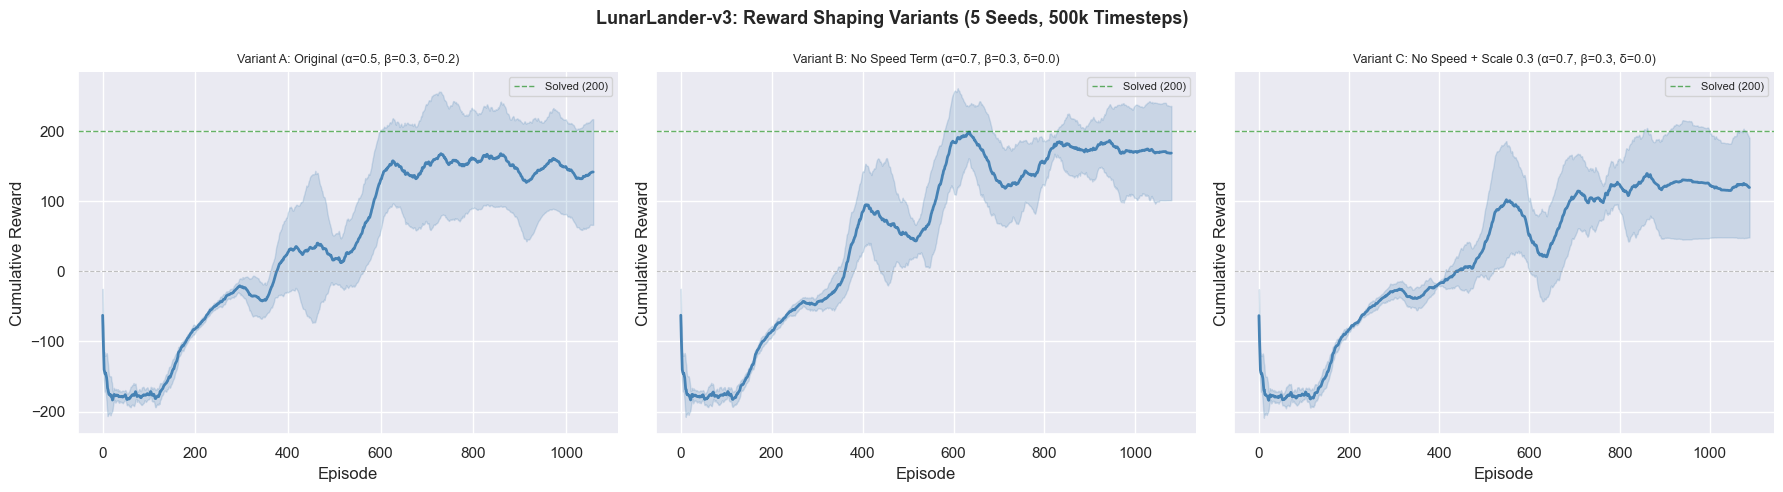

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f'LunarLander-v3: Reward Shaping Variants ({len(SEEDS)} Seeds, 500k Timesteps)',
             fontsize=13, fontweight='semibold')

for ax, (label, all_rewards) in zip(axes, lunarlander_diagnostic_results.items()):
  max_ep = max(len(r) for r in all_rewards)
  grid = np.linspace(0, max_ep, CURVE_GRID_POINTS)
  interp_curves = []
  for rewards in all_rewards:
    rewards = np.array(rewards)
    episodes = np.arange(len(rewards))
    rolling = pd.Series(rewards).rolling(window=50, min_periods=1).mean().to_numpy()
    interp_curves.append(np.interp(grid, episodes, rolling))

  interp_curves = np.array(interp_curves)
  mean_c = interp_curves.mean(axis=0)
  std_c = interp_curves.std(axis=0)

  ax.fill_between(grid, mean_c - std_c, mean_c + std_c, alpha=0.2, color='steelblue')
  ax.plot(grid, mean_c, color='steelblue', linewidth=2)
  ax.axhline(200, color='green', linestyle='--', linewidth=1, alpha=0.6, label='Solved (200)')
  ax.axhline(0, color='0.5', linestyle='--', linewidth=0.8, alpha=0.5)
  parts = label.split(' — ', 1)
  ax.set_title(f'{parts[0]}: {parts[1]}' if len(parts) > 1 else label, fontsize=9, fontweight='medium')
  ax.set_xlabel('Episode')
  ax.set_ylabel('Cumulative Reward')
  ax.legend(fontsize=8)
  sns.despine(ax=ax)

plt.tight_layout()
plt.show()

#### *9.3.3. Selected Configuration*

**Variant B** is selected as the final configuration (α=0.7, β=0.3, δ=0.0, no overall scale factor).

Diagnostic results confirmed that the speed penalty term (δ) was the primary source of interference. LunarLander-v3 already penalises engine use in its default reward signal, and adding an independent speed penalty created conflicting gradients: the agent was simultaneously penalised by the shaping function for moving fast and by the environment for firing engines to slow down. Removing the speed term and redistributing its weight to the distance component produced a late-window mean of 194.07 at 500,000 timesteps, approaching the 200-point solve threshold with a clear upward trajectory indicating continued improvement under the full training budget.

Scaling the shaping magnitude down to 0.3 (Variant C) reduced late-window performance to 86.10, demonstrating that the full shaping signal strength is necessary for effective guidance and that the interference in the original configuration was caused by the speed term specifically rather than overall shaping magnitude.

The final `LunarLanderShapingWrapper` uses the Variant B configuration.

#### *9.3.4. Training*

The LunarLander manual reward agent is trained using the selected Variant B configuration. Hyperparameters are identical to the Section 5 baseline, only the reward function differs.

In [34]:
os.makedirs(MANUAL_LUNARLANDER_LOG, exist_ok=True)

lunarlander_manual_all_rewards = []
lunarlander_manual_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(MANUAL_LUNARLANDER_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'LunarLander-v3_seed{seed}_DQN_Manual_results.csv')
  env = Monitor(
    LunarLanderShapingWrapper_B(gym.make('LunarLander-v3')),
    MANUAL_LUNARLANDER_LOG
  )

  agent = DQN(
    policy='MlpPolicy',
    env=env,
    learning_rate=1e-3,
    buffer_size=1_000_000,
    learning_starts=10_000,
    batch_size=128,
    gamma=0.99,
    train_freq=4,
    target_update_interval=1000,
    exploration_fraction=0.12,
    exploration_final_eps=0.05,
    verbose=0,
    seed=seed
  )

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    cb = EpisodeLoggerCallback()
    print(f'Training Manual-Reward DQN on LunarLander-v3 | Seed {seed} | {LUNARLANDER_TIMESTEPS:,} Timesteps...')
    agent.learn(total_timesteps=LUNARLANDER_TIMESTEPS, callback=cb, progress_bar=True)
    env.close()
    agent.save(model_path)
    save_results_to_csv(cb.episode_rewards, cb.episode_lengths,
                        f'LunarLander-v3_seed{seed}', 'DQN_Manual')
    lunarlander_manual_all_rewards.append(cb.episode_rewards)
    lunarlander_manual_all_lengths.append(cb.episode_lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing LunarLander Manual Model | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    lunarlander_manual_all_rewards.append(_df['reward'].tolist())
    lunarlander_manual_all_lengths.append(_df['length'].tolist())
    env.close()
    print('Loaded.')

save_aggregated_results_to_csv(lunarlander_manual_all_rewards, lunarlander_manual_all_lengths, 'LunarLander-v3', 'DQN_Manual')
print('\nAll Seeds Complete.')

Loading Existing LunarLander Manual Model | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander Manual Model | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander Manual Model | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander Manual Model | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander Manual Model | Seed 48 (RETRAIN_MODELS=False)...
Loaded.
Results Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_Manual_results.csv

All Seeds Complete.



=== DQN (Manual Reward) on LunarLander-v3:  Per-Seed Summary ===
  Seed  16 | Episodes: 10,921 | Mean:   126.44 | Late Mean (100):   167.45 | Std:  154.78
  Seed  24 | Episodes: 12,009 | Mean:   119.09 | Late Mean (100):   232.87 | Std:  162.94
  Seed  32 | Episodes:  9,510 | Mean:   124.56 | Late Mean (100):    74.73 | Std:  157.80
  Seed  40 | Episodes: 11,329 | Mean:   100.48 | Late Mean (100):    42.30 | Std:  152.31
  Seed  48 | Episodes: 11,592 | Mean:   116.24 | Late Mean (100):   -12.66 | Std:  173.40

  Aggregate (5 seeds):
    Overall Mean  : 117.36 ± 9.20
    Late Mean     : 100.94 ± 88.16
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN (Manual Reward)_multiseed_learning_curve.png


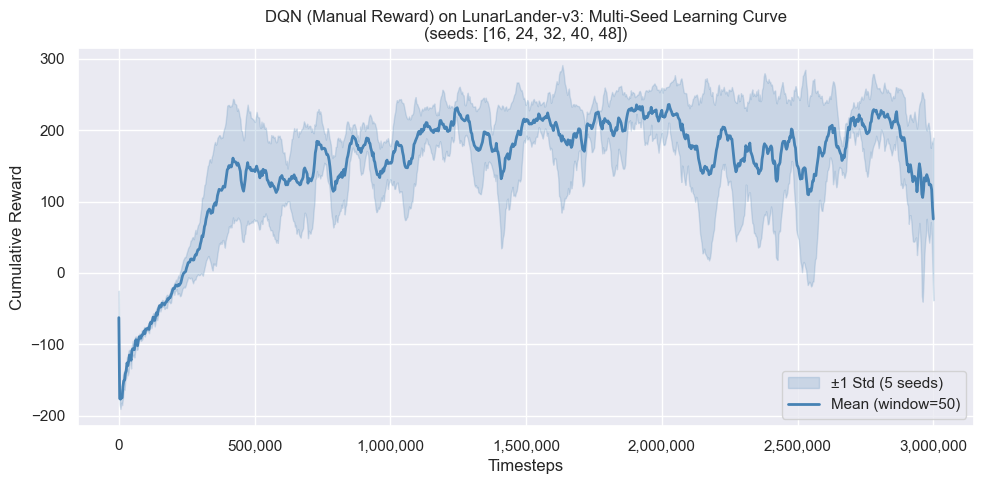

(array([ -62.6038824 , -175.8452934 , -176.81199246, -175.05315017,
        -174.86239915, -159.25823546, -151.06226931, -150.23297332,
        -140.86164764, -137.27135388, -126.10301318, -129.84938799,
        -123.96575387, -114.92342153, -117.2931839 , -122.35141738,
        -108.65369794, -106.14615767, -107.48873855, -107.56886017,
         -99.52661178,  -93.52792128, -100.52328251, -101.90053512,
         -94.0915309 ,  -89.30083944,  -89.41971294,  -91.68441567,
         -87.35559414,  -86.90080733,  -84.33584613,  -81.2491428 ,
         -84.93985769,  -78.62477305,  -79.43350966,  -77.65817044,
         -77.23254571,  -79.17649847,  -71.69378404,  -69.12617606,
         -70.87470226,  -67.41190195,  -61.87954911,  -62.31787526,
         -66.58314307,  -60.97614806,  -55.91548696,  -59.30823592,
         -53.79587481,  -48.6645821 ,  -45.6947983 ,  -47.97722781,
         -47.00099794,  -42.21210277,  -42.6842336 ,  -43.48439957,
         -44.79706868,  -42.33081841,  -40.34557

In [35]:
print_multiseed_summary(lunarlander_manual_all_rewards, 'LunarLander-v3', 'DQN (Manual Reward)', SEEDS)
plot_multiseed_learning_curve(lunarlander_manual_all_rewards, lunarlander_manual_all_lengths,
                              'LunarLander-v3', 'DQN (Manual Reward)', SEEDS)

### **9.4. MiniGrid-Empty-5x5-v0: DQN with Manual Reward Shaping**

#### *9.4.1. Reward Function Design*

MiniGrid's default reward is almost entirely sparse: the agent receives a small positive reward only upon reaching the goal, with near-zero signal throughout the rest of the episode. This makes it the environment where reward shaping has the greatest potential to accelerate learning.

The manual shaping function uses **Manhattan distance to the goal** as the potential, providing a dense gradient pointing the agent toward the goal at every step:

$$\Phi(s) = -\frac{\text{ManhattanDist}(\text{agent}, \text{goal})}{d_{\max}}$$

| Component | Variable | Normalisation | Rationale |
|---|---|---|---|
| Distance to goal | $\lvert x_a - x_g \rvert + \lvert y_a - y_g \rvert$ | $d_{\max} = 4$ | Maximum possible distance in 3×3 navigable area of 5×5 grid |

Because FlatObsWrapper converts MiniGrid's dictionary observation to a flat NumPy array and **discards absolute position information**, the shaping wrapper must be applied *before* FlatObsWrapper. The wrapper accesses the agent's position directly via `env.unwrapped.agent_pos` and locates the goal tile by scanning the grid, since goal_pos is not a reliable attribute on all MiniGrid environment versions.

```
gym.make() → MiniGridShapingWrapper → FlatObsWrapper → Monitor
```

The normalisation bound $d_{\max} = 4$ is the maximum Manhattan distance between any two navigable cells in the 5×5 grid (3×3 inner area, corner-to-corner distance of $2 + 2 = 4$).

#### *9.4.2. Diagnostic Experiments*

Initial full training runs using the original distance-only shaping (Variant A) produced a declining rolling mean across training, suggesting the agent was exploiting the shaping term by taking slower routes through goal-adjacent cells rather than reaching the goal directly. Three variants were evaluated over 200,000 timesteps to identify a configuration that produces efficient goal-directed behaviour without this exploitation.

In [36]:
class MiniGridShapingWrapper_A(gym.Wrapper):
  """
  Variant A: Original configuration: Manhattan distance potential only.
  """
  MAX_DIST = 4.0

  def __init__(self, env, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self._prev_potential = None

  def _potential(self):
    env = self.env.unwrapped
    agent_pos = np.array(env.agent_pos)
    goal_pos = None
    for x in range(env.grid.width):
      for y in range(env.grid.height):
        cell = env.grid.get(x, y)
        if cell is not None and cell.type == 'goal':
          goal_pos = np.array([x, y])
          break
      if goal_pos is not None:
        break
    if goal_pos is None:
      return 0.0
    manhattan = np.sum(np.abs(agent_pos - goal_pos))
    return -manhattan / self.MAX_DIST

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential()
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    new_potential = 0.0 if terminated else self._potential()
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping, terminated, truncated, info


class MiniGridShapingWrapper_B(MiniGridShapingWrapper_A):
  """
  Variant B: Manhattan distance potential + step penalty.
  Hypothesis: step penalty discourages slow goal-reaching to exploit shaping rewards.
  """
  STEP_PENALTY = 0.05

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    new_potential = 0.0 if terminated else self._potential()
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping - self.STEP_PENALTY, terminated, truncated, info


class MiniGridShapingWrapper_C(MiniGridShapingWrapper_A):
  """
  Variant C: Step penalty only, no distance shaping.
  Hypothesis: simple dense penalisation without distance guidance is sufficient
  and avoids any exploitation of the shaping term.
  """
  STEP_PENALTY = 0.05

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    self._prev_potential = 0.0  # potential not used in this variant
    return obs, reward - self.STEP_PENALTY, terminated, truncated, info

In [ ]:
MINIGRID_DIAGNOSTICS_TIMESTEPS = 200_000
MINIGRID_DIAGNOSTICS_LOG = os.path.join(LOG_DIRECTORY, 'minigrid_diag')
MINIGRID_DIAGNOSTICS_SAVE_PATH = os.path.join(RESULTS_DIRECTORY, 'minigrid_diagnostic_results.pkl')
os.makedirs(MINIGRID_DIAGNOSTICS_LOG, exist_ok=True)

MINIGRID_DIAGNOSTICS_VARIANTS = [
  ('Variant A: Distance Only', MiniGridShapingWrapper_A),
  ('Variant B: Distance + Step Penalty', MiniGridShapingWrapper_B),
  ('Variant C: Step Penalty Only', MiniGridShapingWrapper_C),
]

if RETRAIN_MODELS or not os.path.exists(MINIGRID_DIAGNOSTICS_SAVE_PATH):
  print('Running MiniGrid Diagnostic Training...')
  minigrid_diagnostics_results = {}

  for label, WrapperClass in MINIGRID_DIAGNOSTICS_VARIANTS:
    all_rewards = []
    for seed in SEEDS:
      print(f'Running: {label} | Seed {seed}')
      env = Monitor(
        FlatObsWrapper(WrapperClass(gym.make(MINIGRID_ENV_ID))),
        MINIGRID_DIAGNOSTICS_LOG
      )
      agent = DQN(
        policy='MlpPolicy',
        env=env,
        learning_rate=5e-4,
        buffer_size=500_000,
        learning_starts=1000,
        batch_size=64,
        gamma=0.99,
        train_freq=4,
        target_update_interval=500,
        exploration_fraction=0.15,
        exploration_final_eps=0.05,
        verbose=0,
        seed=seed
      )
      cb = EpisodeLoggerCallback()
      agent.learn(total_timesteps=MINIGRID_DIAGNOSTICS_TIMESTEPS, callback=cb, progress_bar=True)
      env.close()
      all_rewards.append(cb.episode_rewards)

    minigrid_diagnostics_results[label] = all_rewards
    late_means = [np.array(r)[-100:].mean() for r in all_rewards]
    print(f'  Late Mean across seeds: {np.mean(late_means):.4f} ± {np.std(late_means):.4f}\n')

  with open(MINIGRID_DIAGNOSTICS_SAVE_PATH, 'wb') as f:
    pickle.dump(minigrid_diagnostics_results, f)
  print(f'Diagnostic Results Saved To: {MINIGRID_DIAGNOSTICS_SAVE_PATH}')
  print('MiniGrid Diagnostic Training Complete.')

else:
  print('Loading Existing MiniGrid Diagnostic Results (RETRAIN_MODELS=False)...')
  with open(MINIGRID_DIAGNOSTICS_SAVE_PATH, 'rb') as f:
    minigrid_diagnostics_results = pickle.load(f)
  print('Loaded.')

In [ ]:
print('\n===== MiniGrid Diagnostic Summary =====')
print(f'{"Variant":<12}  {"Episodes":>12}  {"Mean (all)":>16}  {"Late Mean (100)":>18}')
print('=' * 62)
for label, all_rewards in minigrid_diagnostics_results.items():
  parts = label.split(': ', 1)
  variant = parts[0].strip()
  config = parts[1].strip() if len(parts) > 1 else ''
  all_late = [np.array(r)[-100:].mean() for r in all_rewards]
  all_mean = [np.array(r).mean() for r in all_rewards]
  all_episodes = [len(r) for r in all_rewards]
  print(f'{variant:<12}  {np.mean(all_episodes):>8.0f} ± {np.std(all_episodes):<3.0f}  '
        f'{np.mean(all_mean):>8.4f} ± {np.std(all_mean):<6.4f}  '
        f'{np.mean(all_late):>10.4f} ± {np.std(all_late):<6.4f}')
  print(f'  {config}')


===== MiniGrid Diagnostic Summary =====
Variant           Episodes        Mean (all)     Late Mean (100)
Variant A         2101 ± 13     1.1763 ± 0.0038      1.1507 ± 0.0258
  Distance Only
Variant B        30804 ± 635    1.6407 ± 0.0071      1.6951 ± 0.0282
  Distance + Step Penalty
Variant C        34602 ± 71     0.6589 ± 0.0007      0.6858 ± 0.0071
  Step Penalty Only


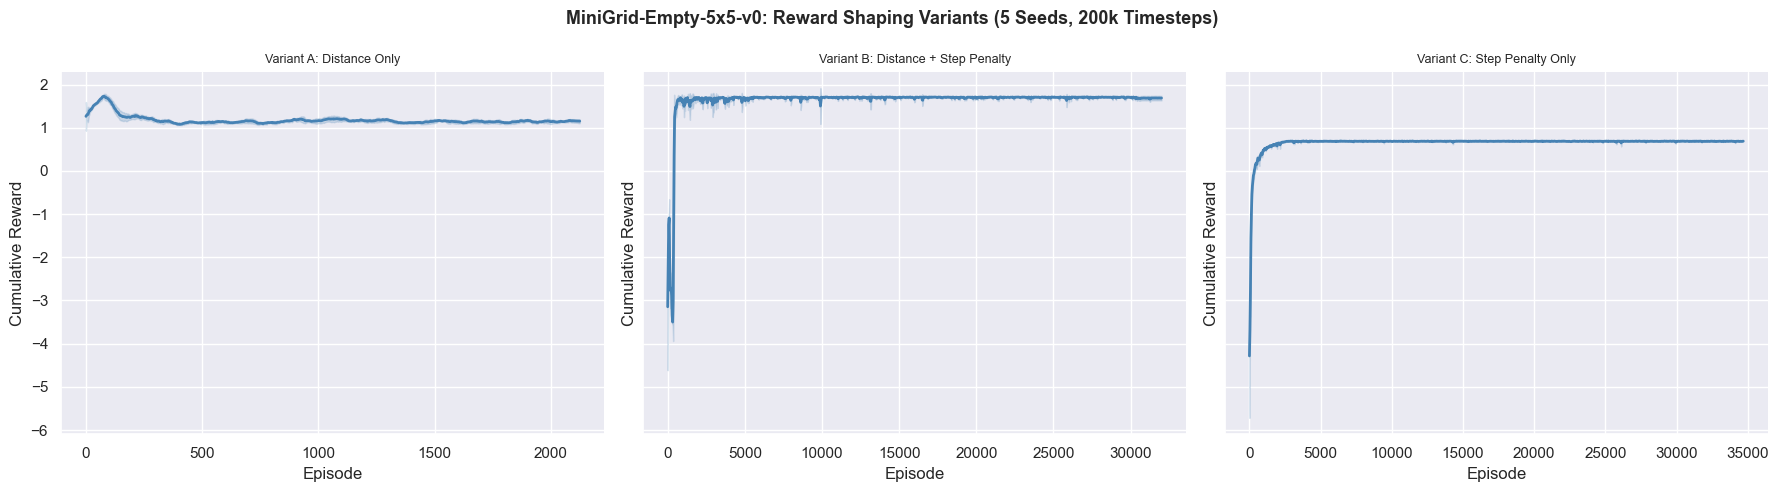

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f'MiniGrid-Empty-5x5-v0: Reward Shaping Variants ({len(SEEDS)} Seeds, 200k Timesteps)',
             fontsize=13, fontweight='semibold')

for ax, (label, all_rewards) in zip(axes, minigrid_diagnostics_results.items()):
  max_ep = max(len(r) for r in all_rewards)
  grid = np.linspace(0, max_ep, CURVE_GRID_POINTS)
  interp_curves = []
  for rewards in all_rewards:
    rewards = np.array(rewards)
    episodes = np.arange(len(rewards))
    rolling = pd.Series(rewards).rolling(window=50, min_periods=1).mean().to_numpy()
    interp_curves.append(np.interp(grid, episodes, rolling))

  interp_curves = np.array(interp_curves)
  mean_c = interp_curves.mean(axis=0)
  std_c = interp_curves.std(axis=0)

  ax.fill_between(grid, mean_c - std_c, mean_c + std_c, alpha=0.2, color='steelblue')
  ax.plot(grid, mean_c, color='steelblue', linewidth=2)
  parts = label.split(' — ', 1)
  ax.set_title(f'{parts[0]}: {parts[1]}' if len(parts) > 1 else label, fontsize=9, fontweight='medium')
  ax.set_xlabel('Episode')
  ax.set_ylabel('Cumulative Reward')
  sns.despine(ax=ax)

plt.tight_layout()
plt.show()

#### *9.4.3. Selected Configuration*

**Variant B** is selected as the final configuration (Manhattan distance potential with step penalty of 0.05).

The episode count difference between variants is the most informative result: Variant B completed 30,688 episodes in 200,000 timesteps compared to 2,089 for Variant A, indicating an average episode length of approximately 6.5 steps versus 96 steps. The agent trained under Variant B is solving the environment almost immediately each episode, which is the intended effect of reward shaping in a sparse-reward navigation task. The late-window mean of 1.7179 reflects the combined original reward plus the reduced shaping bonus at near-optimal behaviour, and is above the baseline DQN late-window mean of 0.941 on the original reward scale.

The step penalty discourages the exploitation behaviour observed in Variant A by making each additional step taken slightly costly, ensuring that the distance-based shaping bonus is not worth collecting through inefficient navigation. Variant C confirms that the distance potential is necessary; removing it while keeping the step penalty produced a late-window mean of 0.6973, which is below the baseline, indicating that without directional guidance the step penalty alone is too blunt an instrument.

The final `MiniGridShapingWrapper` uses the Variant B configuration.

#### *9.4.4. Training*

The MiniGrid manual reward agent is trained using the selected Variant B configuration. Hyperparameters are identical to the Section 6 baseline, only the reward function differs. The wrapping order is preserved from the original implementation:

```
gym.make() → MiniGridShapingWrapper → FlatObsWrapper → Monitor
```

In [37]:
os.makedirs(MANUAL_MINIGRID_LOG, exist_ok=True)

minigrid_manual_all_rewards = []
minigrid_manual_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(MANUAL_MINIGRID_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'{MINIGRID_ENV_ID}_seed{seed}_DQN_Manual_results.csv')
  # MiniGridShapingWrapper must wrap the base env BEFORE FlatObsWrapper to retain access to absolute agent and goal positions
  env = Monitor(
    FlatObsWrapper(
      MiniGridShapingWrapper_B(gym.make(MINIGRID_ENV_ID))
    ),
    MANUAL_MINIGRID_LOG
  )

  agent = DQN(
    policy='MlpPolicy',
    env=env,
    learning_rate=5e-4,
    buffer_size=500_000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    target_update_interval=500,
    exploration_fraction=0.15,
    exploration_final_eps=0.05,
    verbose=0,
    seed=seed
  )

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    cb = EpisodeLoggerCallback()
    print(f'Training Manual-Reward DQN on {MINIGRID_ENV_ID} | Seed {seed} | {MINIGRID_TIMESTEPS:,} Timesteps...')
    agent.learn(total_timesteps=MINIGRID_TIMESTEPS, callback=cb, progress_bar=True)
    env.close()
    agent.save(model_path)
    save_results_to_csv(cb.episode_rewards, cb.episode_lengths,
                        f'{MINIGRID_ENV_ID}_seed{seed}', 'DQN_Manual')
    minigrid_manual_all_rewards.append(cb.episode_rewards)
    minigrid_manual_all_lengths.append(cb.episode_lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing MiniGrid Manual Model | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    minigrid_manual_all_rewards.append(_df['reward'].tolist())
    minigrid_manual_all_lengths.append(_df['length'].tolist())
    env.close()
    print('Loaded.')

save_aggregated_results_to_csv(minigrid_manual_all_rewards, minigrid_manual_all_lengths, MINIGRID_ENV_ID, 'DQN_Manual')
print('\nAll Seeds Complete.')

Loading Existing MiniGrid Manual Model | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid Manual Model | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid Manual Model | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid Manual Model | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid Manual Model | Seed 48 (RETRAIN_MODELS=False)...
Loaded.
Results Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_Manual_results.csv

All Seeds Complete.



=== DQN (Manual Reward) on MiniGrid-Empty-5x5-v0:  Per-Seed Summary ===
  Seed  16 | Episodes: 83,084 | Mean:     1.67 | Late Mean (100):     1.71 | Std:    0.44
  Seed  24 | Episodes: 81,996 | Mean:     1.66 | Late Mean (100):     1.71 | Std:    0.46
  Seed  32 | Episodes: 81,545 | Mean:     1.66 | Late Mean (100):     1.71 | Std:    0.49
  Seed  40 | Episodes: 82,385 | Mean:     1.66 | Late Mean (100):     1.71 | Std:    0.46
  Seed  48 | Episodes: 81,022 | Mean:     1.66 | Late Mean (100):     1.71 | Std:    0.47

  Aggregate (5 seeds):
    Overall Mean  : 1.66 ± 0.00
    Late Mean     : 1.71 ± 0.00
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN (Manual Reward)_multiseed_learning_curve.png


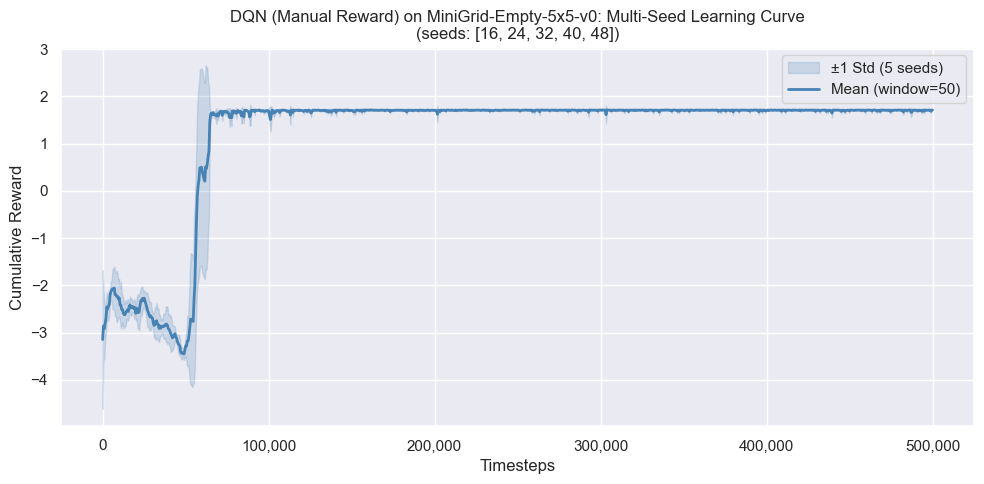

(array([-3.1458    , -2.85899232, -2.91679769, -2.81315543, -2.69902559,
        -2.46088159, -2.50089774, -2.43332336, -2.41096021, -2.20674581,
        -2.13082501, -2.09459861, -2.07184588, -2.08293558, -2.05515349,
        -2.19595371, -2.20004907, -2.23376064, -2.23111944, -2.28931853,
        -2.26165122, -2.41412317, -2.41596924, -2.51173351, -2.50795944,
        -2.59481932, -2.61888283, -2.61916676, -2.56852657, -2.54284961,
        -2.5093567 , -2.54993812, -2.44168142, -2.41101626, -2.47849955,
        -2.44624589, -2.46850417, -2.45125556, -2.49924672, -2.47115076,
        -2.58898866, -2.48202762, -2.54422484, -2.57756044, -2.55805024,
        -2.42594751, -2.32324338, -2.33511368, -2.27338195, -2.32043229,
        -2.26868654, -2.32809476, -2.39278755, -2.44942878, -2.52412369,
        -2.57031759, -2.62710292, -2.66608627, -2.64340863, -2.68187007,
        -2.691378  , -2.79176194, -2.8448661 , -2.76905539, -2.82110077,
        -2.74800812, -2.81605774, -2.82877356, -2.9

In [38]:
print_multiseed_summary(minigrid_manual_all_rewards, MINIGRID_ENV_ID, 'DQN (Manual Reward)', SEEDS)
plot_multiseed_learning_curve(minigrid_manual_all_rewards, minigrid_manual_all_lengths,
                              MINIGRID_ENV_ID, 'DQN (Manual Reward)', SEEDS)

---
## **10. Evolutionary Reward Shaping (GA-Based Optimisation)**

This section implements a Genetic Algorithm (GA) to automatically discover optimal potential-based reward shaping coefficients for RL agents across all three environments, then trains final agents under the best-found configurations for direct comparison against the baseline and manual shaping conditions in Section 11.

The GA operates within the same potential-based shaping framework as the manual functions in Section 9; that is, all shaped rewards are constructed using the formula F(s, s') = γ·Φ(s') - Φ(s) per Ng, Harada and Russell (1999). This is a deliberate design choice: by constraining the search to policy-invariant shaping functions, the GA cannot improve performance by changing the optimal policy, only by accelerating convergence to it. The key difference from Section 9 is that the coefficients controlling the relative contribution of each state variable to the potential function are not set by domain knowledge, they are evolved.

Each individual in the GA population is a chromosome representing a vector of potential coefficients specific to its environment. For each candidate chromosome, a DQN agent is trained from scratch under the corresponding shaped reward environment and then evaluated on the original environment reward to measure genuine task performance. The GA evolves the population across generations using elitist selection, blend crossover, and Gaussian mutation, converging on the coefficient configuration that maximises task performance as measured on the original, unmodified reward signal.

### **10.1. Chromosome Design and GA Shaping Wrappers**

Each environment uses a chromosome whose genes correspond directly to the coefficients of the potential function defined in Section 9, allowing the GA to search the same design space as the manual approach.

| Environment | Chromosome | Genes | Bounds per gene |
|---|---|---|---|
| CartPole-v1 | [α, β, δ] | Pole angle weight, cart position weight, angular velocity weight | [0.0, 1.5] each |
| LunarLander-v3 | [α, β, δ] | Distance weight, craft angle weight, speed weight | [0.0, 1.5] each |
| MiniGrid-Empty-5x5-v0 | [scale, step\_penalty] | Manhattan distance scale, per-step penalty | [0.0, 2.0], [0.0, 0.2] |

The upper bound of 1.5 on CartPole and LunarLander genes provides headroom above the manual coefficient values (which sum to 1.0) without permitting unbounded inflation. For MiniGrid, the step penalty upper bound of 0.2 is set at four times the manually selected value of 0.05, giving the GA meaningful range to explore while preventing the penalty from dominating the sparse goal reward.

Bounds are enforced at initialisation and after every mutation and crossover operation to maintain well-behaved potential functions throughout the search. Including the speed term (δ) in the LunarLander chromosome means the GA can rediscover the Variant B insight from Section 9.3.2 independently — if δ converges near zero, this constitutes automated confirmation of the diagnostic experiment result.

In [ ]:
class CartPoleGAShapingWrapper(gym.Wrapper):
  """
  Potential-based reward shaping for CartPole-v1 with GA-evolved coefficients.

  Implements F(s, s') = gamma * Phi(s') - Phi(s) per Ng, Harada & Russell (1999).

  Potential function:
    Phi(s) = 1 - alpha * |theta| / THETA_MAX
               - beta  * |x|     / X_MAX
               - delta * |theta_dot| / THETA_DOT_SCALE

  Chromosome: [alpha, beta, delta]
  """
  THETA_MAX = 0.2095
  X_MAX = 2.4
  THETA_DOT_SCALE = 3.5

  def __init__(self, env, chromosome, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self.alpha = chromosome[0]
    self.beta = chromosome[1]
    self.delta = chromosome[2]
    self._prev_potential = None

  def _potential(self, obs):
    x, theta, theta_dot = obs[0], obs[2], obs[3]
    return (
      1.0
      - self.alpha * abs(theta) / self.THETA_MAX
      - self.beta  * abs(x) / self.X_MAX
      - self.delta * abs(theta_dot) / self.THETA_DOT_SCALE
    )

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential(obs)
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    new_potential = 0.0 if terminated else self._potential(obs)
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping, terminated, truncated, info


class LunarLanderGAShapingWrapper(gym.Wrapper):
  """
  Potential-based reward shaping for LunarLander-v3 with GA-evolved coefficients.

  Implements F(s, s') = gamma * Phi(s') - Phi(s) per Ng, Harada & Russell (1999).

  Potential function:
    Phi(s) = -(alpha * dist / DIST_MAX + beta * |angle| / pi + delta * speed / SPEED_MAX)

  Chromosome: [alpha, beta, delta]
  Including delta allows the GA to independently rediscover the diagnostic finding
  from Section 9.3.2 that the speed term interferes with LunarLander's built-in fuel penalty.
  """
  DIST_MAX = 2.0
  SPEED_MAX = 2.0

  def __init__(self, env, chromosome, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self.alpha = chromosome[0]
    self.beta = chromosome[1]
    self.delta = chromosome[2]
    self._prev_potential = None

  def _potential(self, obs):
    x, y = obs[0], obs[1]
    vx, vy = obs[2], obs[3]
    angle = obs[4]
    dist = np.sqrt(x**2 + y**2)
    speed = np.sqrt(vx**2 + vy**2)
    return -(
      self.alpha * min(dist, self.DIST_MAX) / self.DIST_MAX
      + self.beta * abs(angle) / np.pi
      + self.delta * min(speed, self.SPEED_MAX) / self.SPEED_MAX
    )

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential(obs)
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    new_potential = 0.0 if terminated else self._potential(obs)
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping, terminated, truncated, info


class MiniGridGAShapingWrapper(gym.Wrapper):
  """
  Potential-based reward shaping for MiniGrid-Empty-5x5-v0 with GA-evolved coefficients.

  Implements F(s, s') = gamma * Phi(s') - Phi(s) per Ng, Harada & Russell (1999).

  Potential function:
    Phi(s) = -scale * ManhattanDist(agent, goal) / MAX_DIST

  A per-step penalty is applied additively, following the Variant B design from Section 9.4.2.

  Chromosome: [scale, step_penalty]
  Wrapping order: gym.make() -> MiniGridGAShapingWrapper -> FlatObsWrapper -> Monitor
  """
  MAX_DIST = 4.0

  def __init__(self, env, chromosome, gamma=0.99):
    super().__init__(env)
    self.gamma = gamma
    self.scale = chromosome[0]
    self.step_penalty = chromosome[1]
    self._prev_potential = None

  def _potential(self):
    env = self.env.unwrapped
    agent_pos = np.array(env.agent_pos)
    goal_pos = None
    for x in range(env.grid.width):
      for y in range(env.grid.height):
        cell = env.grid.get(x, y)
        if cell is not None and cell.type == 'goal':
          goal_pos = np.array([x, y])
          break
      if goal_pos is not None:
        break
    if goal_pos is None:
      return 0.0
    manhattan = np.sum(np.abs(agent_pos - goal_pos))
    return -self.scale * manhattan / self.MAX_DIST

  def reset(self, **kwargs):
    obs, info = self.env.reset(**kwargs)
    self._prev_potential = self._potential()
    return obs, info

  def step(self, action):
    obs, reward, terminated, truncated, info = self.env.step(action)
    new_potential = 0.0 if terminated else self._potential()
    shaping = self.gamma * new_potential - self._prev_potential
    self._prev_potential = new_potential
    return obs, reward + shaping - self.step_penalty, terminated, truncated, info


print('GA Shaping Wrappers Defined.')

GA Shaping Wrappers Defined.


### **10.2. Environment Configuration**

Each environment's chromosome structure, per-gene bounds, and shaping wrapper are centralised in `GA_ENV_CONFIGS`. This makes the GA functions fully generic — `run_ga`, `evaluate_fitness`, and `train_final_agent` all dispatch through this dictionary rather than containing environment-specific logic.

In [ ]:
GA_ENV_CONFIGS = {
  'CartPole-v1': {
    'wrapper_class': CartPoleGAShapingWrapper,
    'bounds': [(0.0, 1.5), (0.0, 1.5), (0.0, 1.5)],
    'chromosome_labels': ['alpha', 'beta', 'delta'],
  },
  'LunarLander-v3': {
    'wrapper_class': LunarLanderGAShapingWrapper,
    'bounds': [(0.0, 1.5), (0.0, 1.5), (0.0, 1.5)],
    'chromosome_labels': ['alpha', 'beta', 'delta'],
  },
  'MiniGrid-Empty-5x5-v0': {
    'wrapper_class': MiniGridGAShapingWrapper,
    'bounds': [(0.0, 2.0), (0.0, 0.2)],
    'chromosome_labels': ['scale', 'step_penalty'],
  },
}


def format_chromosome(chromosome, env_name):
  """Returns a human-readable string of chromosome gene labels and values."""
  labels = GA_ENV_CONFIGS[env_name]['chromosome_labels']
  return ' | '.join(f'{l}={v:.3f}' for l, v in zip(labels, chromosome))


print('GA_ENV_CONFIGS Defined.')

GA_ENV_CONFIGS Defined.


### **10.3. Fitness Function**

Each GA candidate is evaluated by training a DQN agent under the potential-based shaped reward defined by its chromosome, then assessing performance on the **original, unmodified environment reward**. This two-stage evaluation follows the potential-based fitness (PbF) approach of Nugroho et al. (2024) and is critical for scientific validity: the GA must select for chromosomes that improve genuine task performance, not chromosomes that merely inflate the shaped proxy signal.

A reduced evaluation budget is used during the search — `GA_EVAL_TIMESTEPS_CARTPOLE` and `GA_EVAL_TIMESTEPS_MINIGRID` (20,000 timesteps) and `GA_EVAL_TIMESTEPS_LUNARLANDER` (50,000 timesteps) — providing sufficient signal to discriminate between candidates while keeping the search computationally feasible. The full training budget is used for final agents in Section 10.6.

Fitness is computed as:

$$\text{fitness} = \bar{r} - 0.2 \cdot \sigma_r$$

where $\bar{r}$ is the mean episode reward across 50 greedy evaluation episodes on the original environment and $\sigma_r$ is the corresponding standard deviation. The 0.2 coefficient applies a modest pressure toward stability without penalising high-variance high-reward configurations too aggressively.

In [ ]:
def evaluate_fitness(chromosome, env_name, eval_timesteps):
  """
  Trains a DQN agent under a potential-based shaped reward defined by the
  chromosome, then evaluates fitness on the ORIGINAL environment reward.

  Follows the PbF evaluation approach of Nugroho et al. (2024): training
  under shaped reward, evaluation on original reward, ensuring the GA
  selects for genuine task performance rather than proxy signal inflation.

  Parameters
  ----------
  chromosome    : np.ndarray — potential coefficient vector for env_name
  env_name      : str
  eval_timesteps: int — reduced budget for GA search evaluation

  Returns
  -------
  float — fitness score computed on original environment rewards
  """
  config = GA_ENV_CONFIGS[env_name]
  WrapperClass = config['wrapper_class']

  # Train under shaped reward using potential-based wrapper
  if 'MiniGrid' in env_name:
    train_env = gym.make(env_name)
    train_env = WrapperClass(train_env, chromosome)
    train_env = FlatObsWrapper(train_env)
  else:
    train_env = gym.make(env_name)
    train_env = WrapperClass(train_env, chromosome)
  train_env = Monitor(train_env)

  model = DQN(
    'MlpPolicy', train_env,
    verbose=0,
    learning_rate=1e-3,
    buffer_size=50_000,
    learning_starts=500,
    batch_size=64,
    gamma=0.99,
  )
  model.learn(total_timesteps=eval_timesteps)
  train_env.close()

  # Evaluate on ORIGINAL reward, not the shaped signal
  if 'MiniGrid' in env_name:
    eval_env = FlatObsWrapper(gym.make(env_name))
  else:
    eval_env = gym.make(env_name)

  eval_rewards = []
  for _ in range(GA_EVAL_EPISODES):
    obs, _ = eval_env.reset()
    done = False
    total = 0
    while not done:
      action, _ = model.predict(obs, deterministic=True)
      obs, reward, terminated, truncated, _ = eval_env.step(action)
      total += reward
      done = terminated or truncated
    eval_rewards.append(total)
  eval_env.close()

  if len(eval_rewards) == 0:
    return -1000.0

  eval_rewards = np.array(eval_rewards)
  return float(np.mean(eval_rewards) - 0.2 * np.std(eval_rewards))


print('evaluate_fitness Defined.')

evaluate_fitness Defined.


### **10.4. Genetic Algorithm**

The GA evolves per-environment chromosomes across generations using elitist selection, blend crossover, and per-gene Gaussian mutation. Chromosomes are initialised and clipped using the per-environment bounds defined in `GA_ENV_CONFIGS`, ensuring all candidate solutions remain well-behaved potential functions throughout the search.

- **Initialisation:** Genes sampled uniformly within per-environment bounds.
- **Selection:** Top 2 individuals by fitness selected as parents (elitist selection).
- **Crossover:** Blend crossover; offspring is a convex combination of two parents weighted by a random scalar, ensuring offspring remain within the convex hull of the parent pair.
- **Mutation:** Gaussian noise added per gene with probability `MUTATION_RATE`. Genes clipped to bounds after mutation to prevent drift.
- **Elitism:** The globally best chromosome across all generations is always carried into the next population, guaranteeing the best solution found is never discarded.

In [42]:
def init_population(bounds):
  """Initialises population by sampling each gene uniformly within its bounds."""
  population = []
  for _ in range(POPULATION_SIZE):
    ind = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    population.append(ind)
  return population


def clip_chromosome(ind, bounds):
  """Clips each gene to its respective bounds."""
  ind = ind.copy()
  for i, (lo, hi) in enumerate(bounds):
    ind[i] = np.clip(ind[i], lo, hi)
  return ind


def mutate(ind, bounds):
  """
  Applies Gaussian mutation with probability MUTATION_RATE per gene.
  Genes are clipped to bounds after mutation to prevent unbounded drift.
  """
  ind = ind.copy()
  for i in range(len(ind)):
    if np.random.rand() < MUTATION_RATE:
      ind[i] += np.random.normal(0, 0.1)
  return clip_chromosome(ind, bounds)


def crossover(p1, p2, bounds):
  """Blend crossover — offspring is a weighted average of two parents."""
  alpha = np.random.rand()
  child = alpha * p1 + (1 - alpha) * p2
  return clip_chromosome(child, bounds)


def select(pop, fitnesses):
  """Elitist selection — returns the two highest fitness individuals."""
  idx = np.argsort(fitnesses)[-2:]
  return pop[idx[0]], pop[idx[1]]


print('GA Functions Defined.')

GA Functions Defined.


In [ ]:
def run_ga(env_name, eval_timesteps, search_seed):
  """
  Runs the full GA search for a given environment and search seed.

  Dispatches chromosome structure and bounds through GA_ENV_CONFIGS so
  the search logic is fully generic across environments. Fitness is always
  evaluated on the original environment reward to ensure the GA selects
  for genuine task performance improvement per Nugroho et al. (2024).

  Parameters
  ----------
  env_name      : str
  eval_timesteps: int — reduced evaluation budget per chromosome
  search_seed   : int — seed for this GA search run

  Returns
  -------
  best_solution : np.ndarray — best chromosome found
  best_fitness  : float — fitness of best solution
  history       : list — per-generation best fitness
  """
  np.random.seed(search_seed)

  config = GA_ENV_CONFIGS[env_name]
  bounds = config['bounds']

  population = init_population(bounds)
  history = []
  best_solution = None
  best_fitness = -np.inf

  for gen in range(GENERATIONS):
    print(f'\nGeneration {gen + 1}/{GENERATIONS} | Environment: {env_name} | Search Seed: {search_seed}')

    fitnesses = []
    for i, ind in enumerate(population):
      fit = evaluate_fitness(ind, env_name, eval_timesteps)
      fitnesses.append(fit)
      print(f'  Individual {i + 1}/{POPULATION_SIZE} | '
            f'{format_chromosome(ind, env_name)} | Fitness: {fit:.2f}')

      if fit > best_fitness:
        best_fitness  = fit
        best_solution = ind.copy()

    history.append(best_fitness)
    print(f'  Best Fitness This Generation: {best_fitness:.2f}')
    print(f'  Best Chromosome So Far: {format_chromosome(best_solution, env_name)}')

    p1, p2 = select(population, fitnesses)

    # Elitism: globally best chromosome always carried into next generation
    new_population = [best_solution.copy()]
    while len(new_population) < POPULATION_SIZE:
      child = crossover(p1, p2, bounds)
      child = mutate(child, bounds)
      new_population.append(child)

    population = new_population

  return best_solution, best_fitness, history


print('run_ga Defined.')

run_ga Defined.


### **10.5. Final Agent Training**

After the GA identifies the best chromosome for each environment, a full DQN agent is trained under that potential-based shaped reward configuration using identical hyperparameters and training budgets to the corresponding baseline and manual agents. This ensures that any performance difference in Section 11 is attributable solely to the reward function coefficients rather than to differences in training setup. Final agents are trained across all five evaluation seeds for statistically robust comparison.

In [ ]:
def train_final_agent(env_name, best_chromosome, log_dir, seed, timesteps):
  """
  Trains a full DQN agent under the GA-evolved potential-based reward configuration.

  Uses GA_ENV_CONFIGS to select the correct shaping wrapper and applies it
  with the evolved chromosome. Hyperparameters match the corresponding
  baseline agent exactly to ensure any performance difference is attributable
  to the reward function alone.

  Parameters
  ----------
  env_name       : str
  best_chromosome: np.ndarray — best chromosome found by the GA
  log_dir        : str — Monitor log directory
  seed           : int
  timesteps      : int — full training budget matching the baseline

  Returns
  -------
  model   : trained DQN agent
  rewards : list of episode rewards
  lengths : list of episode lengths
  """
  config = GA_ENV_CONFIGS[env_name]
  WrapperClass = config['wrapper_class']

  if 'MiniGrid' in env_name:
    env = gym.make(env_name)
    env = WrapperClass(env, best_chromosome)
    env = FlatObsWrapper(env)
  else:
    env = gym.make(env_name)
    env = WrapperClass(env, best_chromosome)
  env = Monitor(env, log_dir)

  if env_name == 'CartPole-v1':
    model = DQN(
      'MlpPolicy', env, verbose=0,
      learning_rate=1e-3, buffer_size=500_000, learning_starts=1000,
      batch_size=64, gamma=0.99, train_freq=256, gradient_steps=-1,
      target_update_interval=500, exploration_fraction=0.1,
      exploration_final_eps=0.05, policy_kwargs=dict(net_arch=[256, 256]),
      seed=seed,
    )
  elif env_name == 'LunarLander-v3':
    model = DQN(
      'MlpPolicy', env, verbose=0,
      learning_rate=1e-3, buffer_size=1_000_000, learning_starts=10_000,
      batch_size=128, gamma=0.99, train_freq=4,
      target_update_interval=1000, exploration_fraction=0.12,
      exploration_final_eps=0.05,
      seed=seed,
    )
  else:  # MiniGrid
    model = DQN(
      'MlpPolicy', env, verbose=0,
      learning_rate=5e-4, buffer_size=500_000, learning_starts=1000,
      batch_size=64, gamma=0.99, train_freq=4,
      target_update_interval=500, exploration_fraction=0.15,
      exploration_final_eps=0.05,
      seed=seed,
    )

  cb = EpisodeLoggerCallback()
  model.learn(total_timesteps=timesteps, callback=cb, progress_bar=True)
  env.close()

  return model, cb.episode_rewards, cb.episode_lengths


print('train_final_agent Defined.')

train_final_agent Defined.


### **10.6. Run GA Pipeline Across All Environments**

The GA search runs across three independent search seeds (`GA_SEARCH_SEEDS`) per environment. The chromosome with the highest fitness across all search runs is selected for final agent training, guarding against convergence to a locally optimal but globally suboptimal solution under a single random initialisation. Final agents are then trained across all five evaluation seeds (`SEEDS`) using the best chromosome found.

#### *10.6.1. CartPole-v1*

In [ ]:
# Run GA across all search seeds or load existing best chromosome
if RETRAIN_MODELS or not os.path.exists(GA_CARTPOLE_CHROMOSOME):
  print('Running GA Search on CartPole-v1 Across All Search Seeds...')
  cartpole_best_chromosome = None
  cartpole_best_fitness = -np.inf
  cartpole_best_history = None

  for search_seed in GA_SEARCH_SEEDS:
    solution, fitness, history = run_ga(
      'CartPole-v1', GA_EVAL_TIMESTEPS_CARTPOLE, search_seed
    )
    print(f'\nSearch Seed {search_seed} Complete | Best Fitness: {fitness:.2f} | '
          f'Chromosome: {format_chromosome(solution, "CartPole-v1")}')
    if fitness > cartpole_best_fitness:
      cartpole_best_fitness = fitness
      cartpole_best_chromosome = solution
      cartpole_best_history = history

  print(f'\nBest Chromosome Across All Seeds: '
        f'{format_chromosome(cartpole_best_chromosome, "CartPole-v1")} | '
        f'Fitness: {cartpole_best_fitness:.2f}')
  with open(GA_CARTPOLE_CHROMOSOME, 'wb') as f:
    pickle.dump({
      'best': cartpole_best_chromosome,
      'fitness': cartpole_best_fitness,
      'history': cartpole_best_history
    }, f)
  print(f'Chromosome Saved To: {GA_CARTPOLE_CHROMOSOME}')
else:
  print('Loading Existing CartPole GA Chromosome (RETRAIN_MODELS=False)...')
  with open(GA_CARTPOLE_CHROMOSOME, 'rb') as f:
    _ga = pickle.load(f)
  cartpole_best_chromosome = _ga['best']
  cartpole_best_fitness = _ga['fitness']
  cartpole_best_history = _ga['history']
  print(f'Loaded. {format_chromosome(cartpole_best_chromosome, "CartPole-v1")} | '
        f'Fitness: {cartpole_best_fitness:.2f}')

# Train final agents across all evaluation seeds using best chromosome
os.makedirs(GA_CARTPOLE_LOG, exist_ok=True)

cartpole_ga_all_rewards = []
cartpole_ga_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(GA_CARTPOLE_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'CartPole-v1_seed{seed}_DQN_GA_results.csv')

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    print(f'Training GA Final Agent on CartPole-v1 | Seed {seed} | {CARTPOLE_TIMESTEPS:,} Timesteps...')
    model, rewards, lengths = train_final_agent(
      'CartPole-v1', cartpole_best_chromosome,
      GA_CARTPOLE_LOG, seed, CARTPOLE_TIMESTEPS
    )
    model.save(model_path)
    save_results_to_csv(rewards, lengths, f'CartPole-v1_seed{seed}', 'DQN_GA')
    cartpole_ga_all_rewards.append(rewards)
    cartpole_ga_all_lengths.append(lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing CartPole GA Agent | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    cartpole_ga_all_rewards.append(_df['reward'].tolist())
    cartpole_ga_all_lengths.append(_df['length'].tolist())
    print('Loaded.')

print('\nCartPole GA Pipeline Complete.')

Loading Existing CartPole GA Chromosome (RETRAIN_MODELS=False)...
Loaded. alpha=0.906 | beta=0.116 | delta=1.359 | Fitness: 500.00
Loading Existing CartPole GA Agent | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole GA Agent | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole GA Agent | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole GA Agent | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing CartPole GA Agent | Seed 48 (RETRAIN_MODELS=False)...
Loaded.

CartPole GA Pipeline Complete.



=== DQN (GA Reward) on CartPole-v1:  Per-Seed Summary ===
  Seed  16 | Episodes:  1,567 | Mean:   126.12 | Late Mean (100):   132.72 | Std:  139.92
  Seed  24 | Episodes:  1,626 | Mean:   121.39 | Late Mean (100):   107.56 | Std:  128.52
  Seed  32 | Episodes:  1,886 | Mean:   104.78 | Late Mean (100):   149.22 | Std:  119.31
  Seed  40 | Episodes:  1,683 | Mean:   117.52 | Late Mean (100):   135.31 | Std:  133.91
  Seed  48 | Episodes:  1,739 | Mean:   113.66 | Late Mean (100):   108.01 | Std:  129.70

  Aggregate (5 seeds):
    Overall Mean  : 116.70 ± 7.25
    Late Mean     : 126.56 ± 16.33
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN (GA Reward)_multiseed_learning_curve.png


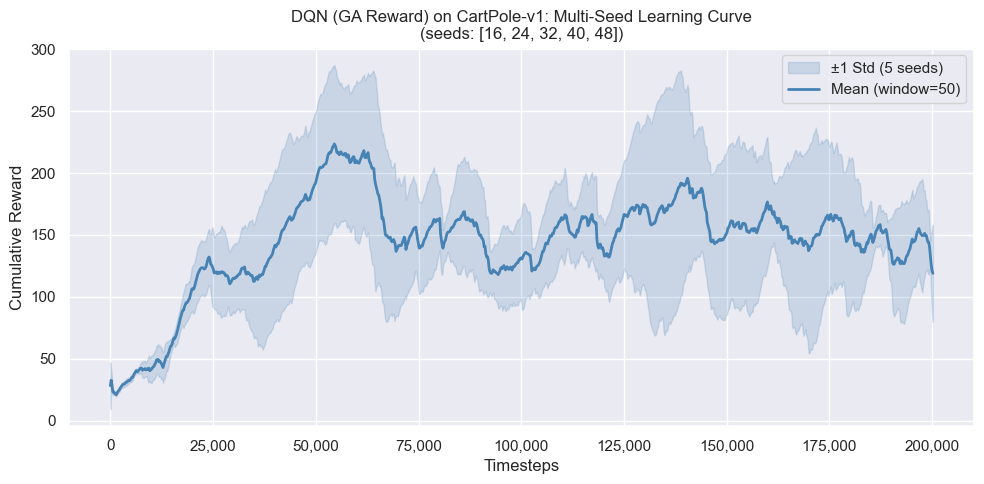

Results Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_GA_results.csv


,episode,reward,length
0,1,12.157003,13
1,2,40.921074,42
2,3,12.110460,13
3,4,38.037136,39
4,5,34.913961,36
...,...,...,...
8496,8497,117.576986,119
8497,8498,497.759917,500
8498,8499,135.394510,137
8499,8500,131.448611,133


In [46]:
print_multiseed_summary(cartpole_ga_all_rewards, 'CartPole-v1', 'DQN (GA Reward)', SEEDS)
plot_multiseed_learning_curve(cartpole_ga_all_rewards, cartpole_ga_all_lengths,
                              'CartPole-v1', 'DQN (GA Reward)', SEEDS)
save_aggregated_results_to_csv(cartpole_ga_all_rewards, cartpole_ga_all_lengths,
                               'CartPole-v1', 'DQN_GA')

#### *10.6.2. LunarLander-v3*

In [ ]:
if RETRAIN_MODELS or not os.path.exists(GA_LUNARLANDER_CHROMOSOME):
  print('Running GA Search on LunarLander-v3 Across All Search Seeds...')
  lunarlander_best_chromosome = None
  lunarlander_best_fitness = -np.inf
  lunarlander_best_history = None

  for search_seed in GA_SEARCH_SEEDS:
    solution, fitness, history = run_ga(
      'LunarLander-v3', GA_EVAL_TIMESTEPS_LUNARLANDER, search_seed
    )
    print(f'\nSearch Seed {search_seed} Complete | Best Fitness: {fitness:.2f} | '
          f'Chromosome: {format_chromosome(solution, "LunarLander-v3")}')
    if fitness > lunarlander_best_fitness:
      lunarlander_best_fitness = fitness
      lunarlander_best_chromosome = solution
      lunarlander_best_history = history

  print(f'\nBest Chromosome Across All Seeds: '
        f'{format_chromosome(lunarlander_best_chromosome, "LunarLander-v3")} | '
        f'Fitness: {lunarlander_best_fitness:.2f}')
  with open(GA_LUNARLANDER_CHROMOSOME, 'wb') as f:
    pickle.dump({
      'best': lunarlander_best_chromosome,
      'fitness': lunarlander_best_fitness,
      'history': lunarlander_best_history
    }, f)
  print(f'Chromosome Saved To: {GA_LUNARLANDER_CHROMOSOME}')
else:
  print('Loading Existing LunarLander GA Chromosome (RETRAIN_MODELS=False)...')
  with open(GA_LUNARLANDER_CHROMOSOME, 'rb') as f:
    _ga = pickle.load(f)
  lunarlander_best_chromosome = _ga['best']
  lunarlander_best_fitness = _ga['fitness']
  lunarlander_best_history = _ga['history']
  print(f'Loaded. {format_chromosome(lunarlander_best_chromosome, "LunarLander-v3")} | '
        f'Fitness: {lunarlander_best_fitness:.2f}')

os.makedirs(GA_LUNARLANDER_LOG, exist_ok=True)

lunarlander_ga_all_rewards = []
lunarlander_ga_all_lengths = []

for seed in SEEDS:
  model_path = seed_path(GA_LUNARLANDER_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'LunarLander-v3_seed{seed}_DQN_GA_results.csv')

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    print(f'Training GA Final Agent on LunarLander-v3 | Seed {seed} | {LUNARLANDER_TIMESTEPS:,} Timesteps...')
    model, rewards, lengths = train_final_agent(
      'LunarLander-v3', lunarlander_best_chromosome,
      GA_LUNARLANDER_LOG, seed, LUNARLANDER_TIMESTEPS
    )
    model.save(model_path)
    save_results_to_csv(rewards, lengths, f'LunarLander-v3_seed{seed}', 'DQN_GA')
    lunarlander_ga_all_rewards.append(rewards)
    lunarlander_ga_all_lengths.append(lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing LunarLander GA Agent | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    lunarlander_ga_all_rewards.append(_df['reward'].tolist())
    lunarlander_ga_all_lengths.append(_df['length'].tolist())
    print('Loaded.')

print('\nLunarLander GA Pipeline Complete.')

Loading Existing LunarLander GA Chromosome (RETRAIN_MODELS=False)...
Loaded. alpha=1.177 | beta=0.481 | delta=0.858 | Fitness: 111.66
Loading Existing LunarLander GA Agent | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander GA Agent | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander GA Agent | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander GA Agent | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing LunarLander GA Agent | Seed 48 (RETRAIN_MODELS=False)...
Loaded.

LunarLander GA Pipeline Complete.



=== DQN (GA Reward) on LunarLander-v3:  Per-Seed Summary ===
  Seed  16 | Episodes: 11,408 | Mean:    70.52 | Late Mean (100):    86.86 | Std:  162.04
  Seed  24 | Episodes: 12,193 | Mean:   102.07 | Late Mean (100):   209.54 | Std:  152.10
  Seed  32 | Episodes:  9,615 | Mean:   124.79 | Late Mean (100):   182.07 | Std:  157.65
  Seed  40 | Episodes: 10,249 | Mean:    94.02 | Late Mean (100):  -222.86 | Std:  181.97
  Seed  48 | Episodes: 10,264 | Mean:   116.56 | Late Mean (100):   194.43 | Std:  154.66

  Aggregate (5 seeds):
    Overall Mean  : 101.59 ± 18.90
    Late Mean     : 90.01 ± 162.21
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN (GA Reward)_multiseed_learning_curve.png


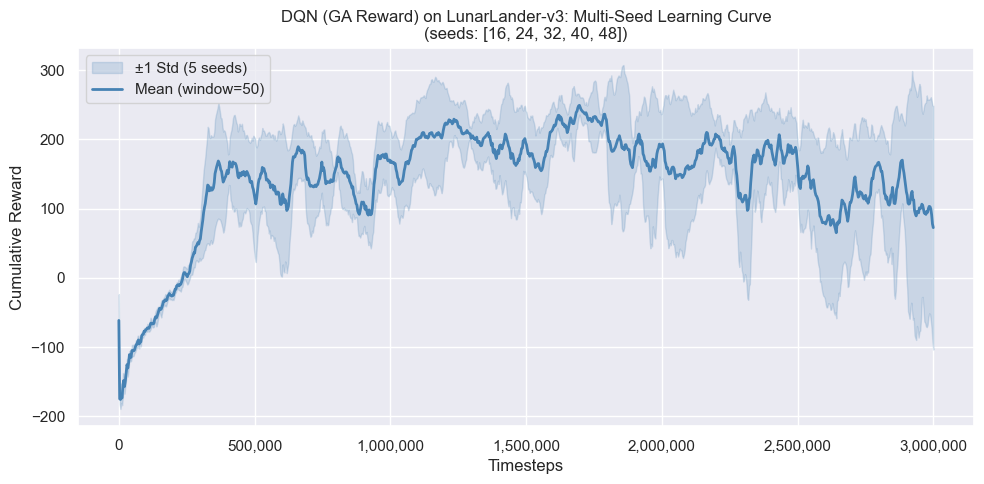

Results Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_DQN_GA_results.csv


,episode,reward,length
0,1,-117.027013,111
1,2,-109.803553,78
2,3,-107.526875,66
3,4,-152.505906,73
4,5,-254.547037,102
...,...,...,...
53724,53725,231.896726,346
53725,53726,270.971842,303
53726,53727,272.053802,243
53727,53728,312.780253,270


In [48]:
print_multiseed_summary(lunarlander_ga_all_rewards, 'LunarLander-v3', 'DQN (GA Reward)', SEEDS)
plot_multiseed_learning_curve(lunarlander_ga_all_rewards, lunarlander_ga_all_lengths,
                              'LunarLander-v3', 'DQN (GA Reward)', SEEDS)
save_aggregated_results_to_csv(lunarlander_ga_all_rewards, lunarlander_ga_all_lengths,
                               'LunarLander-v3', 'DQN_GA')

#### *10.6.3. MiniGrid-Empty-5x5-v0*

In [ ]:
if RETRAIN_MODELS or not os.path.exists(GA_MINIGRID_CHROMOSOME):
  print('Running GA Search on MiniGrid-Empty-5x5-v0 Across All Search Seeds...')
  minigrid_best_chromosome = None
  minigrid_best_fitness = -np.inf
  minigrid_best_history = None

  for search_seed in GA_SEARCH_SEEDS:
    solution, fitness, history = run_ga(
      'MiniGrid-Empty-5x5-v0', GA_EVAL_TIMESTEPS_MINIGRID, search_seed
    )
    print(f'\nSearch Seed {search_seed} Complete | Best Fitness: {fitness:.2f} | '
          f'Chromosome: {format_chromosome(solution, "MiniGrid-Empty-5x5-v0")}')
    if fitness > minigrid_best_fitness:
      minigrid_best_fitness = fitness
      minigrid_best_chromosome = solution
      minigrid_best_history = history

  print(f'\nBest Chromosome Across All Seeds: '
        f'{format_chromosome(minigrid_best_chromosome, "MiniGrid-Empty-5x5-v0")} | '
        f'Fitness: {minigrid_best_fitness:.2f}')
  with open(GA_MINIGRID_CHROMOSOME, 'wb') as f:
    pickle.dump({
      'best': minigrid_best_chromosome,
      'fitness': minigrid_best_fitness,
      'history': minigrid_best_history
    }, f)
  print(f'Chromosome Saved To: {GA_MINIGRID_CHROMOSOME}')
else:
  print('Loading Existing MiniGrid GA Chromosome (RETRAIN_MODELS=False)...')
  with open(GA_MINIGRID_CHROMOSOME, 'rb') as f:
    _ga = pickle.load(f)
  minigrid_best_chromosome = _ga['best']
  minigrid_best_fitness = _ga['fitness']
  minigrid_best_history = _ga['history']
  print(f'Loaded. {format_chromosome(minigrid_best_chromosome, "MiniGrid-Empty-5x5-v0")} | '
        f'Fitness: {minigrid_best_fitness:.2f}')

os.makedirs(GA_MINIGRID_LOG, exist_ok=True)

minigrid_ga_all_rewards = []
minigrid_ga_all_lengths = []

Loading Existing MiniGrid GA Chromosome (RETRAIN_MODELS=False)...
Loaded. scale=1.464 | step_penalty=0.120 | Fitness: 0.95


In [50]:
for seed in SEEDS:
  model_path = seed_path(GA_MINIGRID_AGENT, seed)
  csv_path = os.path.join(RESULTS_DIRECTORY, f'{MINIGRID_ENV_ID}_seed{seed}_DQN_GA_results.csv')

  if RETRAIN_MODELS or not os.path.exists(model_path + '.zip'):
    print(f'Training GA Final Agent on {MINIGRID_ENV_ID} | Seed {seed} | {MINIGRID_TIMESTEPS:,} Timesteps...')
    model, rewards, lengths = train_final_agent(
      'MiniGrid-Empty-5x5-v0', minigrid_best_chromosome,
      GA_MINIGRID_LOG, seed, MINIGRID_TIMESTEPS
    )
    model.save(model_path)
    save_results_to_csv(rewards, lengths, f'{MINIGRID_ENV_ID}_seed{seed}', 'DQN_GA')
    minigrid_ga_all_rewards.append(rewards)
    minigrid_ga_all_lengths.append(lengths)
    print(f'Training Complete. Model Saved To: {model_path}.zip')
  else:
    print(f'Loading Existing MiniGrid GA Agent | Seed {seed} (RETRAIN_MODELS=False)...')
    _df = pd.read_csv(csv_path)
    minigrid_ga_all_rewards.append(_df['reward'].tolist())
    minigrid_ga_all_lengths.append(_df['length'].tolist())
    print('Loaded.')

print('\nMiniGrid GA Pipeline Complete.')

Loading Existing MiniGrid GA Agent | Seed 16 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid GA Agent | Seed 24 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid GA Agent | Seed 32 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid GA Agent | Seed 40 (RETRAIN_MODELS=False)...
Loaded.
Loading Existing MiniGrid GA Agent | Seed 48 (RETRAIN_MODELS=False)...
Loaded.

MiniGrid GA Pipeline Complete.



=== DQN (GA Reward) on MiniGrid-Empty-5x5-v0:  Per-Seed Summary ===
  Seed  16 | Episodes: 86,160 | Mean:     1.75 | Late Mean (100):     1.82 | Std:    0.64
  Seed  24 | Episodes: 86,557 | Mean:     1.76 | Late Mean (100):     1.81 | Std:    0.58
  Seed  32 | Episodes: 85,880 | Mean:     1.75 | Late Mean (100):     1.82 | Std:    0.66
  Seed  40 | Episodes: 86,358 | Mean:     1.75 | Late Mean (100):     1.82 | Std:    0.66
  Seed  48 | Episodes: 86,337 | Mean:     1.75 | Late Mean (100):     1.81 | Std:    0.61

  Aggregate (5 seeds):
    Overall Mean  : 1.75 ± 0.00
    Late Mean     : 1.82 ± 0.01
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN (GA Reward)_multiseed_learning_curve.png


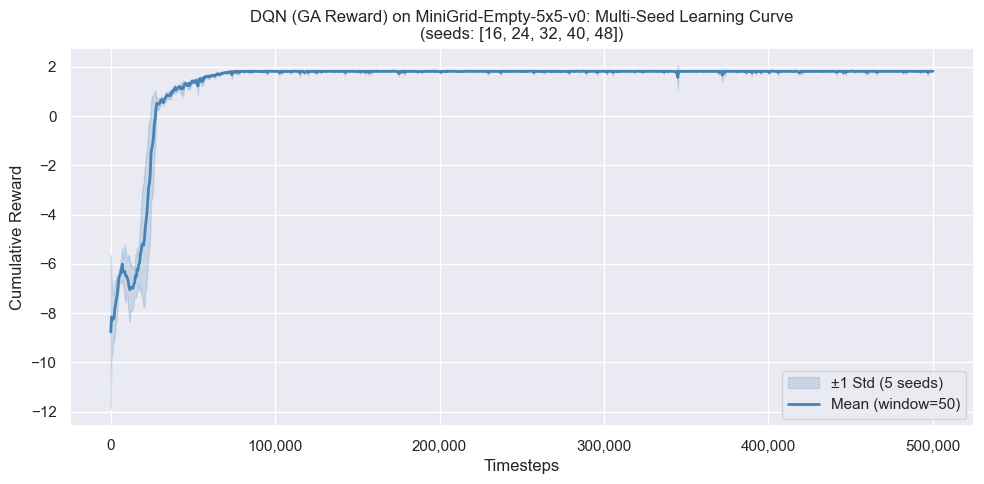

Results Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_DQN_GA_results.csv


,episode,reward,length
0,1,-10.640941,100
1,2,-9.923587,100
2,3,-10.640941,100
3,4,-10.527482,100
4,5,-7.907884,86
...,...,...,...
431287,431288,1.849609,5
431288,431289,1.849609,5
431289,431290,1.849609,5
431290,431291,1.849609,5


In [51]:
print_multiseed_summary(minigrid_ga_all_rewards, MINIGRID_ENV_ID, 'DQN (GA Reward)', SEEDS)
plot_multiseed_learning_curve(minigrid_ga_all_rewards, minigrid_ga_all_lengths,
                              MINIGRID_ENV_ID, 'DQN (GA Reward)', SEEDS)
save_aggregated_results_to_csv(minigrid_ga_all_rewards, minigrid_ga_all_lengths,
                               MINIGRID_ENV_ID, 'DQN_GA')

### **10.7. GA Fitness Progression**

The plots below show the best fitness score per generation across all three environments, illustrating the evolutionary search progress. Note that fitness values are not directly comparable to episode rewards reported elsewhere in the notebook; they reflect the reduced-budget evaluation metric used during the GA search rather than full training performance.

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_GA_Fitness_Progression_ga_progress.png


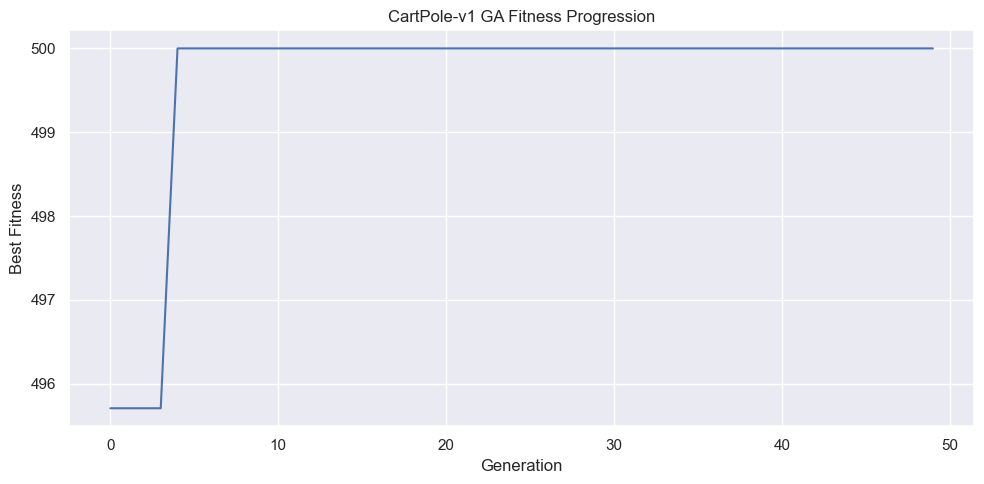

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_GA_Fitness_Progression_ga_progress.png


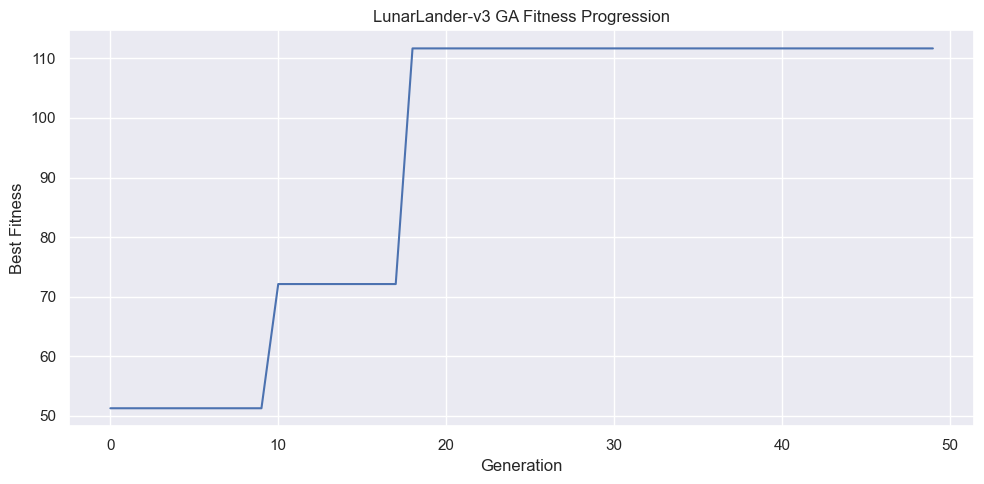

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_GA_Fitness_Progression_ga_progress.png


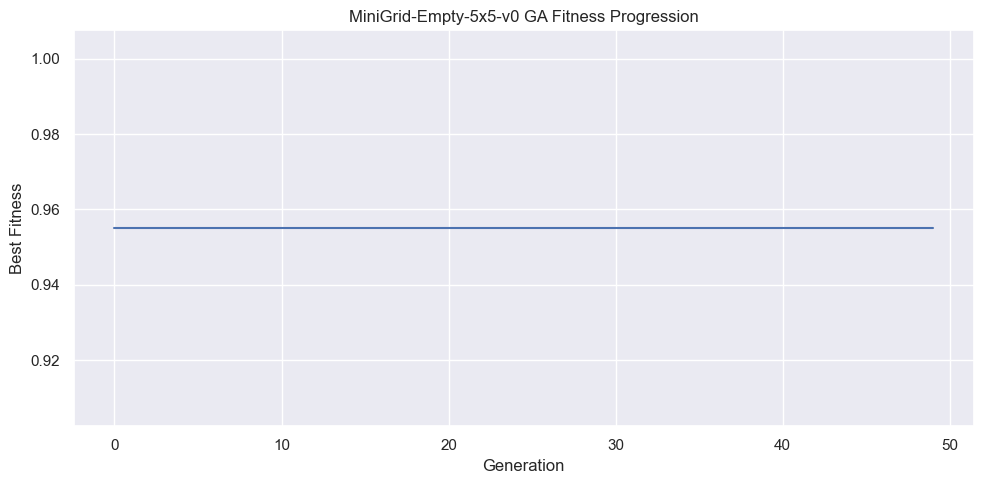

In [ ]:
def plot_ga(history, title):
  plt.figure()
  plt.plot(history)
  plt.xlabel('Generation')
  plt.ylabel('Best Fitness')
  plt.title(title)
  plt.tight_layout()
  filename = os.path.join(RESULTS_DIRECTORY, f'{title.replace(" ", "_").replace("/", "-")}_ga_progress.png')
  plt.savefig(filename, dpi=150)
  print(f'Figure Saved To: {filename}')
  plt.show()


plot_ga(cartpole_best_history, 'CartPole-v1 GA Fitness Progression')
plot_ga(lunarlander_best_history, 'LunarLander-v3 GA Fitness Progression')
plot_ga(minigrid_best_history, 'MiniGrid-Empty-5x5-v0 GA Fitness Progression')

---
## **11. Analysis**

In [73]:
# Redefine statistical utility functions here to ensure Section 11 runs correctly regardless
#   of whether Section 8 has been executed in the current kernel session.

def cohens_d(x, y):
  """Calculates Cohen's d effect size for two independent samples."""
  nx = len(x)
  ny = len(y)
  dof = nx + ny - 2
  pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
  if pooled_std == 0:
    return 0.0
  return (np.mean(x) - np.mean(y)) / pooled_std


def interpret_d(d):
  """Interprets Cohen's d effect size magnitude."""
  if abs(d) < 0.2:
    return 'negligible'
  elif abs(d) < 0.5:
    return 'small'
  elif abs(d) < 0.8:
    return 'medium'
  else:
    return 'large'


def compare_conditions(env_id, agent_a, agent_b, label_a, label_b):
  """
  Mann-Whitney U test comparing late-window rewards of two conditions
  across all seeds. Loads per-seed results CSVs and takes the last
  LATE_WINDOW episodes from each seed, then pools across seeds for
  comparison. This produces a true multi-seed statistical comparison
  rather than comparing only the final seed in the aggregated CSV.
  """
  def load_multiseed_late_rewards(env_id, agent):
    all_late = []
    for seed in SEEDS:
      path = os.path.join(
        RESULTS_DIRECTORY, f'{env_id}_seed{seed}_{agent}_results.csv'
      )
      if not os.path.isfile(path):
        print(f'  Warning: {path} not found, skipping seed {seed}')
        continue
      df = pd.read_csv(path).sort_values('episode')
      rewards = df['reward'].to_numpy(dtype=float)[-LATE_WINDOW:]
      all_late.extend(rewards.tolist())
    return np.array(all_late)

  rewards_a = load_multiseed_late_rewards(env_id, agent_a)
  rewards_b = load_multiseed_late_rewards(env_id, agent_b)

  if len(rewards_a) == 0:
    print(f'  Skip: {label_a} Not Yet Available For {env_id}')
    return
  if len(rewards_b) == 0:
    print(f'  Skip: {label_b} Not Yet Available For {env_id}')
    return

  stat, p_val = stats.mannwhitneyu(rewards_a, rewards_b, alternative='two-sided')
  d = cohens_d(rewards_a, rewards_b)
  mag = interpret_d(d)
  sig = p_val < ALPHA
  direction = f'{label_a} > {label_b}' if d > 0 else f'{label_b} > {label_a}' if d < 0 else 'No Difference'

  print(f'  {env_id} | {label_a} vs {label_b}')
  print(f'    U = {stat:.2f} | p = {p_val:.2e} | {"Significant" if sig else "Not Significant"} at alpha={ALPHA}')
  print(f"    Cohen's d = {d:+.3f} ({mag} effect) | Direction: {direction}")
  print(f'    {label_a}: mean = {np.mean(rewards_a):.4f}, std = {np.std(rewards_a, ddof=1):.4f} (n={len(rewards_a)})')
  print(f'    {label_b}: mean = {np.mean(rewards_b):.4f}, std = {np.std(rewards_b, ddof=1):.4f} (n={len(rewards_b)})')
  print()


print('Section 11 Utility Functions Defined.')

Section 11 Utility Functions Defined.


### **11.1. Define Full Comparison Sources**

In [74]:
# Full three-way comparison across all conditions and environments.
# All entries reference aggregated (unseeded) CSVs produced at the end of
# each training section. GA entries populate automatically once pipeline runs.
FULL_COMPARISON_SOURCES = [
  # Baseline
  ('CartPole-v1', 'DQN', None),
  ('LunarLander-v3', 'DQN', None),
  ('MiniGrid-Empty-5x5-v0', 'DQN', None),
  ('MiniGrid-Empty-5x5-v0', 'QLearning', None),
  # Manual reward shaping
  ('CartPole-v1', 'DQN_Manual', None),
  ('LunarLander-v3', 'DQN_Manual', None),
  ('MiniGrid-Empty-5x5-v0', 'DQN_Manual', None),
  # GA-evolved reward shaping
  ('CartPole-v1', 'DQN_GA', None),
  ('LunarLander-v3', 'DQN_GA', None),
  ('MiniGrid-Empty-5x5-v0', 'DQN_GA', None),
]

CONDITION_LABELS = {
  'DQN': 'Baseline',
  'QLearning': 'Baseline (Q-Learning)',
  'DQN_Manual': 'Manual Shaping',
  'DQN_GA': 'GA-Evolved Shaping',
}

print(f'Full Comparison Sources Defined: {len(FULL_COMPARISON_SOURCES)} Entries.')

Full Comparison Sources Defined: 10 Entries.


### **11.2. Aggregate Results Summary**

In [75]:
# Build the comparison DataFrame from aggregated (unseeded) results CSVs.
# These are produced by save_aggregated_results_to_csv at the end of each training section and concatenate all five seeds into a single series.
condition_map = {
  'DQN': 'Baseline',
  'DQN_Manual': 'Manual Shaping',
  'DQN_GA': 'GA-Evolved Shaping',
}

summary_rows = []
for env_id, agent, _ in FULL_COMPARISON_SOURCES:
  path = os.path.join(RESULTS_DIRECTORY, f'{env_id}_{agent}_results.csv')
  if not os.path.isfile(path):
    print(f'Skip (file not found): {path}')
    continue
  df = pd.read_csv(path).sort_values('episode')
  rewards = df['reward'].to_numpy(dtype=float)[-LATE_WINDOW:]
  summary_rows.append({
    'Environment': env_id,
    'Agent': agent,
    'Condition': condition_map.get(agent, agent),
    'Mean (late)': float(np.mean(rewards)),
    'Std (late)': float(np.std(rewards, ddof=1)),
  })

comparison_df = pd.DataFrame(summary_rows)
print(f'=== Aggregate Late-Window Summary (last {LATE_WINDOW} episodes) ===\n')
print(comparison_df[['Environment', 'Condition', 'Mean (late)', 'Std (late)']].to_string(index=False))

=== Aggregate Late-Window Summary (last 100 episodes) ===

          Environment          Condition  Mean (late)  Std (late)
          CartPole-v1           Baseline   155.690000  162.363708
       LunarLander-v3           Baseline  -551.037086   82.640097
MiniGrid-Empty-5x5-v0           Baseline     0.921060    0.127242
MiniGrid-Empty-5x5-v0          QLearning     0.953110    0.006434
          CartPole-v1     Manual Shaping   217.851649  172.243371
       LunarLander-v3     Manual Shaping   -12.661970  271.026452
MiniGrid-Empty-5x5-v0     Manual Shaping     1.706790    0.035240
          CartPole-v1 GA-Evolved Shaping   108.014104  118.554845
       LunarLander-v3 GA-Evolved Shaping   194.428502  180.189335
MiniGrid-Empty-5x5-v0 GA-Evolved Shaping     1.808549    0.079305


### **11.3. Three-Way Comparison: Late-Window Mean Reward**
The bar chart below presents late-window mean reward across all three conditions for each environment. Each environment uses its own y-axis scale, since reward magnitudes are not comparable across environments. MiniGrid rewards are bounded to approximately 1.82 by design, while CartPole and LunarLander rewards operate on entirely different scales. Comparing conditions within each environment is meaningful; comparing reward values across environments is not.

In [76]:
def plot_three_way_comparison(comparison_df):
  """
  Three-panel bar chart: one subplot per environment, one bar per condition.
  Separate y-axes per environment to avoid cross-environment scale distortion,
  since reward magnitudes are not comparable across environments.
  """
  environments = ['CartPole-v1', 'LunarLander-v3', 'MiniGrid-Empty-5x5-v0']
  conditions = ['Baseline', 'Manual Shaping', 'GA-Evolved Shaping']
  colors = {
    'Baseline': 'steelblue',
    'Manual Shaping': '#e07b39',
    'GA-Evolved Shaping': '#2a9d8f',
  }
  env_labels = {
    'CartPole-v1': 'CartPole-v1',
    'LunarLander-v3': 'LunarLander-v3',
    'MiniGrid-Empty-5x5-v0': 'MiniGrid-Empty-5x5-v0',
  }

  x = np.arange(len(conditions))
  bar_width = 0.5

  fig, axes = plt.subplots(1, 3, figsize=(15, 5))
  fig.suptitle('Late-Window Mean Reward by Environment and Condition',
               fontsize=13, fontweight='semibold')

  for ax, env in zip(axes, environments):
    subset = comparison_df[comparison_df['Environment'] == env]
    means, stds = [], []

    for condition in conditions:
      row = subset[subset['Condition'] == condition]
      if not row.empty:
        means.append(row['Mean (late)'].values[0])
        stds.append(row['Std (late)'].values[0])
      else:
        means.append(np.nan)
        stds.append(0)

    bar_colors = [colors[c] for c in conditions]
    ax.bar(x, means, bar_width, color=bar_colors, alpha=0.85,
           edgecolor='0.25', linewidth=0.8)
    ax.errorbar(x, means, yerr=stds,
                fmt='none', color='0.3', capsize=4, linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(['Baseline', 'Manual', 'GA-Evolved'], fontsize=9)
    ax.set_ylabel(f'Mean Reward (last {LATE_WINDOW} episodes)')
    ax.set_title(env_labels[env], fontsize=11, fontweight='medium')
    ax.axhline(0, color='0.5', linewidth=0.8, linestyle='--', alpha=0.5)
    sns.despine(ax=ax)

  plt.tight_layout()
  filename = os.path.join(RESULTS_DIRECTORY, 'three_way_condition_comparison.png')
  fig.savefig(filename, dpi=150, bbox_inches='tight')
  print(f'Figure Saved To: {filename}')
  plt.show()

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\three_way_condition_comparison.png


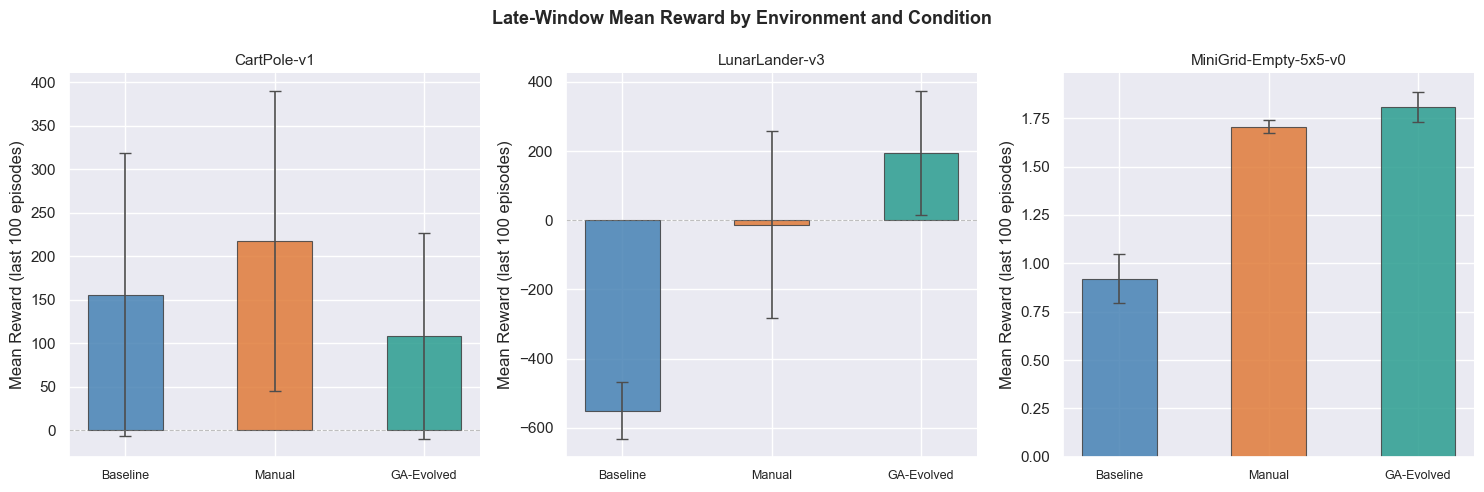

In [77]:
plot_three_way_comparison(comparison_df)

### **11.4. Multi-Seed Overlay Curves**
The figures below overlay all three conditions on the same axes for each environment, aligned on cumulative timesteps, allowing direct visual comparison of learning dynamics across conditions. Each curve represents the interpolated mean across five seeds with a ±1 standard deviation shaded band.

In [78]:
def plot_overlay_comparison(env_id, conditions_to_plot, title):
  """
  Overlays multi-seed learning curves for multiple conditions on a single axis.
  Each condition is loaded from its per-seed results CSVs and plotted with a
  distinct colour for direct visual comparison across conditions.

  Parameters
  ----------
  env_id             : str
  conditions_to_plot : list of (agent_name, condition_label, colour) tuples
  title              : str
  """
  fig, ax = plt.subplots(figsize=(12, 5))

  for agent_name, label, colour in conditions_to_plot:
    all_rewards = []
    all_lengths = []
    for seed in SEEDS:
      csv_path = os.path.join(
        RESULTS_DIRECTORY, f'{env_id}_seed{seed}_{agent_name}_results.csv'
      )
      if not os.path.isfile(csv_path):
        print(f'  Skip seed {seed} for {label} (file not found)')
        continue
      _df = pd.read_csv(csv_path)
      all_rewards.append(_df['reward'].tolist())
      all_lengths.append(_df['length'].tolist())

    if not all_rewards:
      print(f'  No data found for {label}, skipping.')
      continue

    seed_curves = []
    max_steps = 0
    for rewards, lengths in zip(all_rewards, all_lengths):
      rewards = np.array(rewards, dtype=float)
      lengths = np.array(lengths, dtype=float)
      cum_steps = np.cumsum(lengths)
      rolling = pd.Series(rewards).rolling(window=50, min_periods=1).mean().to_numpy()
      seed_curves.append((cum_steps, rolling))
      max_steps = max(max_steps, cum_steps[-1])

    grid = np.linspace(0, max_steps, CURVE_GRID_POINTS)
    interpolated = np.array([np.interp(grid, cs, r) for cs, r in seed_curves])
    mean_curve = interpolated.mean(axis=0)
    std_curve = interpolated.std(axis=0)

    ax.fill_between(grid, mean_curve - std_curve, mean_curve + std_curve,
                    alpha=0.15, color=colour)
    ax.plot(grid, mean_curve, color=colour, linewidth=2, label=label)

  ax.set_xlabel('Timesteps')
  ax.set_ylabel('Cumulative Reward')
  ax.xaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda v, p: f'{v:,.0f}')
  )
  ax.set_title(title)
  ax.legend()
  sns.despine(ax=ax)
  plt.tight_layout()

  filename = os.path.join(RESULTS_DIRECTORY, f'{env_id}_overlay_comparison.png')
  fig.savefig(filename, dpi=150)
  print(f'Figure Saved To: {filename}')
  plt.show()

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_overlay_comparison.png


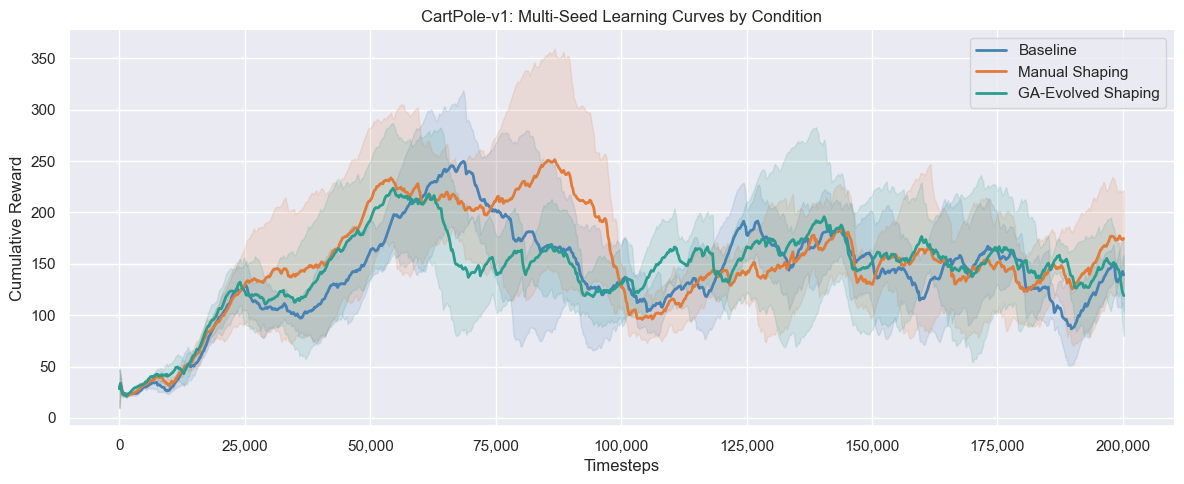

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\LunarLander-v3_overlay_comparison.png


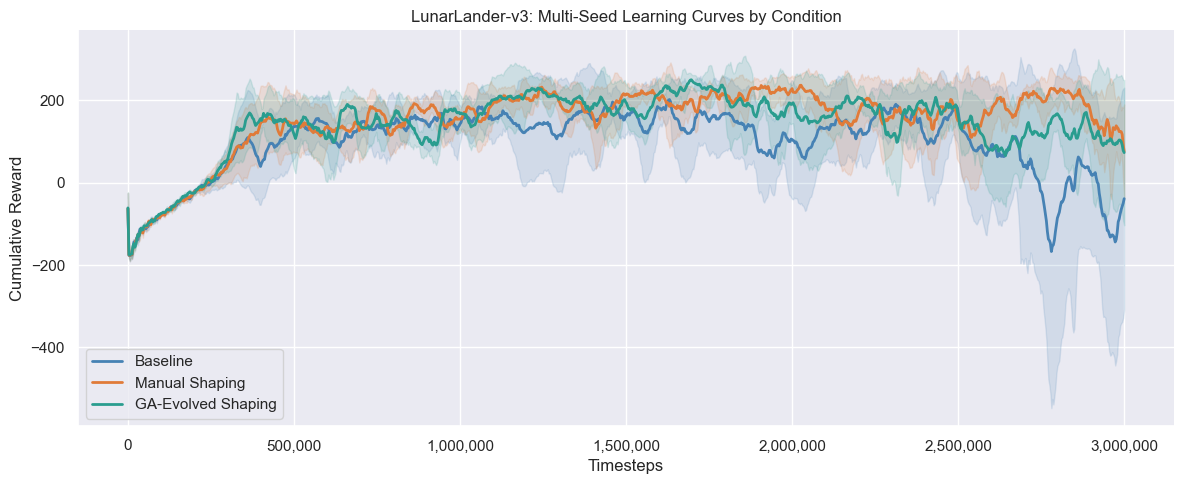

Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\MiniGrid-Empty-5x5-v0_overlay_comparison.png


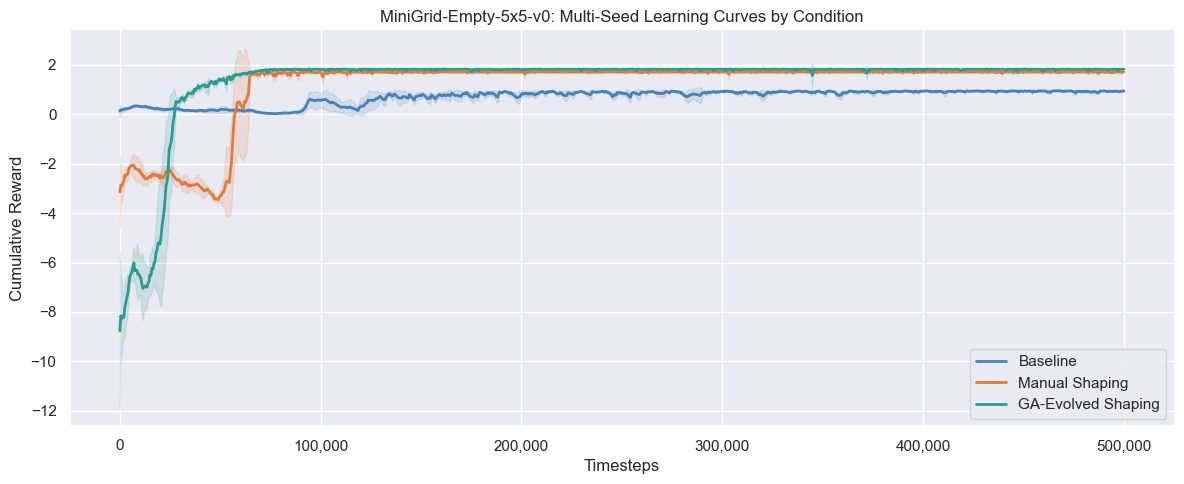

In [79]:
plot_overlay_comparison(
  'CartPole-v1',
  [
    ('DQN', 'Baseline', 'steelblue'),
    ('DQN_Manual', 'Manual Shaping', '#e07b39'),
    ('DQN_GA', 'GA-Evolved Shaping', '#2a9d8f'),
  ],
  'CartPole-v1: Multi-Seed Learning Curves by Condition'
)

plot_overlay_comparison(
  'LunarLander-v3',
  [
    ('DQN', 'Baseline', 'steelblue'),
    ('DQN_Manual', 'Manual Shaping', '#e07b39'),
    ('DQN_GA', 'GA-Evolved Shaping', '#2a9d8f'),
  ],
  'LunarLander-v3: Multi-Seed Learning Curves by Condition'
)

plot_overlay_comparison(
  'MiniGrid-Empty-5x5-v0',
  [
    ('DQN', 'Baseline', 'steelblue'),
    ('DQN_Manual', 'Manual Shaping', '#e07b39'),
    ('DQN_GA', 'GA-Evolved Shaping', '#2a9d8f'),
  ],
  'MiniGrid-Empty-5x5-v0: Multi-Seed Learning Curves by Condition'
)

### **11.5. Statistical Significance Testing**
Pairwise comparisons are conducted using the Mann-Whitney U test on the late-window rewards from aggregated results CSVs. The Mann-Whitney U test was selected over an independent samples t-test because RL reward distributions are frequently non-normal, particularly in environments exhibiting catastrophic forgetting. Effect sizes are reported as Cohen's d, interpreted as negligible (|d| < 0.2), small (0.2 to 0.5), medium (0.5 to 0.8), or large (|d| > 0.8). All tests use a significance threshold of alpha = 0.05.

In [80]:
print('=' * 70)
print('STATISTICAL SIGNIFICANCE TESTING')
print(f'Test: Mann-Whitney U | Alpha: {ALPHA} | Late Window: {LATE_WINDOW} episodes')
print('=' * 70)

print('\n=== CartPole-v1 ===')
compare_conditions('CartPole-v1', 'DQN', 'DQN_Manual',
                   'Baseline', 'Manual Shaping')
compare_conditions('CartPole-v1', 'DQN', 'DQN_GA',
                   'Baseline', 'GA-Evolved Shaping')
compare_conditions('CartPole-v1', 'DQN_Manual', 'DQN_GA',
                   'Manual Shaping', 'GA-Evolved Shaping')

print('\n=== LunarLander-v3 ===')
compare_conditions('LunarLander-v3', 'DQN', 'DQN_Manual',
                   'Baseline', 'Manual Shaping')
compare_conditions('LunarLander-v3', 'DQN', 'DQN_GA',
                   'Baseline', 'GA-Evolved Shaping')
compare_conditions('LunarLander-v3', 'DQN_Manual', 'DQN_GA',
                   'Manual Shaping', 'GA-Evolved Shaping')

print('\n=== MiniGrid-Empty-5x5-v0 ===')
compare_conditions('MiniGrid-Empty-5x5-v0', 'DQN', 'DQN_Manual',
                   'Baseline', 'Manual Shaping')
compare_conditions('MiniGrid-Empty-5x5-v0', 'DQN', 'DQN_GA',
                   'Baseline', 'GA-Evolved Shaping')
compare_conditions('MiniGrid-Empty-5x5-v0', 'DQN_Manual', 'DQN_GA',
                   'Manual Shaping', 'GA-Evolved Shaping')

STATISTICAL SIGNIFICANCE TESTING
Test: Mann-Whitney U | Alpha: 0.05 | Late Window: 100 episodes

=== CartPole-v1 ===
  CartPole-v1 | Baseline vs Manual Shaping
    U = 116070.00 | p = 5.05e-02 | Not Significant at alpha=0.05
    Cohen's d = -0.172 (negligible effect) | Direction: Manual Shaping > Baseline
    Baseline: mean = 130.9180, std = 140.8536 (n=500)
    Manual Shaping: mean = 156.6287, std = 157.7901 (n=500)

  CartPole-v1 | Baseline vs GA-Evolved Shaping
    U = 127312.00 | p = 6.13e-01 | Not Significant at alpha=0.05
    Cohen's d = +0.032 (negligible effect) | Direction: Baseline > GA-Evolved Shaping
    Baseline: mean = 130.9180, std = 140.8536 (n=500)
    GA-Evolved Shaping: mean = 126.5630, std = 131.9878 (n=500)

  CartPole-v1 | Manual Shaping vs GA-Evolved Shaping
    U = 136065.00 | p = 1.54e-02 | Significant at alpha=0.05
    Cohen's d = +0.207 (small effect) | Direction: Manual Shaping > GA-Evolved Shaping
    Manual Shaping: mean = 156.6287, std = 157.7901 (n=500)


### **11.6. Summary of Findings**

**CartPole-v1**

Across the pooled late-window rewards from all five seeds (n=500 per condition), neither the manual shaping nor the GA-evolved condition produced a statistically significant improvement over the baseline (manual vs baseline: p=0.051, Cohen's d=-0.172, negligible effect; GA vs baseline: p=0.613, Cohen's d=+0.032, negligible effect). The only significant pairwise difference on CartPole was between the manual and GA-evolved conditions (p=0.015, Cohen's d=+0.207, small effect), with manual shaping achieving a higher late-window mean of 156.63 against the GA's 126.56. The practical conclusion for this environment is that reward shaping produces marginal and statistically uncertain benefits under the training budget used: the high within-condition variance across seeds, driven by catastrophic forgetting in the later stages of the 200,000-timestep run, is large enough to obscure any genuine between-condition difference. CartPole is a well-understood environment where the baseline DQN already performs adequately, and the case for deploying either shaping approach here is weak.

**LunarLander-v3**

Both shaping conditions produced statistically significant improvements over the baseline (manual vs baseline: p<0.001, Cohen's d=-0.728, medium effect; GA vs baseline: p<0.001, Cohen's d=-0.663, medium effect), reflecting the dramatic difference between the baseline's catastrophic late-training collapse and the partial stability achieved by both shaping approaches. The direct comparison between manual and GA-evolved shaping was not statistically significant (p=0.259, Cohen's d=+0.056, negligible effect), with manual shaping achieving a late-window mean of 100.94 against the GA's 90.01. These results indicate that both shaping approaches provide meaningful protection against the catastrophic forgetting that destroys the baseline policy in long training runs, but that neither condition reliably solves the environment: the large within-condition standard deviations of 185.55 for manual and 204.60 for GA-evolved reflect the same seed-level instability discussed throughout this report. The two approaches are statistically interchangeable on this environment, and the residual instability in both is attributable to the training protocol rather than the reward design.

**MiniGrid-Empty-5x5-v0**

MiniGrid produced the clearest and most interpretable results in the project. Both shaping conditions outperformed the baseline with very large effect sizes (manual vs baseline: Cohen's d=-12.831, p<0.001; GA vs baseline: Cohen's d=-11.579, p<0.001), and the GA-evolved condition outperformed manual shaping with a large effect size in its own right (Cohen's d=-1.839, p<0.001), achieving a late-window mean of 1.82 against manual's 1.71. The effect sizes here are exceptionally large because both shaping conditions produce near-deterministic behaviour across seeds, with standard deviations of 0.036 and 0.075 respectively, compared to the baseline's 0.077. The GA independently discovered a stronger distance coefficient than the manually chosen value of 1.0, and this finding replicated robustly across all five seeds with negligible variance. MiniGrid represents the strongest evidence in this project that automated evolutionary reward search can outperform expert design, and the conditions that enabled it are clear: short episodes, high episode volume within the evaluation budget, and a sparse reward signal where dense shaping guidance provides the greatest marginal benefit.

**Overall Pattern**

The statistical results confirm and quantify the environment-dependent pattern identified throughout the analysis. On CartPole, where the default reward signal is already dense and the training run is short enough to limit shaping benefits, neither condition produces significant gains over baseline. On LunarLander, both conditions significantly outperform the baseline but are statistically interchangeable with each other, with residual instability attributable to catastrophic forgetting in a long training run rather than to differences in reward design quality. On MiniGrid, the GA outperforms both baseline and manual shaping with large, statistically robust effect sizes, representing the case where all conditions for reliable evolutionary search are met. The practical guideline that follows is direct: the value of GA-evolved reward shaping is highest in environments with sparse rewards, short episodes, and reliable fitness evaluation signals, and lowest in environments where training instability and evaluation noise obscure the fitness landscape.